## Model Selection

First we are going to compute SHAP values for the models we found in the 4_modelling notebook. We are actually going to use the order 2 models for both the linear and hybrid case, even though in the hourly case technically the order 0 models performed slightly better than the order 2 ones, it would be interesting to see whether or not the models are using trend and trend_squared as important features. We are going to rank features by their mean absolute SHAP value and take the top 30 to form a reduced feature set. We then repeat the forecasting of 4_modelling to compare how these reduced feature set models perform compared to their full feature set counterparts.

Then we are going to perform hyperparameter tuning with Optuna for the xgboost models in both the standalone form (base_non_linear) as well as the xgboost model that forms part of the hybrid model.


In [1]:
import optuna
from jfk_taxis import load_design, load_config, load_models, load_lags, create_val_data, objective_optuna, save_hyperparams, load_hyperparams, save_obj, load_obj, split_params, test_hyperparams, load_ts_data, split_test_train_sets, load_process_lags, compute_shap_values, shap_plots, extract_top_x_features_dict, create_train_save_models, run_forecasts, save_extracted_features_to_config, make_offsets, save_config
from sklearn.linear_model import LinearRegression
import numpy as np
from xgboost import XGBRegressor
from functools import partial

In [2]:
# Load config and project root
config, PROJECT_ROOT = load_config()


In [3]:
# First load the significant lags
daily_lags, used_hourly_lags = load_process_lags()

In [4]:
# Load ts data
ts_daily, ts_hourly = load_ts_data()

In [5]:
# Create test train sets as defined in config.yml
ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test = split_test_train_sets(ts_daily, ts_hourly)

## SHAP values

We now seek to explore the shap values of the models. We are going to use order 2 for the model order in both the linear and hybrid case for the same reasons as stated above. It will turn out that actually trend and trend_squared are not important features by mean absoulute SHAP value so we can simply refit all the models onto this reduced feature set. We compute the SHAP values and rank the features by mean absolute SHAP value taking the top 30. These are then going to form our reduced feature set. 

Note due to the size of the design matricies we take a random sample of the rows when computing the SHAP values. For both the daily and hourly models we have set this random sample to be at most 10,000. For the daily models that will be the entire design matrix. The full hourly series is approx 127,000 rows so we are saving roughly 10x on memory usage, this allows us to run the computations in containers with less than 8GB of RAM whilst getting similar results in terms of identifiying feature importance when compared to computing on the entire design matrix.

In [6]:
# First we assemble the design and model signatures from config.yml
DAILY_LINEAR_SIG = config["model_sigs"]["daily_linear"]
DAILY_HYBRID_SIG = config["model_sigs"]["daily_hybrid"]
HOURLY_LINEAR_SIG = config["model_sigs"]["hourly_linear"]
HOURLY_HYBRID_SIG = config["model_sigs"]["hourly_hybrid"]

# Now we get the model prefixes from config.yml
DAILY_LINEAR_PREFIX = config["model_naming"]["linear_model_prefix"] + "2"
DAILY_HYBRID_PREFIX = config["model_naming"]["hybrid_model_prefix"] + "2"
HOURLY_LINEAR_PREFIX = config["model_naming"]["linear_model_prefix"] + "2"
HOURLY_HYBRID_PREFIX = config["model_naming"]["hybrid_model_prefix"] + "2"
DEFAULT_NON_LINEAR_PREFIX = config["model_naming"]["default_non_linear"]

# Daily prefix
DAILY_PREFIX = config["shap"]["daily_prefix"]

# Hourly prefix 
HOURLY_PREFIX = config["shap"]["hourly_prefix"]

# Titles for plots and to key values for dicts
DAILY_LINEAR_NAME = f"{DAILY_PREFIX}_{DAILY_LINEAR_PREFIX}"
DAILY_HYBRID_NAME = f"{DAILY_PREFIX}_{DAILY_HYBRID_PREFIX}"
DAILY_NON_LINEAR_NAME = f"{DAILY_PREFIX}_{DEFAULT_NON_LINEAR_PREFIX}"
HOURLY_LINEAR_NAME = f"{HOURLY_PREFIX}_{HOURLY_LINEAR_PREFIX}"
HOURLY_HYBRID_NAME = f"{HOURLY_PREFIX}_{HOURLY_HYBRID_PREFIX}"
HOURLY_NON_LINEAR_NAME = f"{HOURLY_PREFIX}_{DEFAULT_NON_LINEAR_PREFIX}"

# Sampel size, due to the large size of the data sets, particularly the hourly time series, we take a sample of the design matrix to compute the SHAP values on
daily_sample_size = config["shap"]["daily_sample_size"] # 10,000 this is actually more rows than in the full daily time series so we essentially do all of it
hourly_sample_size = config["shap"]["hourly_sample_size"] # 10,000

# Dictionary to store the shap values (it will contain tuples of shap values and design matricies)
shap_values_dict = {}


In [7]:
# Compute the SHAP values for daily non linear
shap_values, X = compute_shap_values(DAILY_LINEAR_SIG, DAILY_LINEAR_SIG, DEFAULT_NON_LINEAR_PREFIX, linear= False, hybrid= False, sample_size = daily_sample_size)

 95%|=================== | 4176/4377 [00:26<00:01]       

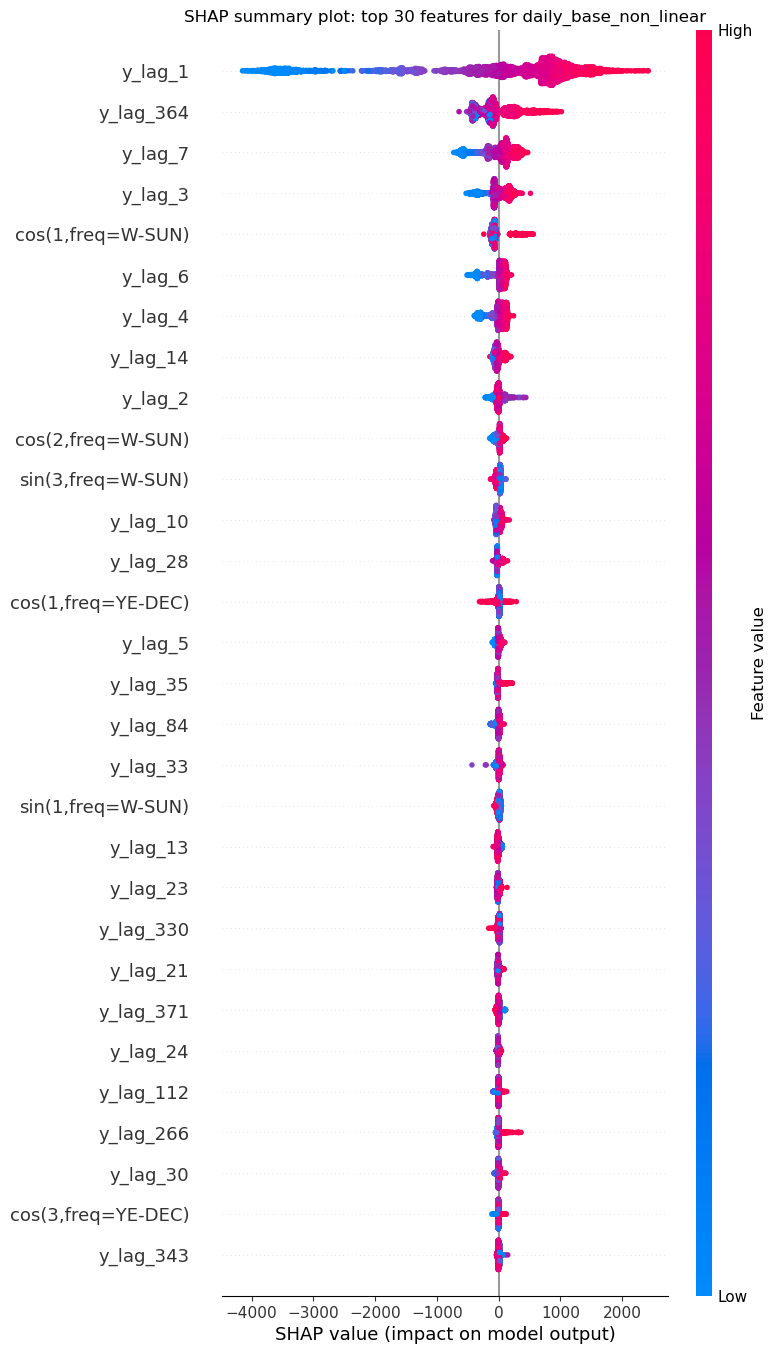

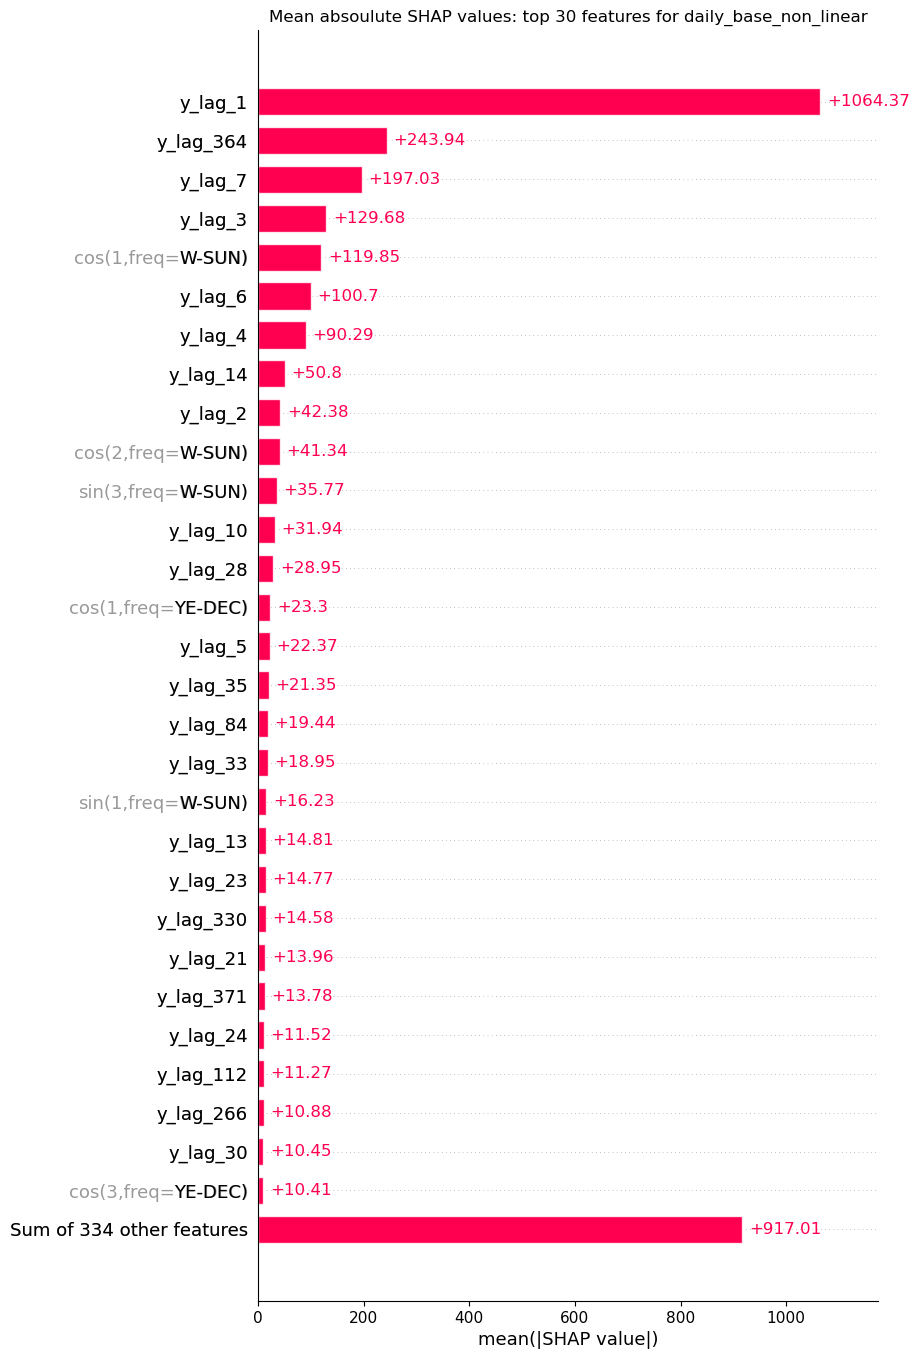

In [8]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, DAILY_NON_LINEAR_NAME)

In [9]:
# Store shap values and design matrix in dict
shap_values_dict[DAILY_NON_LINEAR_NAME] = (shap_values, X)

As you can see in the above SHAP summary plot, lag_1 has the widest spread with low feature values causing low impact on model output and vice versa. It is interesting that lag_1 is the most significant feature by SHAP value as during testing I tried several different naive baselines, like lag of 1, lag of 7 etc etc and lag of 1 was consitently the best which is supported here by our SHAP values. 

Interestingly you also see that lag_7 and lag_364 have reasonably wide spreads again lining up with our EDA that there was both weekly and yearly seasonality in the taxi data. Now this is an XGBoost model so it is interesting that it has picked up on the lags more rather than the fourier features when looking at seasonality. Although the model does still make use of the fourier features. 

It's worth looking at a daily linear model to see if it favours the fourier features over the lags.

In [10]:
# Compute SHAP values for daily linear_order2
shap_values, X = compute_shap_values(DAILY_LINEAR_SIG, DAILY_LINEAR_SIG, DAILY_LINEAR_PREFIX, linear= True, hybrid= False, sample_size = daily_sample_size)

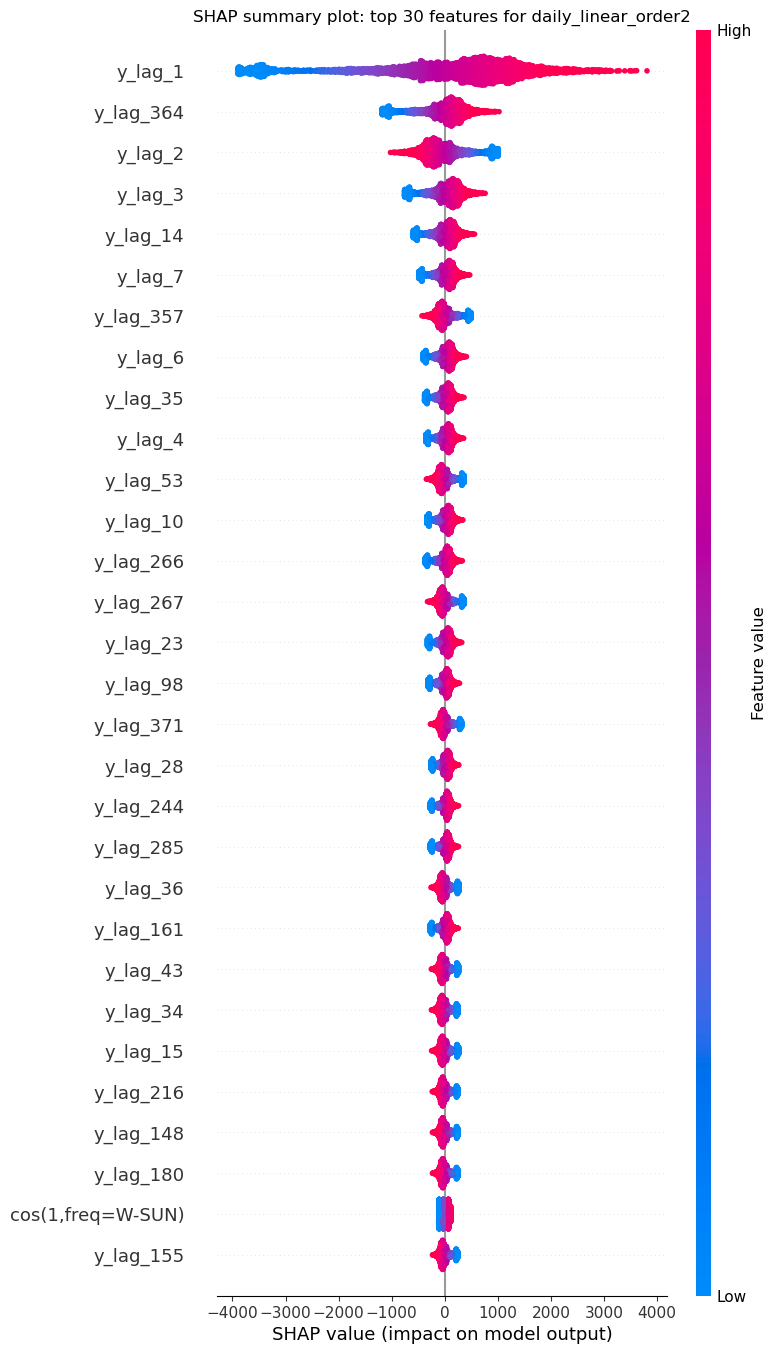

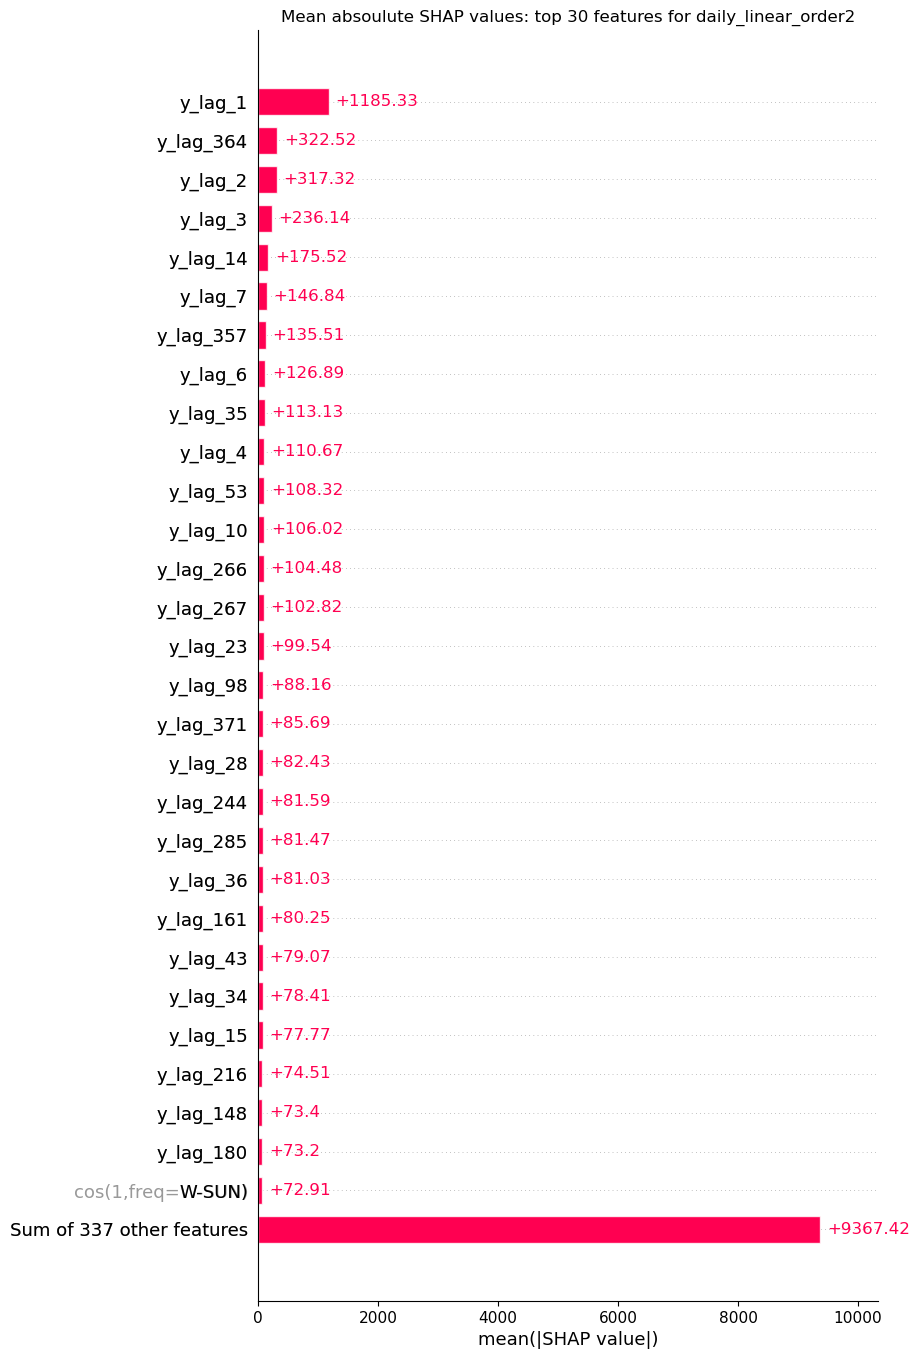

In [11]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, DAILY_LINEAR_NAME)

In [12]:
# Store shap values and design matrix in dict
shap_values_dict[DAILY_LINEAR_NAME] = (shap_values, X)

The above is super interesting because it shows that our fourier features aren't at the top at all here. This goes against what I expected as I orignally thought that the linear regression would like the smooth fourier features that could allow it to capture things like annual seasonality. But it seems it has used the lags like lag_364 and lag_7 to capture the seasonality instead. 

This seems to be more of a memory property of the data, as in the value last year affects the value this year more than the yearly up and down of say slightly more taxis around the holidays (due to more flights). So lag features like lag 364 can better capture both the seasanolity of 1 year but also the year on year effects, like high values last year means high values this year is likely. 

There are a couple interesting things to note in terms of the shape on the summary plots. For example for lag 2 it seems high values 2 days ago cause a decrease in the model prediction and vice versa. But high values one day ago strongly suggest high values the next day. Lag 7 and lag 14 have high mean absolute shap values which is again our weekly seasonality in lag form. 

The other thing that is super intersting is the trend doesn't seem to appear in the top 30. This suggests it's not significant for the model. However this is slightly suspicious as from our inital modelling it seems that linear_order2 outperformed the other linear_order models in the daily case, which would suggest that the trend had some effect on the outcome particualarly long term. So it may be worth adding the trend back in particularly for long term forecasts.

Finally it would be interesting to have an inital look at the SHAP values for the XGBoost component of the hybrid models, just to see what they are picking up. We will do this for hybrid_order2.

In [13]:
# Compute SHAP values for daily hybrid_order2
shap_values, X = compute_shap_values(DAILY_HYBRID_SIG, DAILY_HYBRID_SIG, DAILY_HYBRID_PREFIX, linear= True, hybrid= True, sample_size = daily_sample_size)

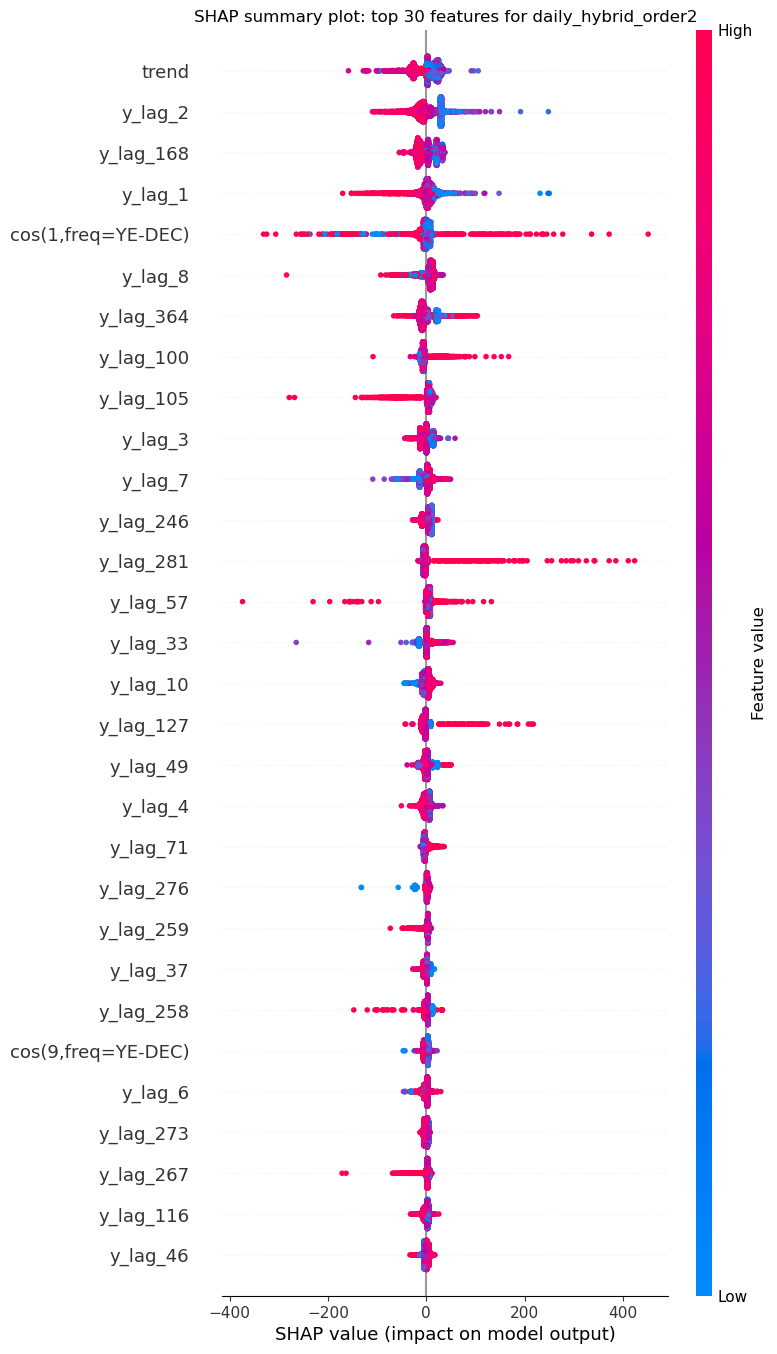

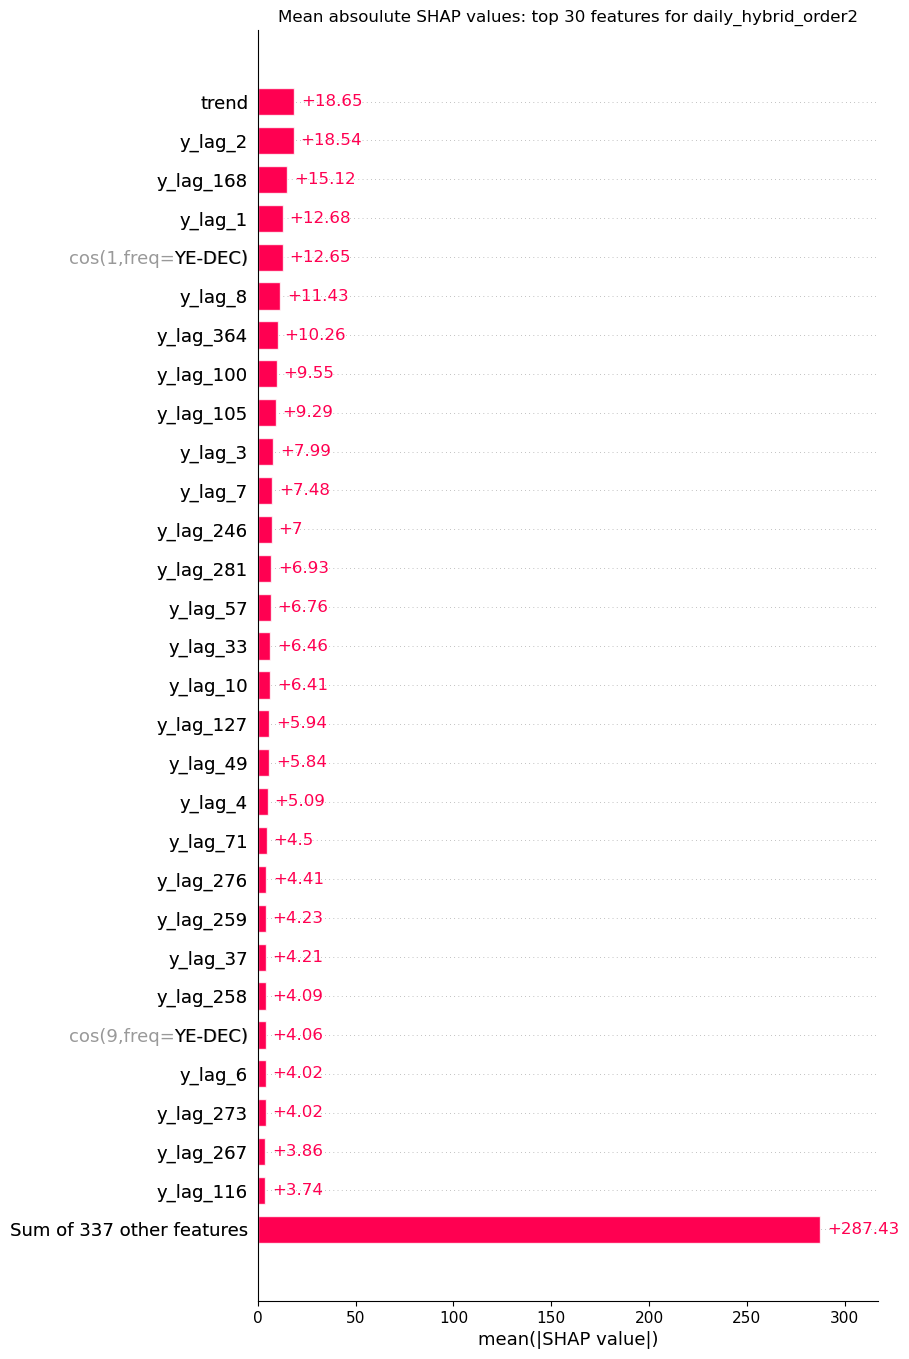

In [14]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, DAILY_HYBRID_NAME)

In [15]:
# Store shap values and design matrix in dict
shap_values_dict[DAILY_HYBRID_NAME] = (shap_values, X)

The above is intersting. It would seem trend is one of the most important feature according to mean absolute SHAP value. There is actually a good plausible explanation for this. Notice that high values of trend cause a decrease in model predictions. We know from 1_EDA that over the years taxi pick ups at JFK have overal declined. Possibly the xgboost model is using trend to somehow capture this slow decline over time. y_lag_2 is interestingly the most important feature, and is also negatively coded so large values of y_lag_2 cause a decrease in model prediction. Again this is perhaps trying to caputre instances where large values of taxi pick ups are then followed by a decrease rather than increase.

It's also very clear that these effects are much smaller than that of the underlying model (hybrid_order2s linear component is the same as for linear_order2) with y_lag_2 only having mean absoulute SHAP value of 54.18 compared to the linear components 1185.33 for y_lag_1.

We now do the same for the hourly models.



In [16]:
# Compute the SHAP values for hourly non linear
shap_values, X = compute_shap_values(HOURLY_LINEAR_SIG, HOURLY_LINEAR_SIG, DEFAULT_NON_LINEAR_PREFIX, linear= False, hybrid= False, sample_size = hourly_sample_size)

Sampling 10000 rows from 105168 for SHAP computation


100%|===================| 9974/10000 [05:32<00:00]        

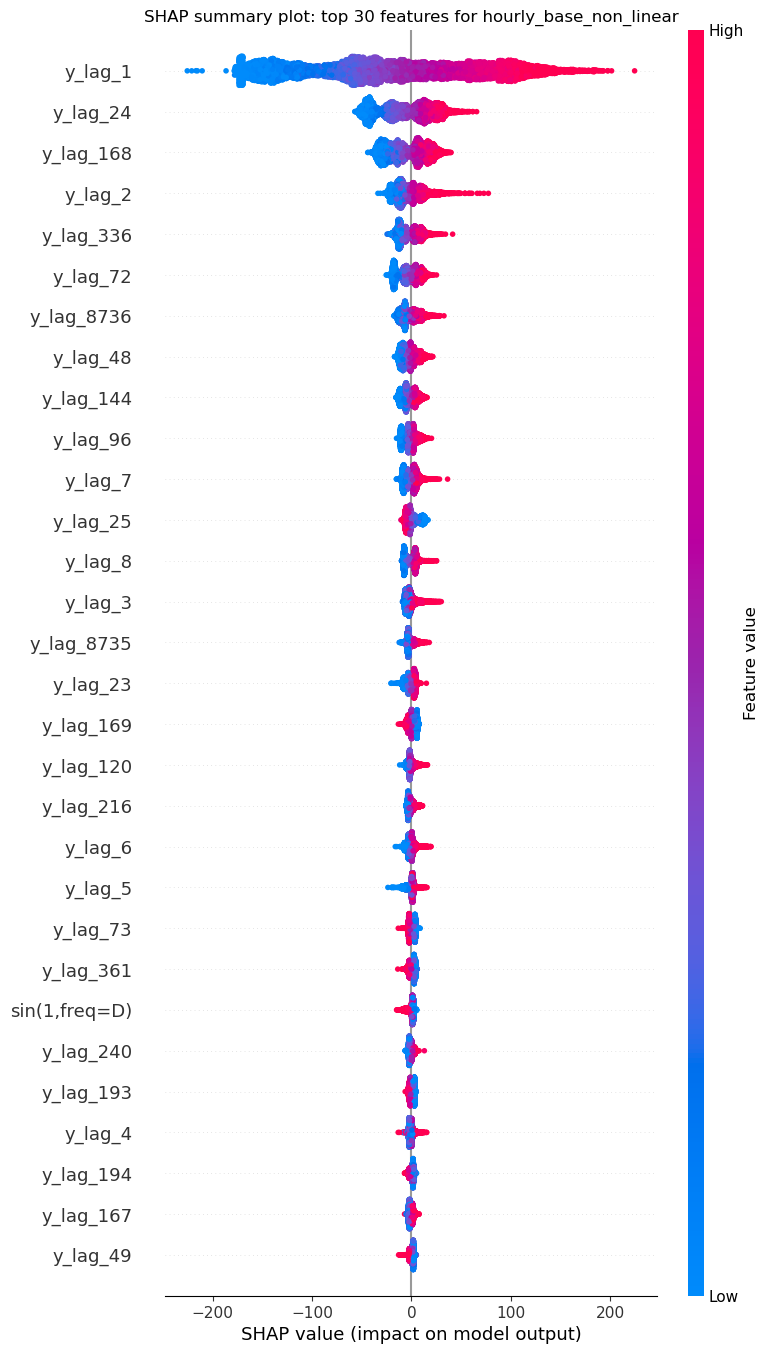

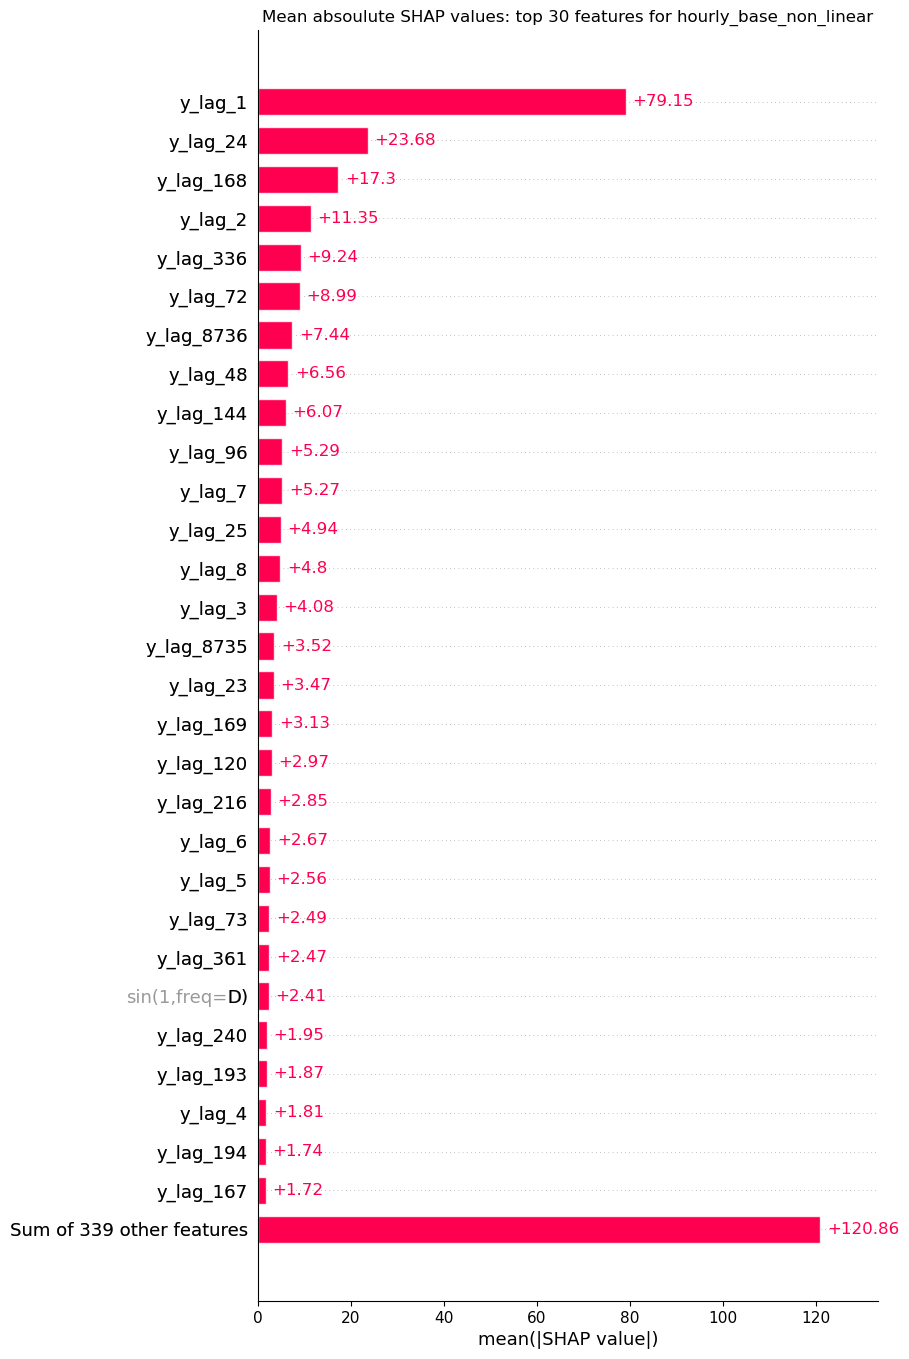

In [17]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, HOURLY_NON_LINEAR_NAME)

In [18]:
# Store shap values and design matrix in dict
shap_values_dict[HOURLY_NON_LINEAR_NAME] = (shap_values, X)

In [19]:
# Compute the SHAP values for hourly linear_order2
shap_values, X = compute_shap_values(HOURLY_LINEAR_SIG, HOURLY_LINEAR_SIG, HOURLY_LINEAR_PREFIX, linear= True, hybrid= False, sample_size = hourly_sample_size)

Sampling 10000 rows from 105168 for SHAP computation


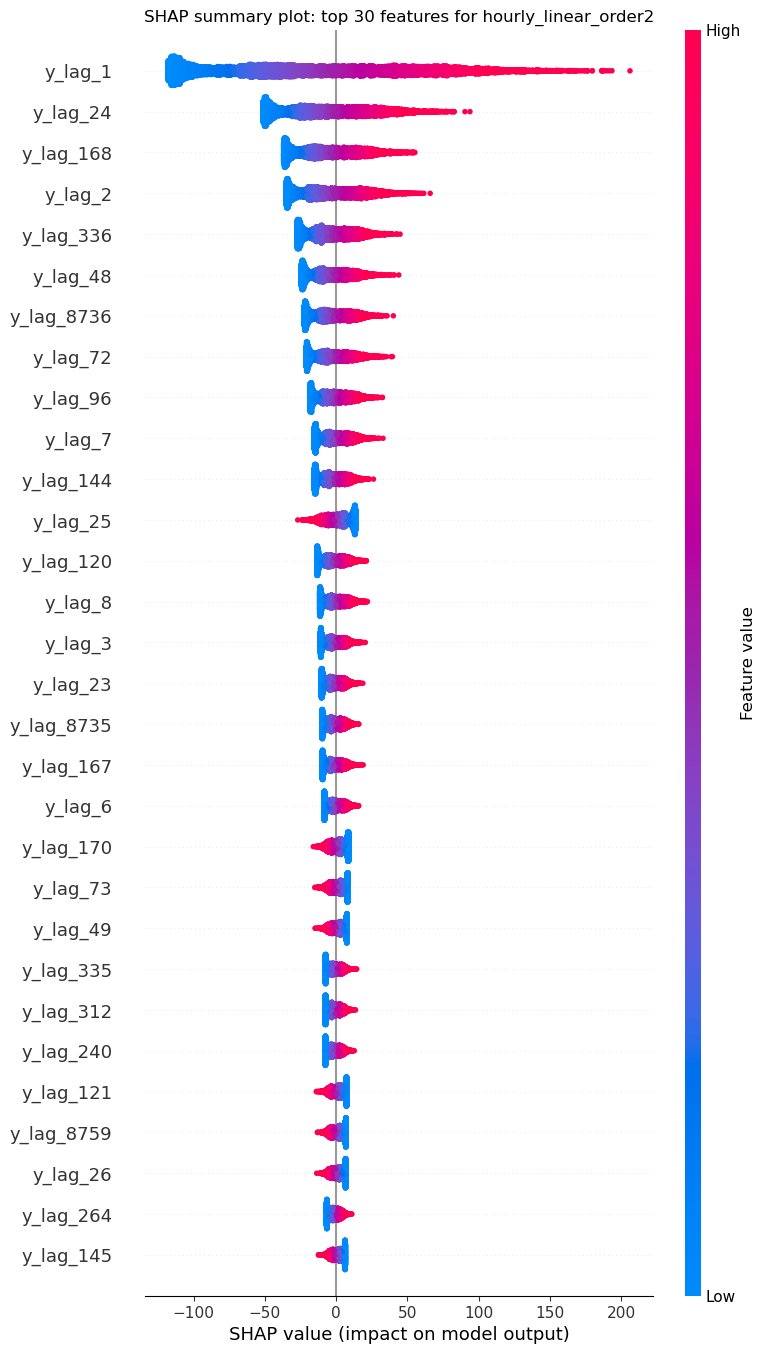

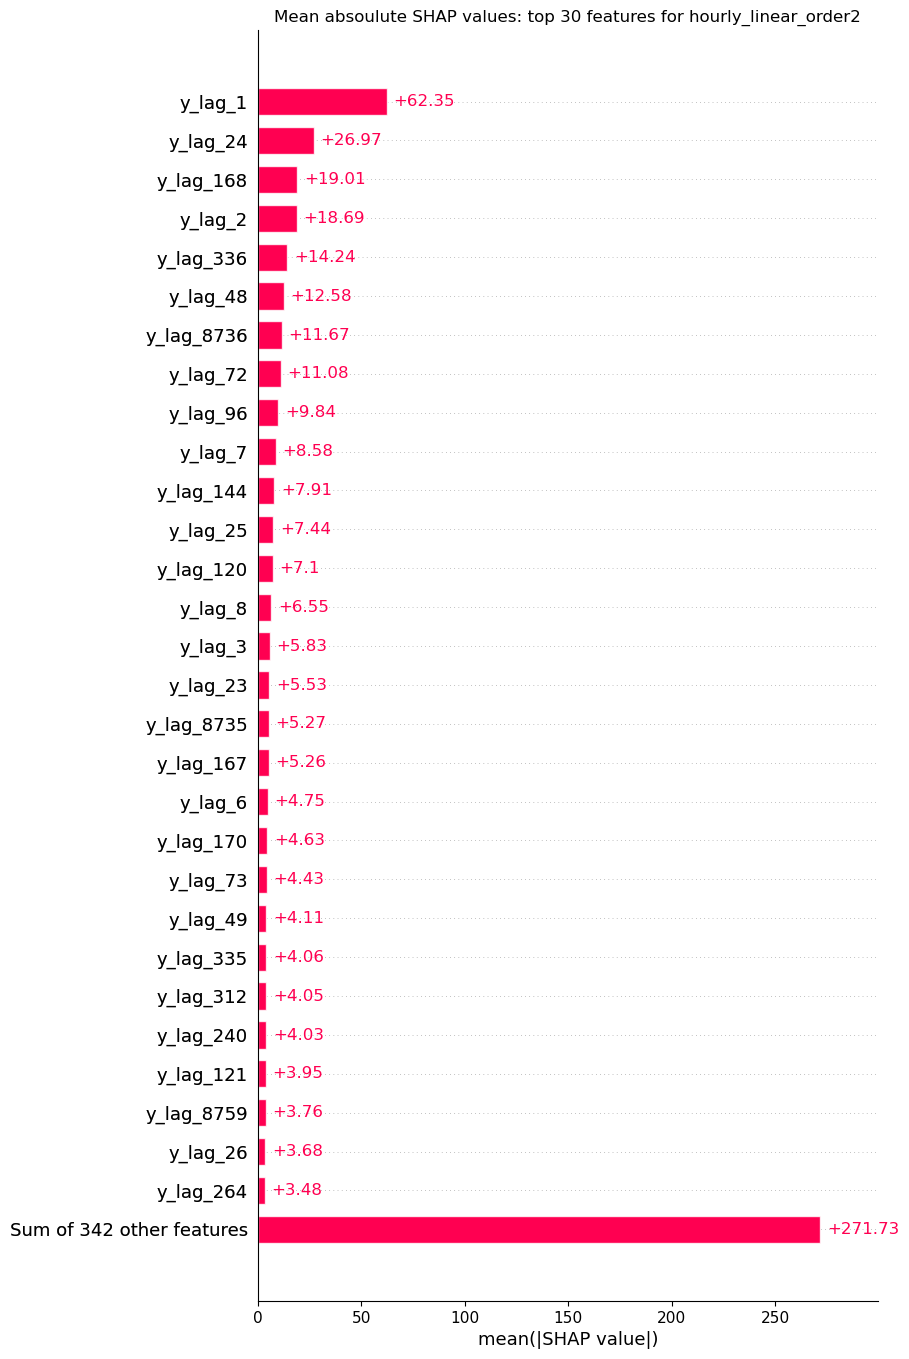

In [20]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, HOURLY_LINEAR_NAME)

In [21]:
# Store shap values and design matrix in dict
shap_values_dict[HOURLY_LINEAR_NAME] = (shap_values, X)

In [22]:
# Compute the SHAP values for hourly hybrid_order2
shap_values, X = compute_shap_values(HOURLY_HYBRID_SIG, HOURLY_HYBRID_SIG, HOURLY_HYBRID_PREFIX, linear= True, hybrid= True, sample_size = hourly_sample_size)

Sampling 10000 rows from 105168 for SHAP computation


100%|===================| 9976/10000 [07:03<00:01]        

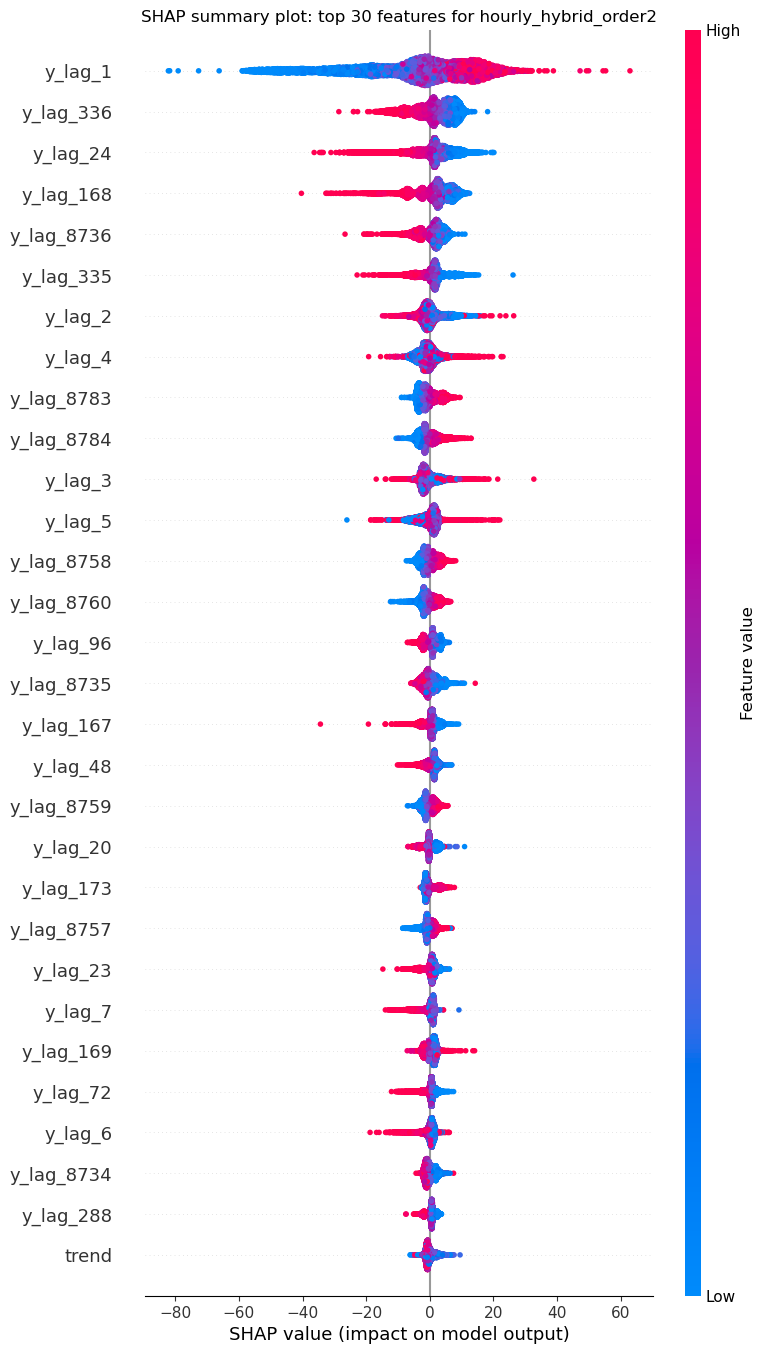

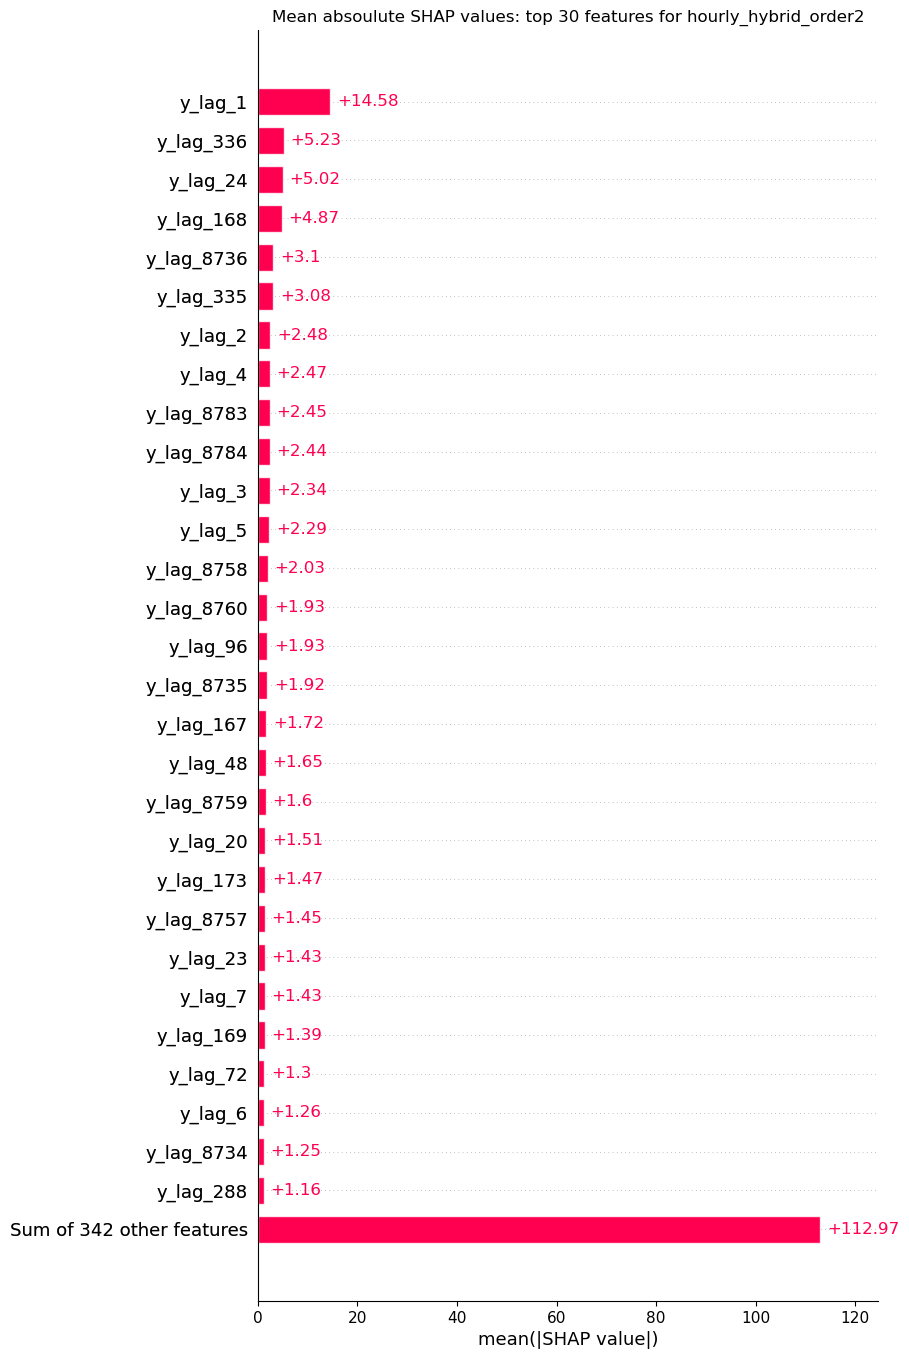

In [23]:
# Create summary plot and bar plot by mean absolute value
shap_plots(shap_values, X, HOURLY_HYBRID_NAME)

In [24]:
# Store shap values and design matrix in dict
shap_values_dict[HOURLY_HYBRID_NAME] = (shap_values, X)

In [25]:
# Save shap values dict
save_obj(shap_values_dict, config["saving"]["shap_values_file"])

What we immediately observe is we have the same pattern from the daily models. The daily and weekly seasonality (24 and 168 hours) both appear as lags rather than as their respective fourier features. In fact only the non_linear_model has any fourier features at all in the top 30. We also see that once again lag 1 is the most important feature (by mean abs SHAP value) to both the linear and non linear models. 

We also see that the lag of 336 (168 * 2) which again linking back to 2_EDA_JFK it did appear that we had what looked like 2 weekly seasonality although we chose not to model it with fourier features. 

We further see that lag 8736 is significant in all three models, this is our yearly seasonality in the data. Although not flagged in the EDA (potentially because we tried 8760 for exactly one year, although this does show up in the hybrid but with less importance than 8736). If you read config.yml you can see we included some additional significant lags around 8760 and 4380 to try and capture any potential half or annual seasonlaity with the lags. We observe at least in the inital top 20 we can't see any half annual seasonality. But can see the annual lags.

What we would now like to do is select the top 30 features by mean absoulute SHAP value and retrain the models, to see if they caputre most of the signal. 

For the fourier features if we have at least one component (say just cos(2,freq=W-SUN)) then we will pass the entire weekly fourier feature, this is because there are likely interactions especially with say the sin(2,freq=W-SUN) feature and so removing them could mean this feature doesn't work the same way.



In [26]:
# Load shap values dict
shap_values_dict = load_obj(config["saving"]["shap_values_file"])

In [27]:
# Constant for number of top features to extract
TOP_X = config["shap"]["num_features_to_extract"]

In [28]:
# We extract the top X features for each model and in a new dict with the same keys as shap_values_dict but the values are now (list of lags, list of fourier features and list of trends)
top_x_features_dict = extract_top_x_features_dict(shap_values_dict, x = TOP_X)

In [29]:
# Save these values to the config
config = save_extracted_features_to_config(top_x_features_dict, config)

We will now re train these reduced feature models and compare them to the full feature ones to see whether the reduced models are still capturing a majority of the signal. If we can use a reduced feature set this both makes the models more easily explainable but will also significantly speed up our Bayesian hyperparamter tuning.

We are going to use the same setup as in the 4_modelling.ipynb notebook to measure model performance on the test set.

In [30]:
# We are first going to do the daily non linear models

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset list
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_fourier_features"]

# List of trend orders for our linear models, as we aren't using any linear models just set empty 
order_list = []

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training from the extracted features
lags = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = []

# Non linear name list 
names_non_linear = [config["model_naming"]["reduced_daily_non_linear_model_prefix"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_non_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True







In [31]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [32]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous non linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["daily_linear"])

# Add the older non_linear_model to the new one
non_linear_models_loaded = {**old_non_linear_models_loaded, **non_linear_models_loaded}

MAE: 486.32 for step = 7, model = base_non_linear
MAE: 489.62 for step = 7, model = reduced_daily_non_linear
MAE: 621.71 for step =  30, model = Naive



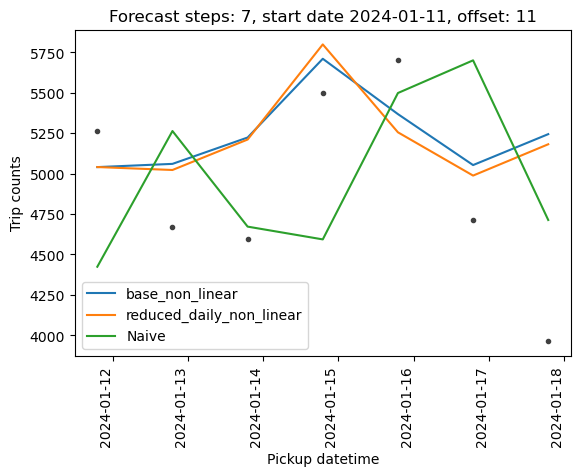

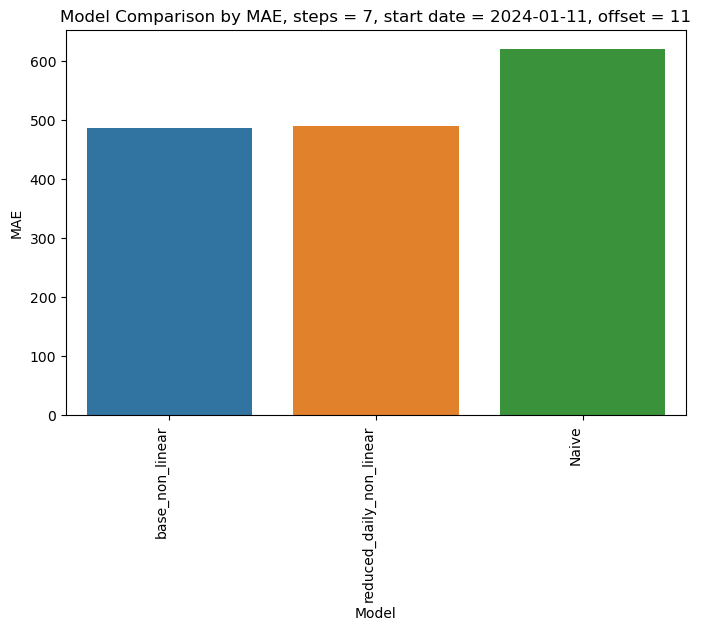

MAE: 1093.35 for step = 30, model = base_non_linear
MAE: 1026.87 for step = 30, model = reduced_daily_non_linear
MAE: 637.10 for step =  30, model = Naive



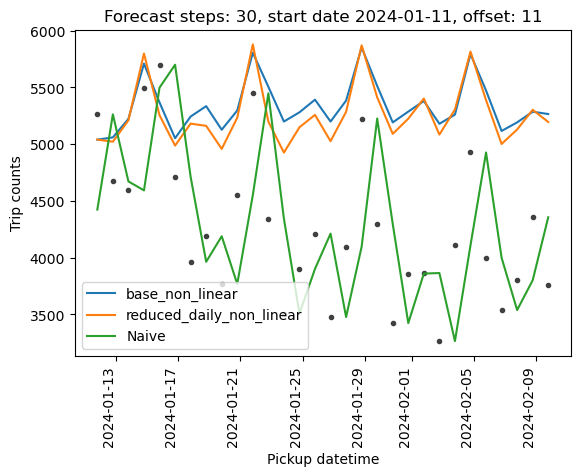

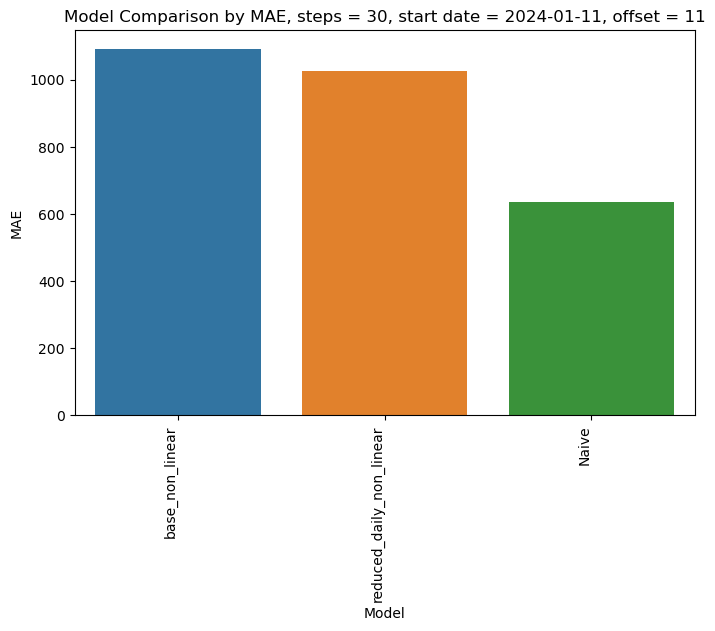

MAE: 968.88 for step = 60, model = base_non_linear
MAE: 1010.01 for step = 60, model = reduced_daily_non_linear
MAE: 607.33 for step =  30, model = Naive



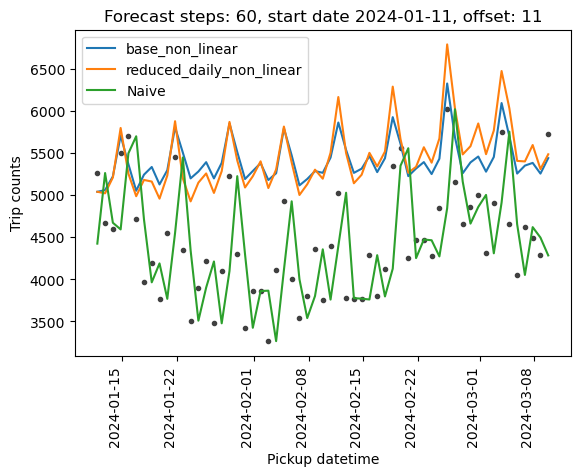

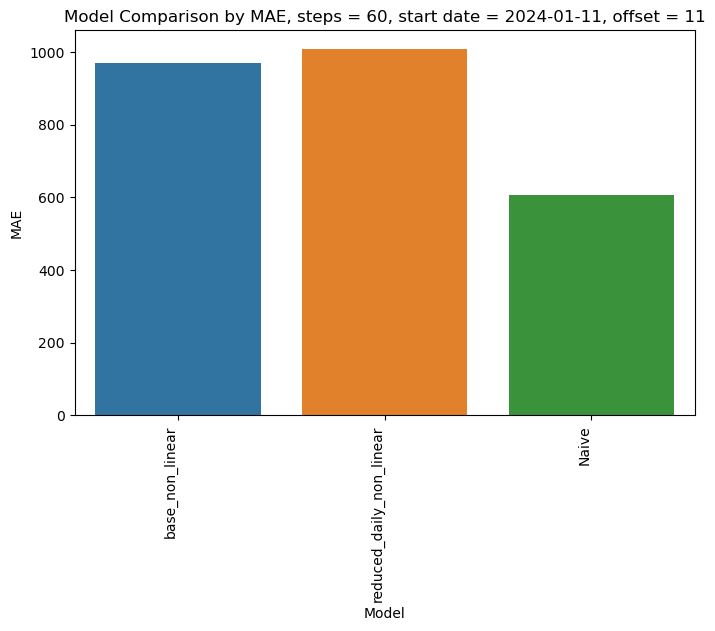


Average MAE scores for step 60:
base_non_linear, average MAE: 565.19
reduced_daily_non_linear, average MAE: 560.42
Naive, average MAE: 640.27

Average MAE scores for step 30:
base_non_linear, average MAE: 551.56
reduced_daily_non_linear, average MAE: 546.03
Naive, average MAE: 630.26

Average MAE scores for step 7:
base_non_linear, average MAE: 475.45
reduced_daily_non_linear, average MAE: 463.33
Naive, average MAE: 602.31


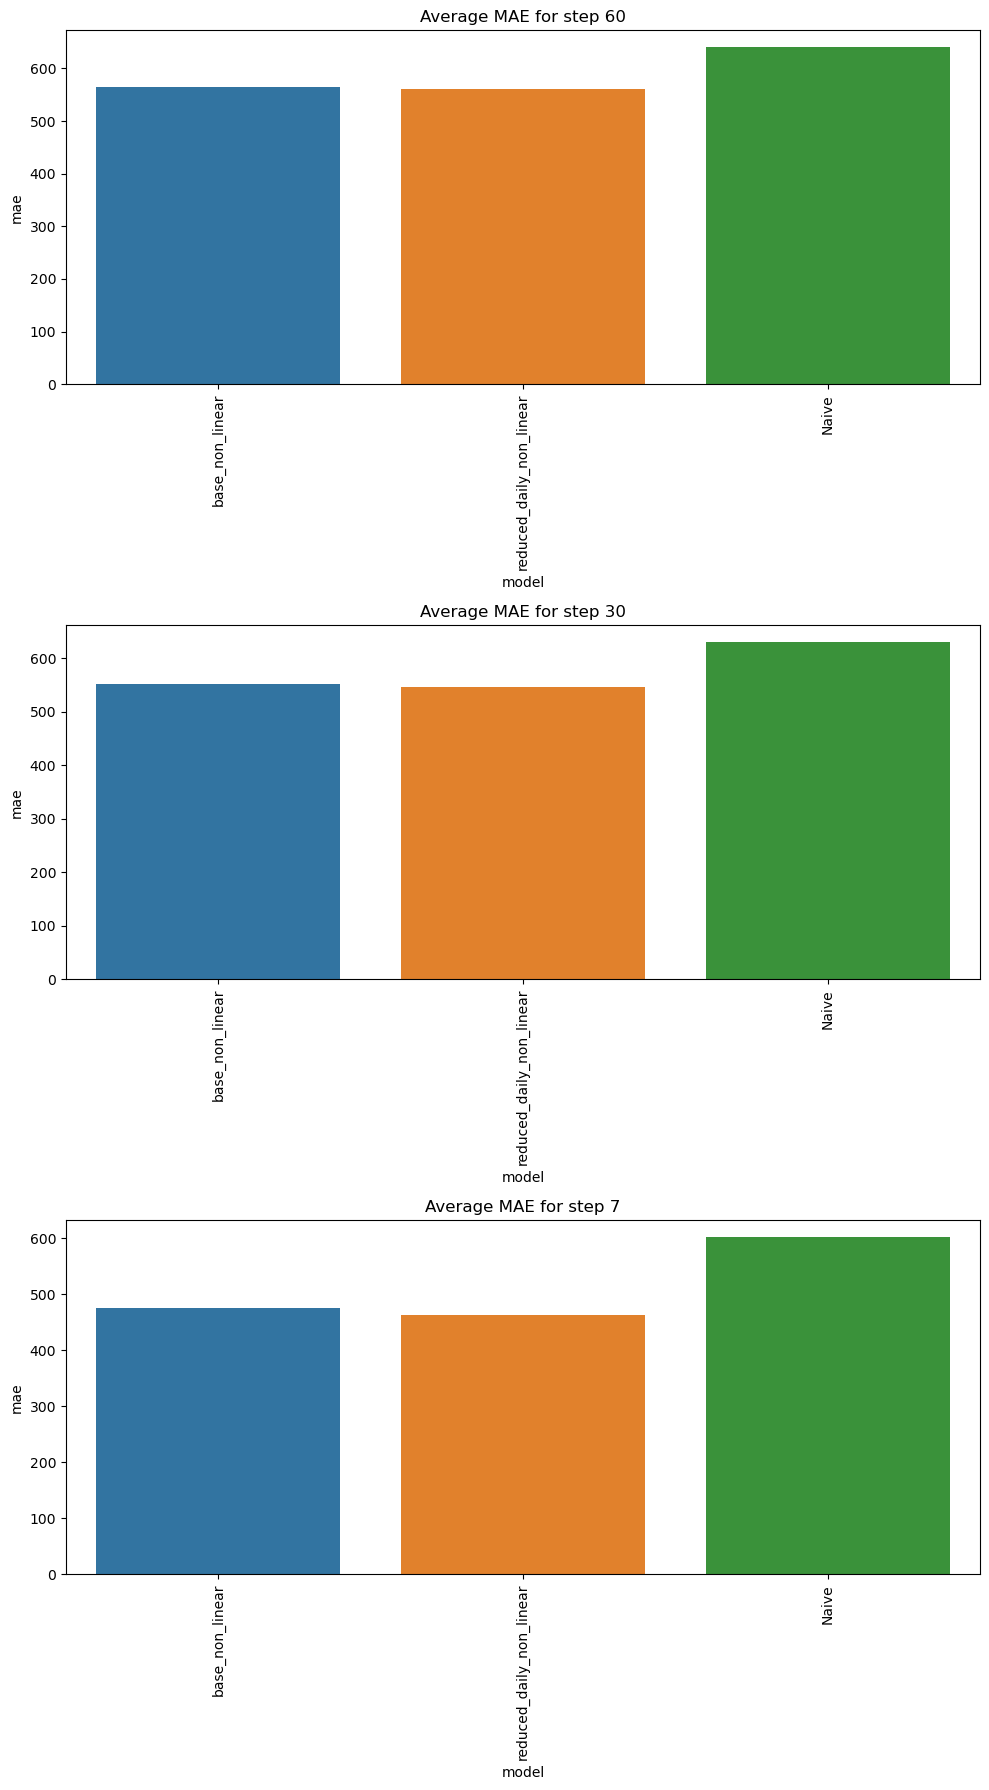

In [33]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In the above base_non_linear is the original xgboost model trained on the full feature set from 4_modelling. Reduced_daily_non_linear is now xgboost trained on the reduced feature set for the daily time series. What's interesting about the above is if you look at the average MAE scores across the 3 forecast steps you see that the reduced model outperforms the original!

Breaking it down by forecast step:

For the 7 day forecast reduced_daily_non_linear has an average MAE of 453.33 compared to 475.45 of base_non_linear so a 4.7% improvement.

For the 30 day forecast reduced_daily_non_linear has an average MAE of 546.03 compared to 551.56 of base_non_linear so a 1.0% improvement.

For the 60 day forecast reduced_daily_non_linear has an average MAE of 560.42 compared to 565.19 of base_non_linear so a 0.8% improvement.

One of the possible explanations as to why xgboost has performed better on this reduced feature set is that it means when xgboost randomly samples the columns for a new tree it isn't including columns from the old feature set that perhaps aren't that helpful. Meaning it can focus around optimising for features like y_lag_1 which give an incredibly strong signal.

In [34]:
# daily linear models

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset list
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][DAILY_LINEAR_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_order_list"]

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training from the extracted features
lags = config["shap"][DAILY_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_daily_linear_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True




In [35]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [36]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["daily_linear"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 276.70 for step = 7, model = reduced_daily_linear_order0
MAE: 279.04 for step = 7, model = reduced_daily_linear_order1
MAE: 276.03 for step = 7, model = reduced_daily_linear_order2
MAE: 294.43 for step = 7, model = reduced_daily_linear_order3
MAE: 259.46 for step = 7, model = reduced_daily_linear_order4
MAE: 7434.61 for step = 7, model = reduced_daily_linear_order5
MAE: 361.28 for step = 7, model = linear_order0
MAE: 372.00 for step = 7, model = linear_order1
MAE: 365.42 for step = 7, model = linear_order2
MAE: 351.26 for step = 7, model = linear_order3
MAE: 378.59 for step = 7, model = linear_order4
MAE: 7434.61 for step = 7, model = linear_order5
MAE: 621.71 for step =  30, model = Naive



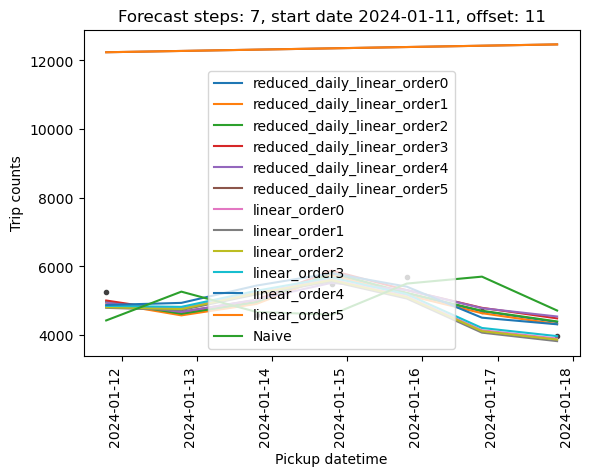

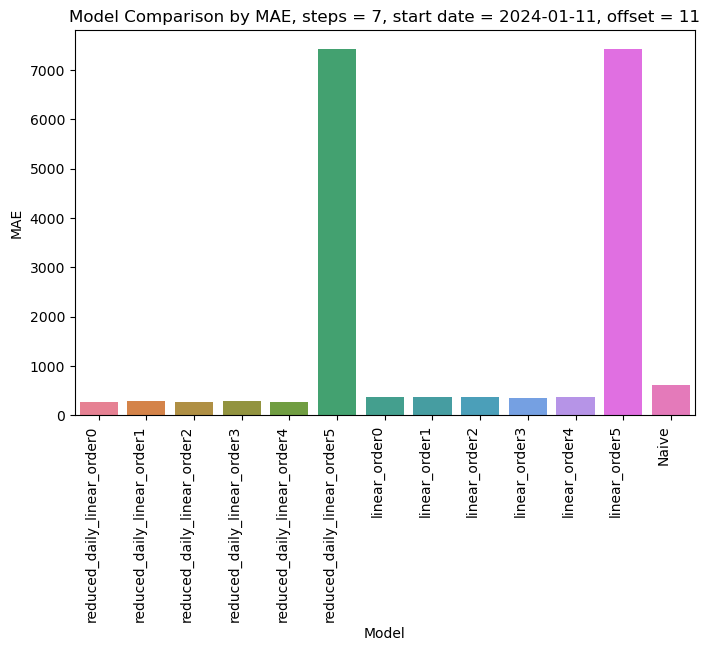

MAE: 520.64 for step = 30, model = reduced_daily_linear_order0
MAE: 433.41 for step = 30, model = reduced_daily_linear_order1
MAE: 549.40 for step = 30, model = reduced_daily_linear_order2
MAE: 695.35 for step = 30, model = reduced_daily_linear_order3
MAE: 628.41 for step = 30, model = reduced_daily_linear_order4
MAE: 8518.45 for step = 30, model = reduced_daily_linear_order5
MAE: 294.52 for step = 30, model = linear_order0
MAE: 323.09 for step = 30, model = linear_order1
MAE: 304.11 for step = 30, model = linear_order2
MAE: 305.40 for step = 30, model = linear_order3
MAE: 787.91 for step = 30, model = linear_order4
MAE: 8518.45 for step = 30, model = linear_order5
MAE: 637.10 for step =  30, model = Naive



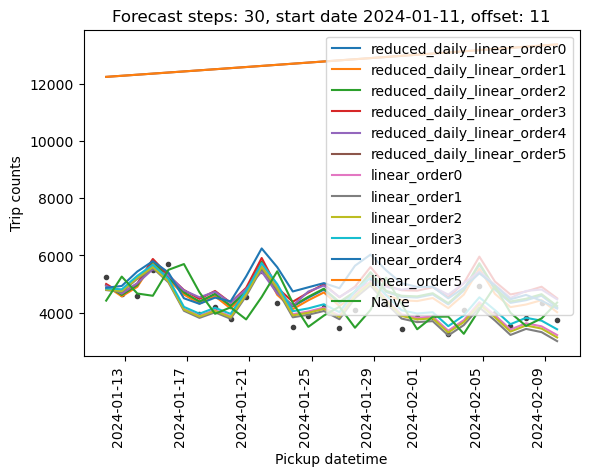

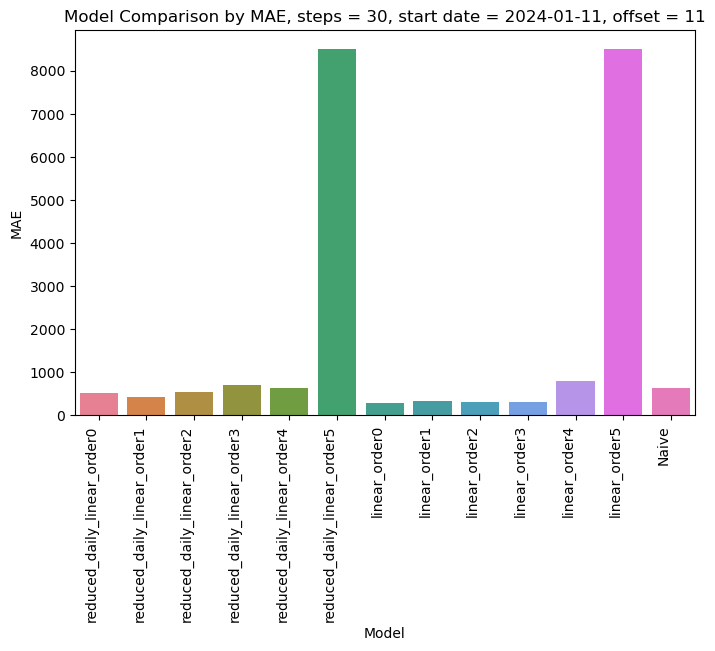

MAE: 452.77 for step = 60, model = reduced_daily_linear_order0
MAE: 421.52 for step = 60, model = reduced_daily_linear_order1
MAE: 473.23 for step = 60, model = reduced_daily_linear_order2
MAE: 664.16 for step = 60, model = reduced_daily_linear_order3
MAE: 610.29 for step = 60, model = reduced_daily_linear_order4
MAE: 8913.28 for step = 60, model = reduced_daily_linear_order5
MAE: 329.40 for step = 60, model = linear_order0
MAE: 362.53 for step = 60, model = linear_order1
MAE: 331.46 for step = 60, model = linear_order2
MAE: 398.95 for step = 60, model = linear_order3
MAE: 700.82 for step = 60, model = linear_order4
MAE: 8913.28 for step = 60, model = linear_order5
MAE: 607.33 for step =  30, model = Naive



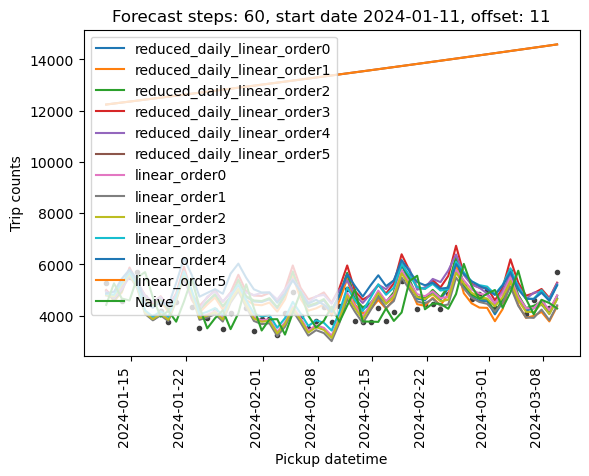

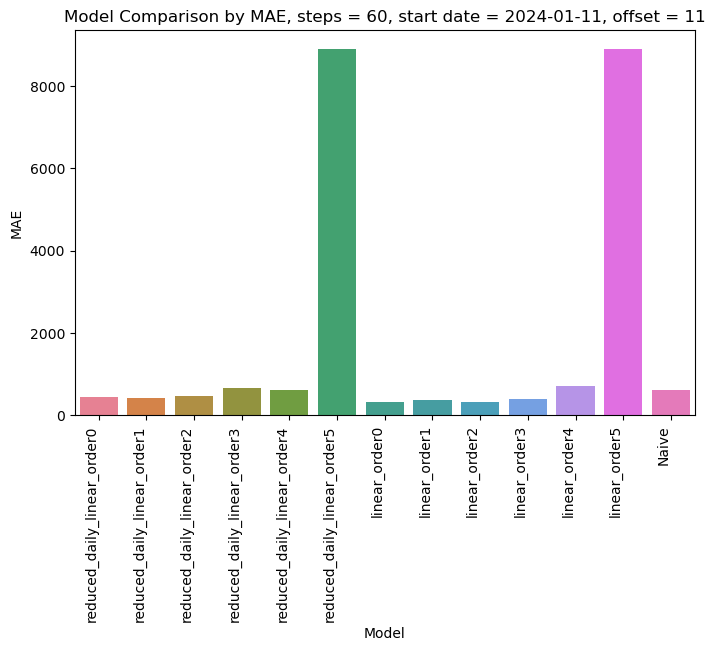


Average MAE scores for step 60:
reduced_daily_linear_order1, average MAE: 677.69
linear_order3, average MAE: 649.23
reduced_daily_linear_order5, average MAE: 21146.02
linear_order0, average MAE: 471.01
reduced_daily_linear_order0, average MAE: 610.29
linear_order4, average MAE: 689.39
linear_order5, average MAE: 21146.02
linear_order2, average MAE: 470.28
reduced_daily_linear_order4, average MAE: 638.46
linear_order1, average MAE: 508.87
reduced_daily_linear_order2, average MAE: 585.67
reduced_daily_linear_order3, average MAE: 667.65
Naive, average MAE: 640.27

Average MAE scores for step 30:
reduced_daily_linear_order1, average MAE: 534.90
linear_order3, average MAE: 507.44
reduced_daily_linear_order5, average MAE: 20245.98
linear_order0, average MAE: 418.62
reduced_daily_linear_order0, average MAE: 507.77
linear_order4, average MAE: 545.71
linear_order5, average MAE: 20245.98
linear_order2, average MAE: 415.41
reduced_daily_linear_order4, average MAE: 514.58
linear_order1, average M

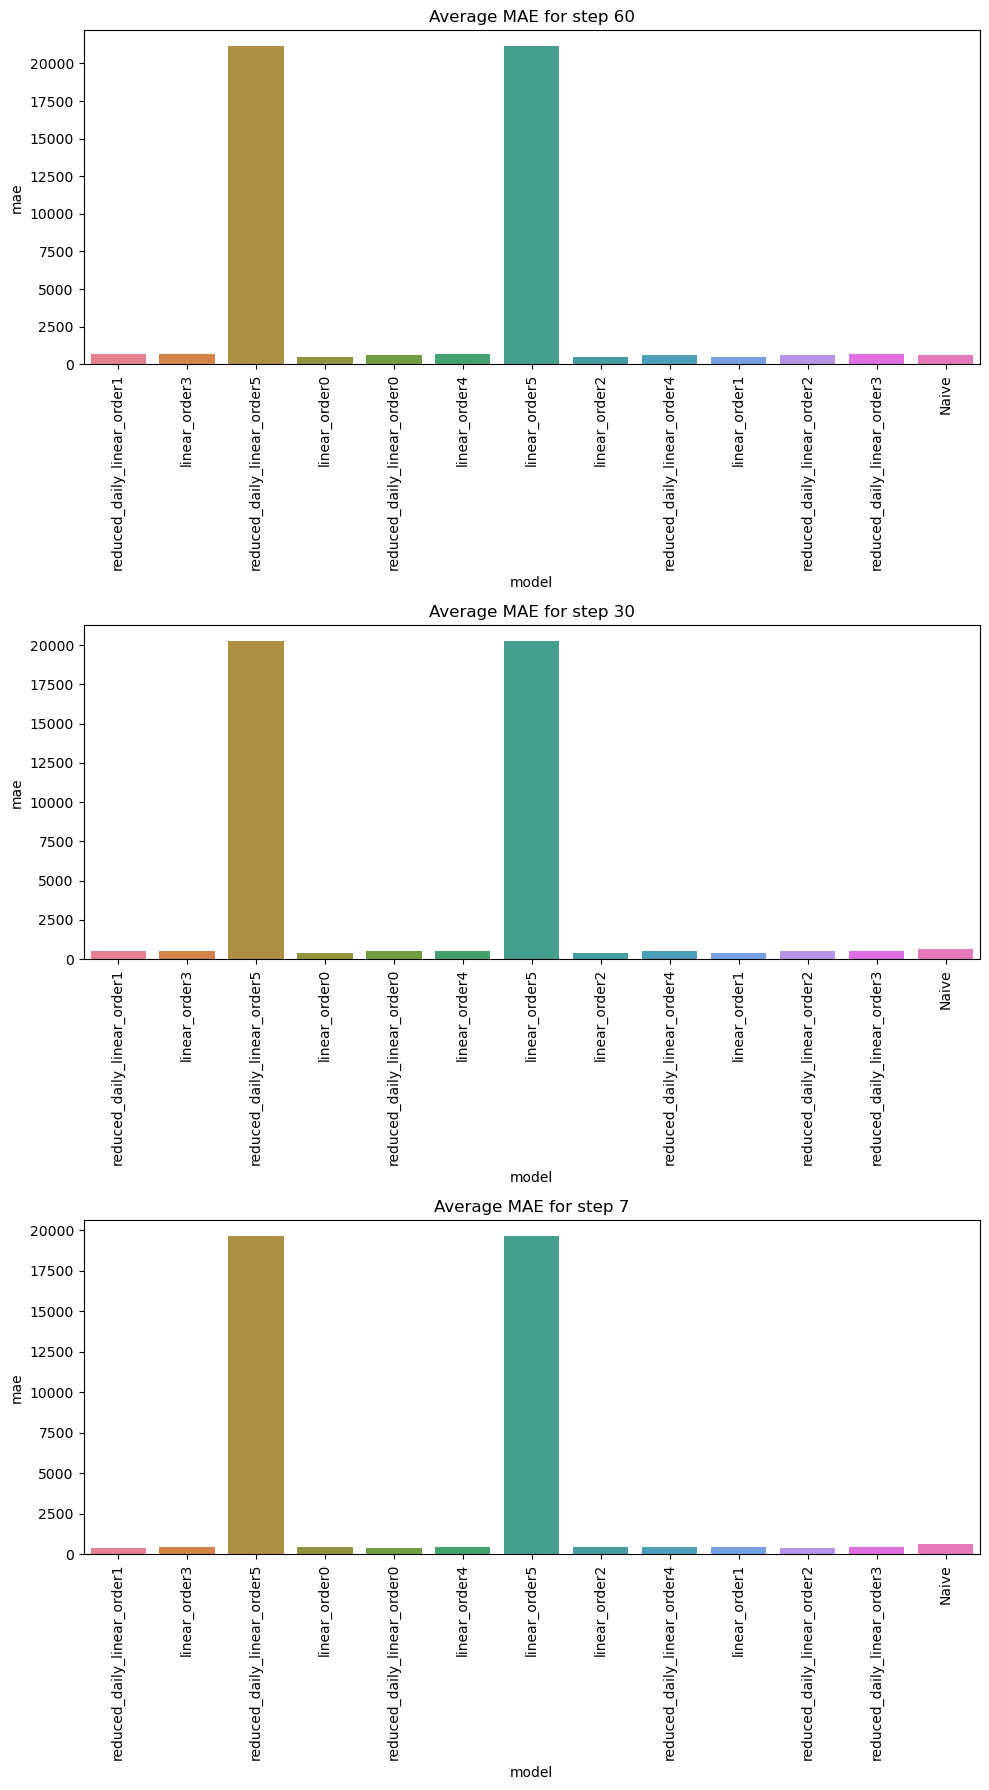

In [37]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

In the above we have fitted the reduced feature set to all of the previous linear model orders. The reduced feature set for daily linear doesn't include any trends. But because in the previous notebook we found that there was a notable difference in performance based off trend rather than just removing trend entirely we have decided to fit all the previous trends on this smaller feature set. Just to see whether again there is a difference between what trend we use for the deterministic process. 

For the 7 step forecast we see that the lowest average MAE among the reduced models is reduced_daily_linear_order0 at 407.67 (worth noting that this is closely followed by the 2nd order model). Whereas among the original models the lowest average MAE is linear_order2 with 421.30. So we are looking at a 3.2% improvement.

For the 30 day forecast we see that the lowest average MAE among the reduced models is reduced_daily_linear_order2 at 497.51 (followed closely by the order 0 model). Whereas among the original models the lowest average MAE is linear_order2 at 415.41. So this is actually 19.8% worse.

For the 60 day forecast we see that the lowest average MAE among the reduced models is reduced_daily_linear_order2 at 585.67. Whereas among the original models the lowest average MAE is linear_order2 at 470.28 so this is actually 24.5% worse.

So it seems pretty clear that for the pure linear regression the reduced feature set is worse expect for the 7 day forecast where it is only slightly better. This is perhaps to be expected. With xgboost when we create a reduced feature set it actually helps the model focus more on important features during training. However linear regression simply fits a set of linear coefficients for the features that minimises the loss. So actually reducing features is unlikely to improve the model unless the previous features were actually faulty or causing the model to make incorrect predicitons. Instead we have just reduced the amount of information linear regression has been able to work with, and so unsurprisingly it has produced worse models. This would suggest that possibly the best way forward would be to use a reduced feature set for xgboost (so non linear and hybrid) and use a full feature set for purely linear regression. But we need to check this holds across the other cases first.

In [38]:
# daily hybrid models (note we have kept the variable names as linear when we could change to hybrid but it makes no real difference)

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["daily_steps"]

# Offset list
offset_list = config["modelling"]["daily_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["daily_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][DAILY_HYBRID_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_hybrid_order_list"]

# Hybrid, the hybrid model we will be using
hybrid = XGBRegressor(
        n_estimators=config["xgboost_default"]["n_estimators"],
        early_stopping_rounds=config["xgboost_default"]["early_stopping_rounds"],
        learning_rate=config["xgboost_default"]["learning_rate"],
        max_depth=config["xgboost_default"]["max_depth"],
        subsample=config["xgboost_default"]["subsample"],
        colsample_bytree=config["xgboost_default"]["colsample_bytree"],
        random_state=config["xgboost_setup"]["random_state"],
        eval_metric=config["xgboost_setup"]["eval_metric"],
        tree_method=config["xgboost_setup"]["tree_method"],
        device=config["xgboost_setup"]["device"]
)

# Time step of the series
time_step = "D"

# Time series to use for training
ts_train = ts_daily_train

# Time series to use for testing
ts_test = ts_daily_test

# Lags for training from the extracted features
lags = config["shap"][DAILY_HYBRID_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = daily_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_daily_hybrid_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["daily_hybrid_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True



In [39]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [40]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["daily_hybrid"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 449.24 for step = 7, model = reduced_daily_hybrid_order0
MAE: 438.15 for step = 7, model = reduced_daily_hybrid_order1
MAE: 492.10 for step = 7, model = reduced_daily_hybrid_order2
MAE: 865.97 for step = 7, model = reduced_daily_hybrid_order3
MAE: 328.90 for step = 7, model = hybrid_order0
MAE: 366.44 for step = 7, model = hybrid_order1
MAE: 397.13 for step = 7, model = hybrid_order2
MAE: 341.85 for step = 7, model = hybrid_order3
MAE: 621.71 for step =  30, model = Naive



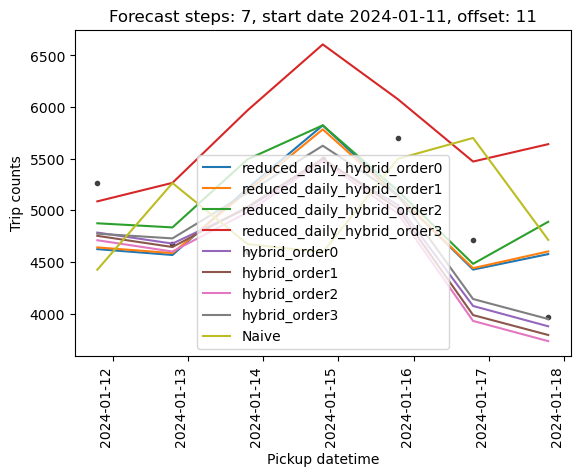

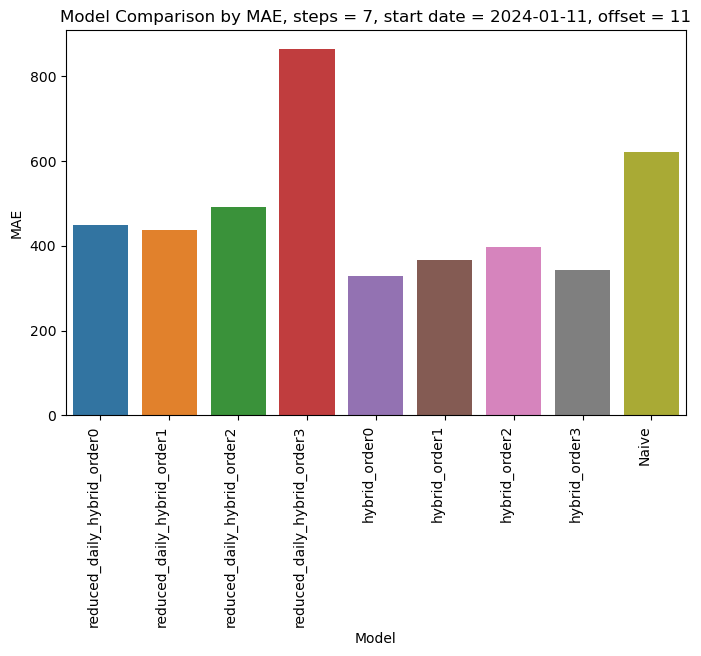

MAE: 301.09 for step = 30, model = reduced_daily_hybrid_order0
MAE: 338.21 for step = 30, model = reduced_daily_hybrid_order1
MAE: 594.92 for step = 30, model = reduced_daily_hybrid_order2
MAE: 2198.46 for step = 30, model = reduced_daily_hybrid_order3
MAE: 331.93 for step = 30, model = hybrid_order0
MAE: 313.63 for step = 30, model = hybrid_order1
MAE: 357.92 for step = 30, model = hybrid_order2
MAE: 350.40 for step = 30, model = hybrid_order3
MAE: 637.10 for step =  30, model = Naive



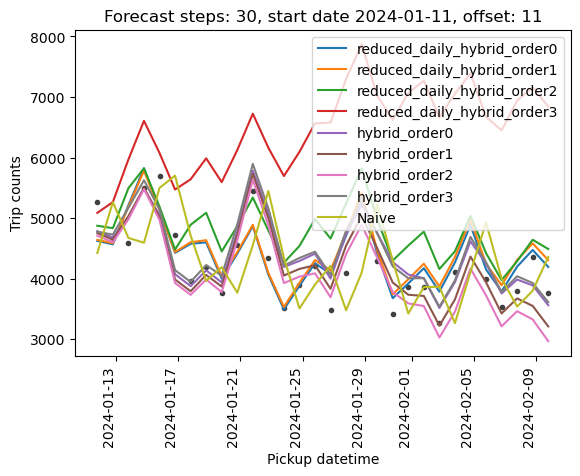

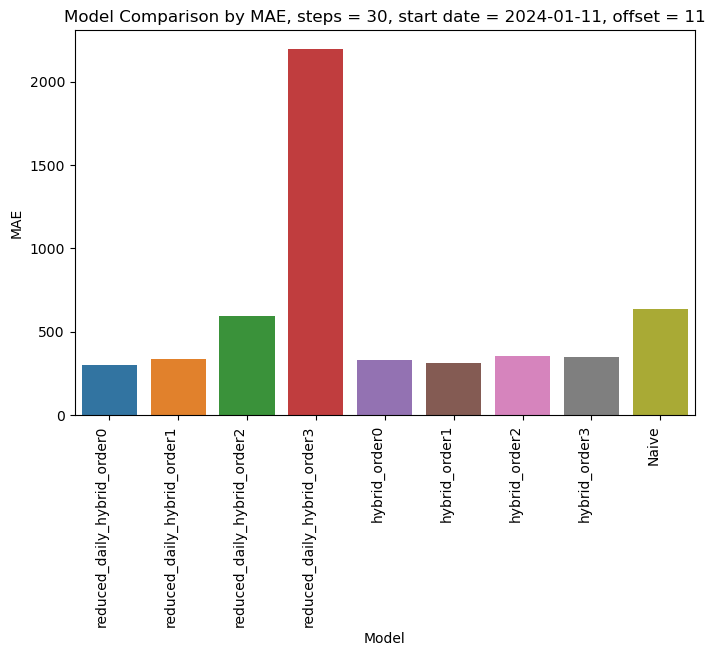

MAE: 373.72 for step = 60, model = reduced_daily_hybrid_order0
MAE: 428.64 for step = 60, model = reduced_daily_hybrid_order1
MAE: 814.44 for step = 60, model = reduced_daily_hybrid_order2
MAE: 3002.37 for step = 60, model = reduced_daily_hybrid_order3
MAE: 472.09 for step = 60, model = hybrid_order0
MAE: 336.86 for step = 60, model = hybrid_order1
MAE: 392.77 for step = 60, model = hybrid_order2
MAE: 526.93 for step = 60, model = hybrid_order3
MAE: 607.33 for step =  30, model = Naive



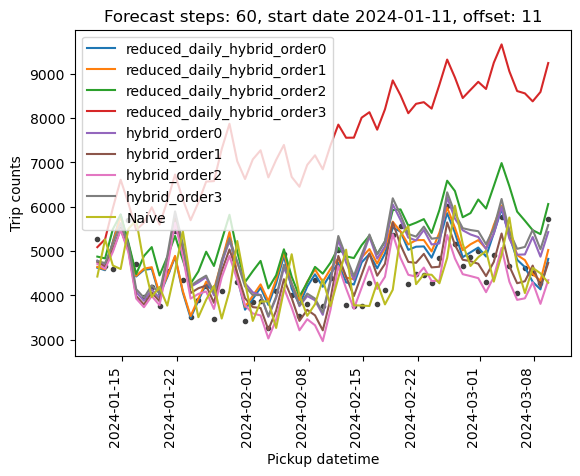

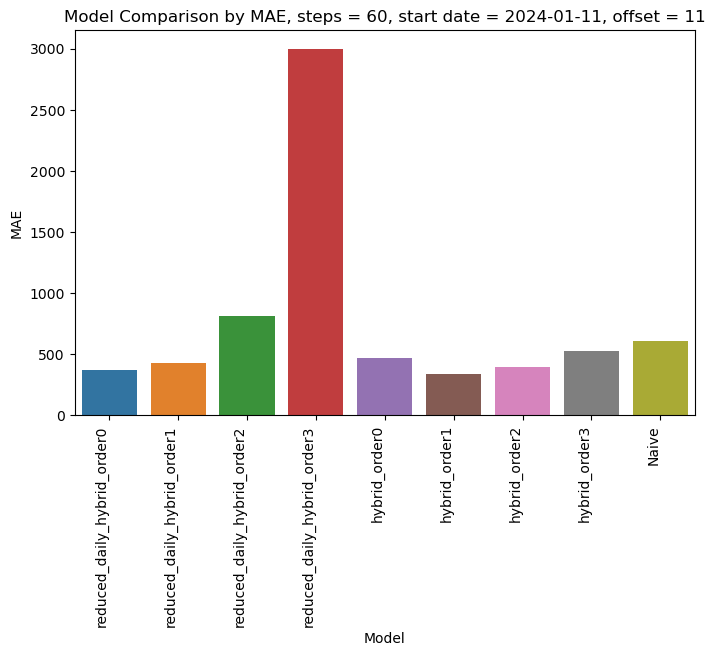


Average MAE scores for step 60:
reduced_daily_hybrid_order1, average MAE: 532.85
hybrid_order2, average MAE: 601.76
hybrid_order0, average MAE: 492.43
reduced_daily_hybrid_order2, average MAE: 1538.32
reduced_daily_hybrid_order3, average MAE: 3121.26
hybrid_order3, average MAE: 827.94
reduced_daily_hybrid_order0, average MAE: 529.05
hybrid_order1, average MAE: 499.39
Naive, average MAE: 640.27

Average MAE scores for step 30:
reduced_daily_hybrid_order1, average MAE: 471.74
hybrid_order2, average MAE: 455.42
hybrid_order0, average MAE: 435.66
reduced_daily_hybrid_order2, average MAE: 1129.87
reduced_daily_hybrid_order3, average MAE: 2443.93
hybrid_order3, average MAE: 593.80
reduced_daily_hybrid_order0, average MAE: 466.76
hybrid_order1, average MAE: 435.05
Naive, average MAE: 630.26

Average MAE scores for step 7:
reduced_daily_hybrid_order1, average MAE: 414.14
hybrid_order2, average MAE: 414.65
hybrid_order0, average MAE: 418.08
reduced_daily_hybrid_order2, average MAE: 627.05
redu

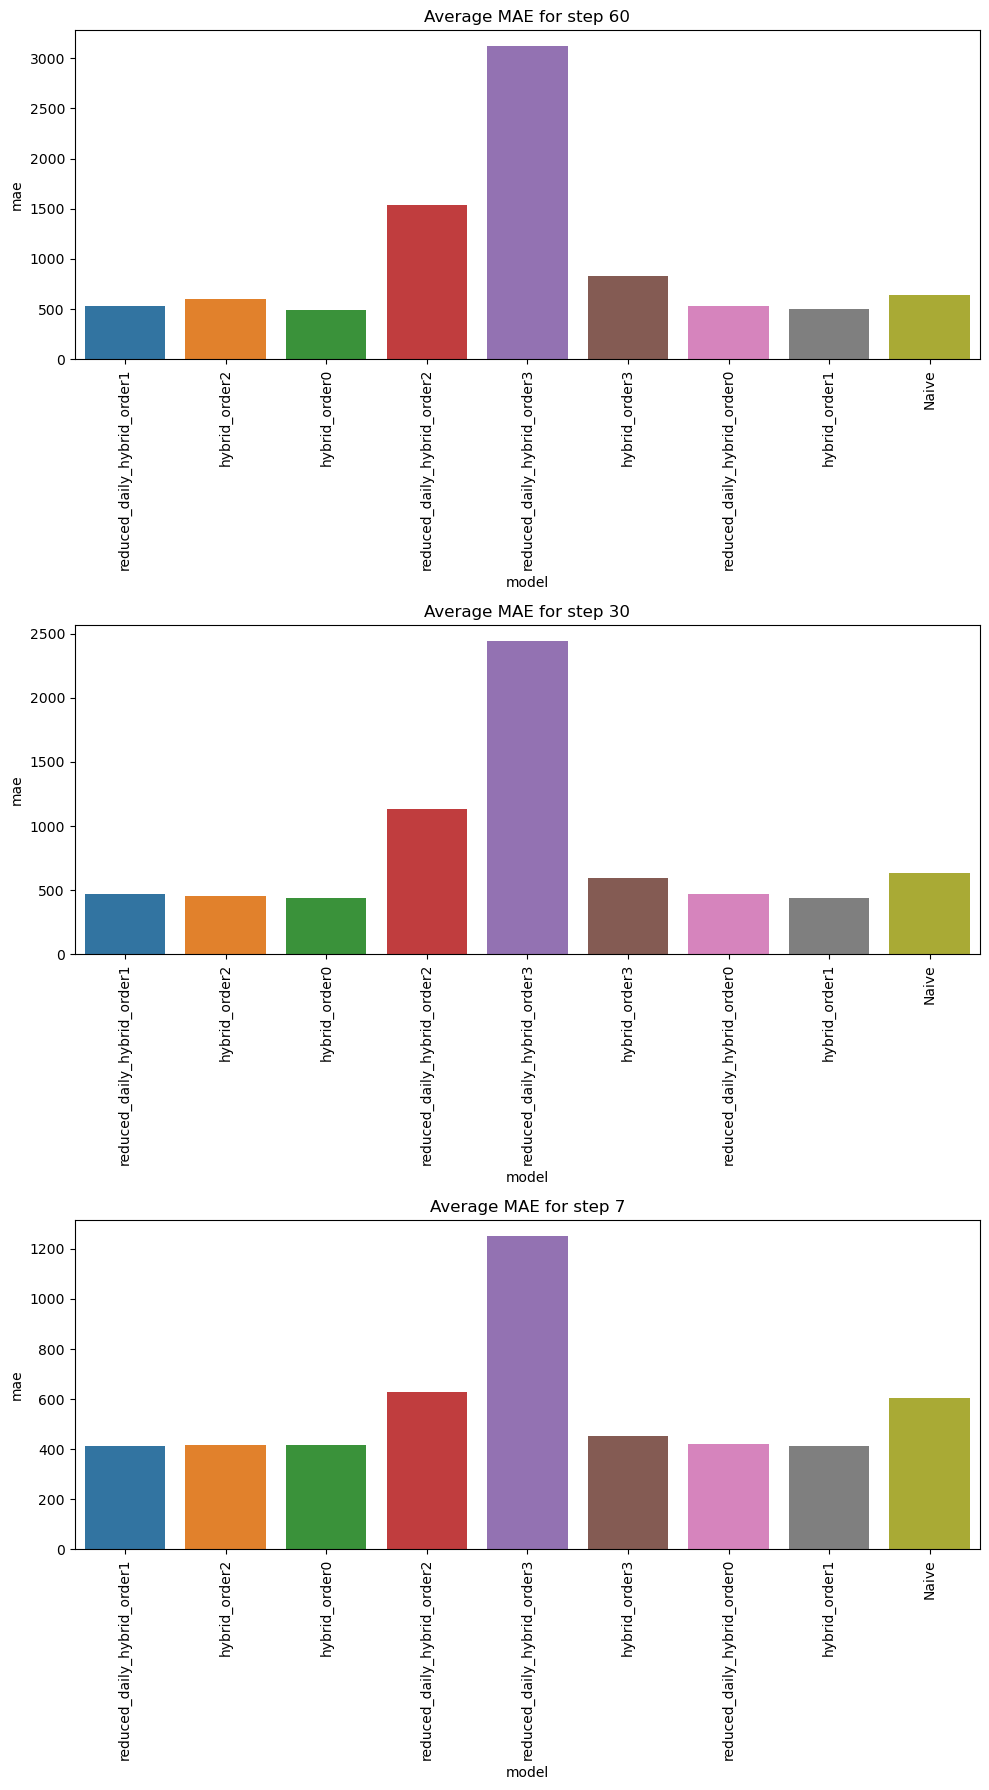

In [41]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)


Again we have done the same orders for the hybrid models as we did in 4_modelling for the same reason as the previous comment outlined in the linear case.

For the 7 day forecast we have that the lowest average MAE among the reduced models is reduced_hybrid_order0 with 418.62. Whereas for the orignal hybrid models the lowest average MAE is hybrid_order0 with 418.08. So this is 0.1% worse by average MAE. 

For the 30 day forecast we have the lowest average MAE among the reduced models is reduced_hybrid_order0 at 466.76. Whereas for the original hybrid models the lowest average MAE is hybrid_order0 with 435.66. So this is 7.1% worse by average MAE.

For the 60 day forecast we have the lowest average MAE among the reduced models is reduced_daily_hybrid_order0 with 529.05. Whereas for the original hybrid models the lowest average MAE is hybrid_order0 with 492.43. So this is 7.4% worse by average MAE.

The above is interesting, clearly we see that reducing the feature set makes the hybrid models worse. Here it now becomes a question of explanability of the model and computational time for bayesian hyperparamter tuning. The original daily feature set is 336 lags + 20 yearly fourier features (10 harmonics) + 10 weekly fourier features (5 harmonics) ignoring any trend/constant terms. So that is 366 features. The reduced feature set for the hybrid daily case (you can look this up in config.yml under shap/daily_hybrid_order2) is yearly fourier features + 27 lags. That is only 47 features. So a reduction of over 7.5 times. That will be significant when it comes to hyperparamter tuning and just normal training/prediction. The fact that the average MAE is only worse by at most 7.4% may make this trade off worthwhile. We are actually going to use the reduced feature set for the hybrid models because we want to do hyperparamter optimisation for xgboost, and it would also mean that explanability, particulalrly for a tree based model like xgboost is a lot easier. Even though it actually performs slightly worse compared to the full feature set models.

In [42]:
# Now time for the hourly models
# First up is the hourly non linear model

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset list
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_fourier_features"]

# List of trend orders for our linear models, as we aren't using any linear models just set empty 
order_list = []

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training from the extracted features
lags = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = []

# Non linear name list 
names_non_linear = [config["model_naming"]["reduced_hourly_non_linear_model_prefix"]]

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_non_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True



In [43]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [44]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous non linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["hourly_linear"])

# Add the older non_linear_model to the new one
non_linear_models_loaded = {**old_non_linear_models_loaded, **non_linear_models_loaded}

MAE: 27.64 for step = 24, model = base_non_linear
MAE: 28.97 for step = 24, model = reduced_hourly_non_linear
MAE: 47.88 for step =  30, model = Naive



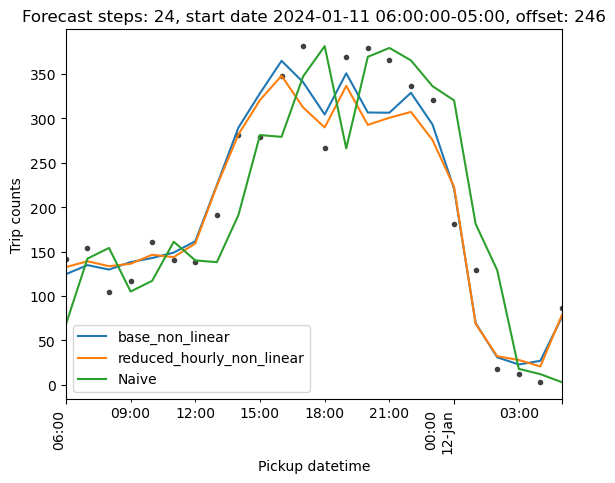

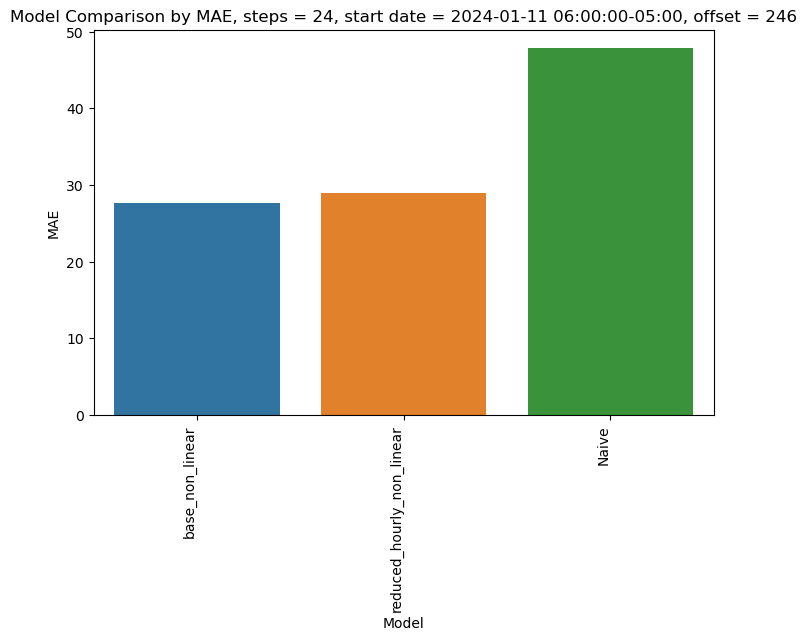

MAE: 23.75 for step = 48, model = base_non_linear
MAE: 26.04 for step = 48, model = reduced_hourly_non_linear
MAE: 46.19 for step =  30, model = Naive



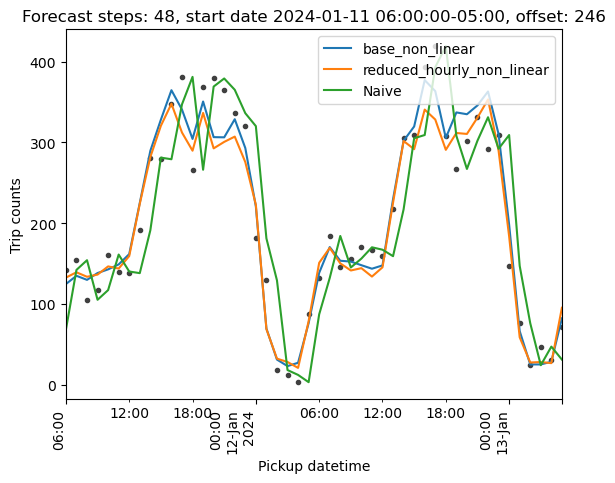

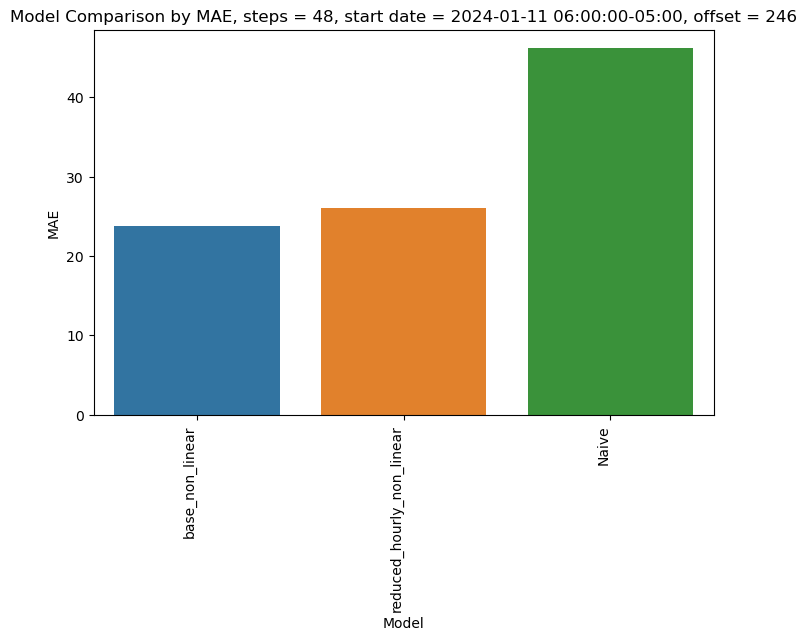

MAE: 34.24 for step = 168, model = base_non_linear
MAE: 34.50 for step = 168, model = reduced_hourly_non_linear
MAE: 52.86 for step =  30, model = Naive



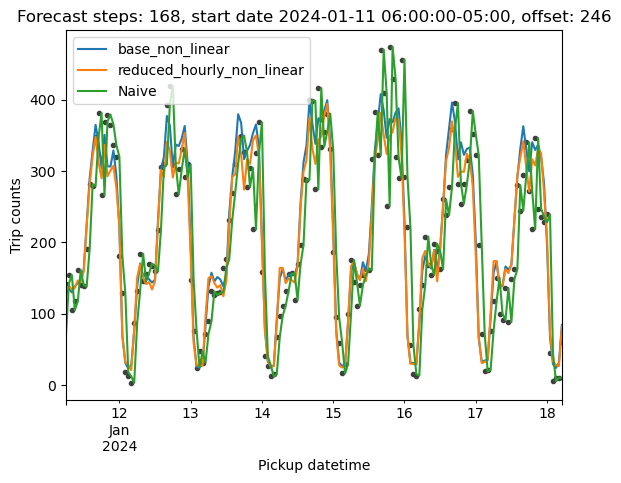

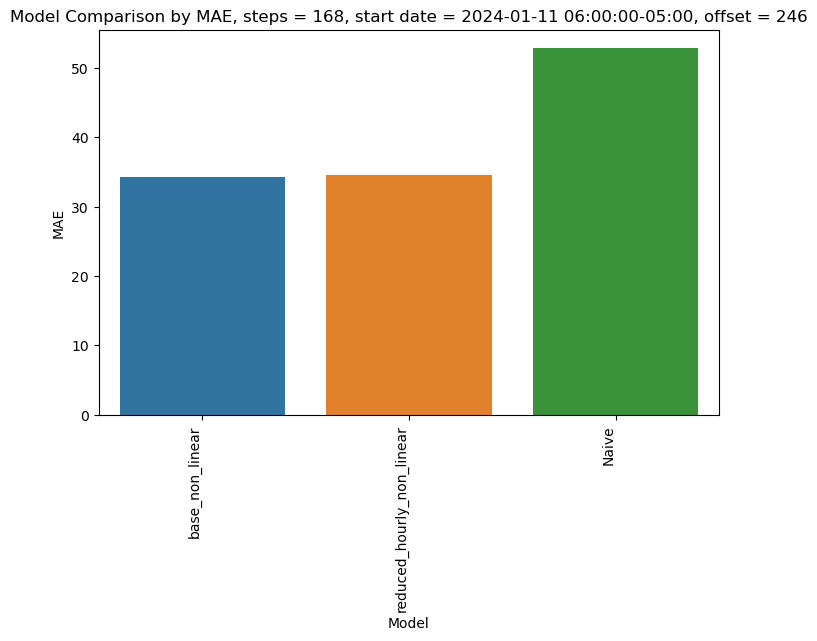


Average MAE scores for step 24:
base_non_linear, average MAE: 33.05
reduced_hourly_non_linear, average MAE: 32.07
Naive, average MAE: 51.45

Average MAE scores for step 48:
base_non_linear, average MAE: 34.17
reduced_hourly_non_linear, average MAE: 33.70
Naive, average MAE: 52.47

Average MAE scores for step 168:
base_non_linear, average MAE: 35.17
reduced_hourly_non_linear, average MAE: 35.73
Naive, average MAE: 53.72


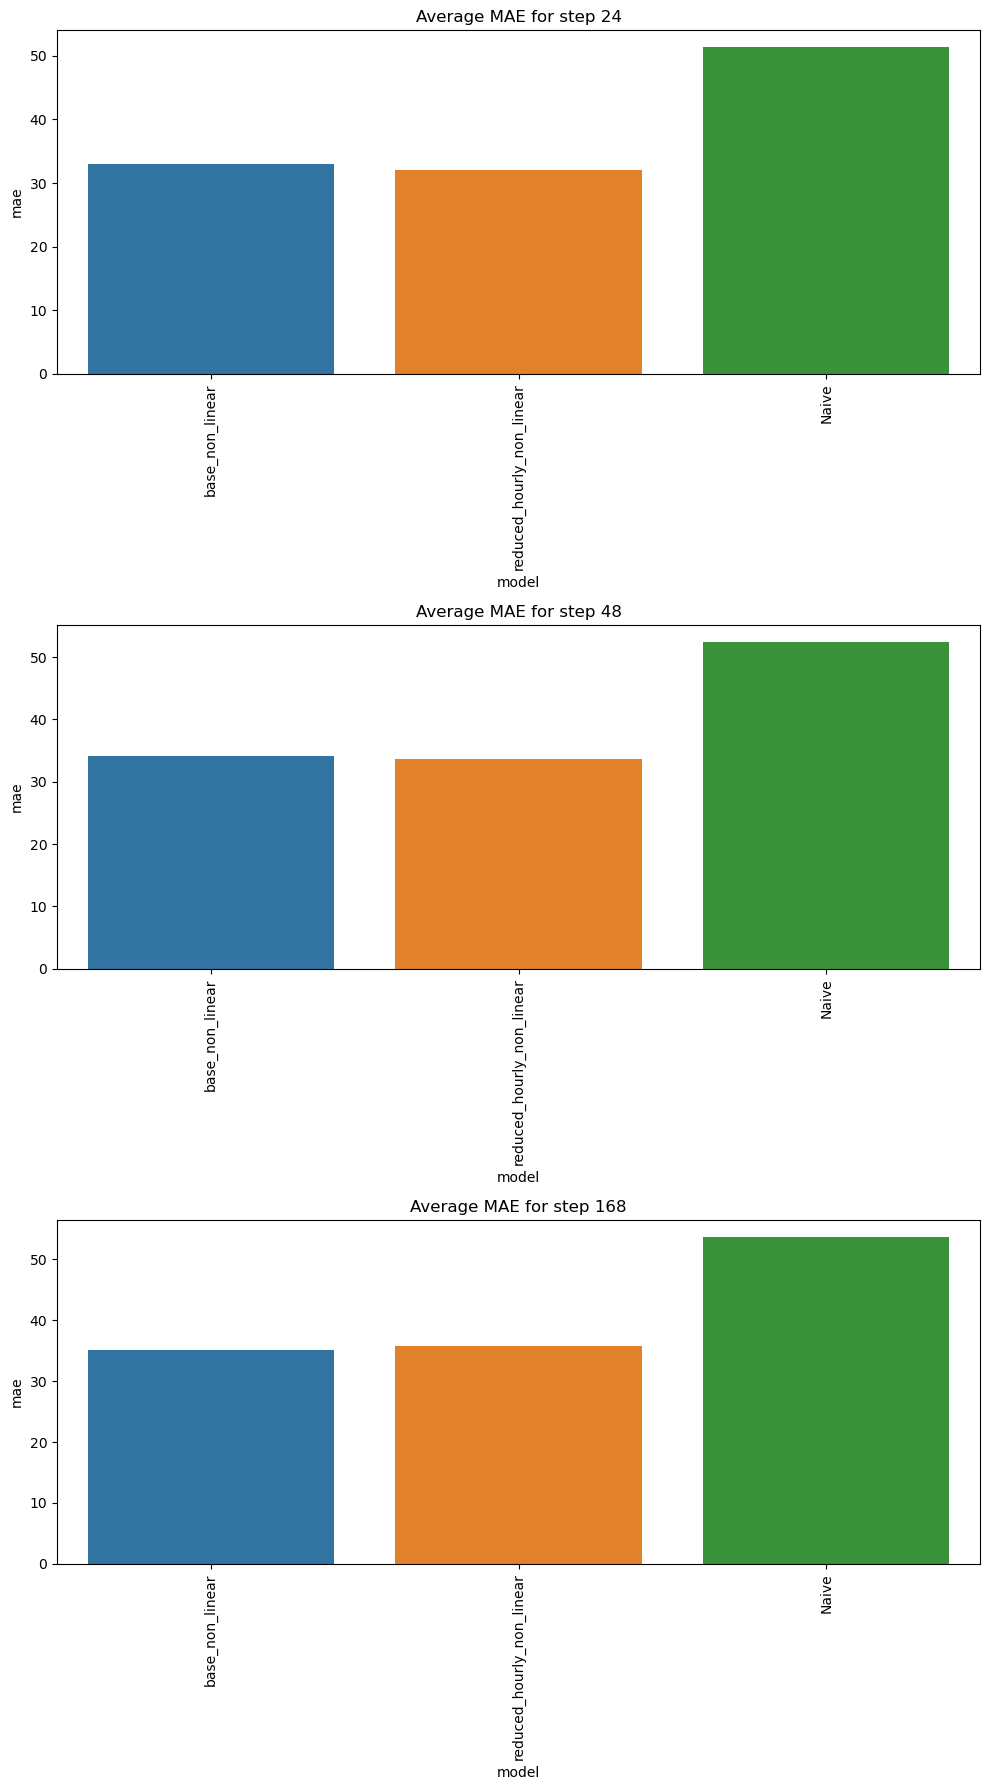

In [45]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

We now have done the same for the hourly non linear models. 

For the 24 hour forecast we see that reduced_hourly_non_linear has an average MAE of 32.07. Whereas base_non_linear has an average MAE of 33.05. So we have a 3.0% improvement by average MAE.

For the 48 hour forecast we see that reduced_hourly_non_linear has an average MAE of 33.70. Whereas base_non_linear has an average MAE of 34.17. So we have a 1.4% improvement by average MAE.

For the 168 hour forecast we see that reduced_hourly_non_linear has an average MAE of 35.73. Whereas base_non_linear has an average MAE of 35.17. So this is 1.6% worse by average MAE.

So what we see is the reduced feature set offers a slight improvement in the 24 and 48 hour forecasts and makes the xgboost model slightly worse in the 168 hour forecast. Now it is worth looking at by how much we have reduced the feature set size by here to put this into context (you can read config/config.yml and preprocess in forecast_helpers.py to find this). The full hourly feature set for the non linear models is 336 lags + 22 extra lags + 10 weekly fourier features (5 harmonics) + 10 daily fourier features (5 harmonics) so in total 378 features. Whereas the reduced feature set for the hourly non linear model is 10 daily fourier featuers (5 harmonics) + 29 lags so in total 39 features. So this is a roughly 9.7 times reduction in the number of features. So considering the model performance is only at worst 1.6% worse by average MAE it is well worth using the reduced feature set for all the previous benefits mentioned: faster fit and predict times which will be very helpful for Bayesian hyperparamter tuining later, as well as improved model explanability.

In [46]:
# hourly linear models

# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset list
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][HOURLY_LINEAR_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_order_list"] # the order lists are the same daily and hourly

# Hybrid, the hybrid model we will be using
hybrid = None

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training from the extracted features
lags = config["shap"][HOURLY_LINEAR_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_hourly_linear_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_linear_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True

In [47]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [48]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["hourly_linear"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 28.34 for step = 24, model = reduced_hourly_linear_order0
MAE: 29.65 for step = 24, model = reduced_hourly_linear_order1
MAE: 32.63 for step = 24, model = reduced_hourly_linear_order2
MAE: 209.05 for step = 24, model = reduced_hourly_linear_order3
MAE: 198.16 for step = 24, model = reduced_hourly_linear_order4
MAE: 176.39 for step = 24, model = reduced_hourly_linear_order5
MAE: 26.62 for step = 24, model = linear_order0
MAE: 26.69 for step = 24, model = linear_order1
MAE: 27.31 for step = 24, model = linear_order2
MAE: 209.05 for step = 24, model = linear_order3
MAE: 198.16 for step = 24, model = linear_order4
MAE: 176.39 for step = 24, model = linear_order5
MAE: 47.88 for step =  30, model = Naive



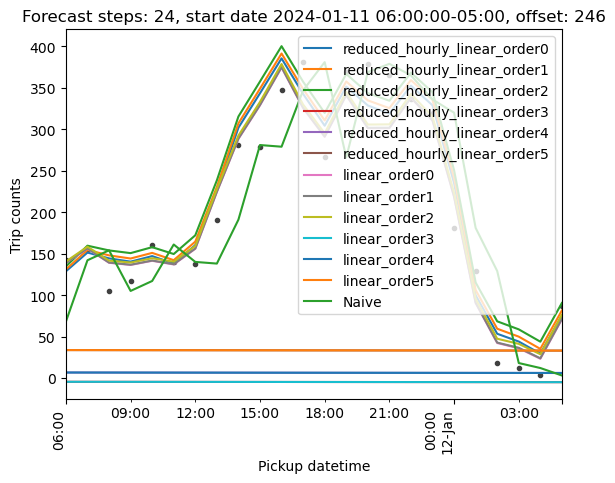

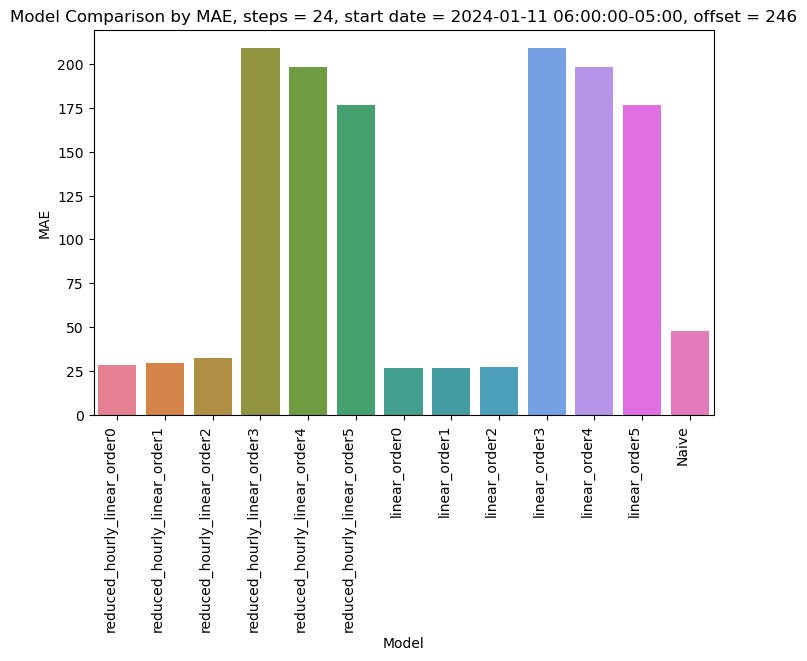

MAE: 25.33 for step = 48, model = reduced_hourly_linear_order0
MAE: 27.00 for step = 48, model = reduced_hourly_linear_order1
MAE: 31.84 for step = 48, model = reduced_hourly_linear_order2
MAE: 210.54 for step = 48, model = reduced_hourly_linear_order3
MAE: 199.58 for step = 48, model = reduced_hourly_linear_order4
MAE: 175.62 for step = 48, model = reduced_hourly_linear_order5
MAE: 23.91 for step = 48, model = linear_order0
MAE: 23.88 for step = 48, model = linear_order1
MAE: 23.90 for step = 48, model = linear_order2
MAE: 210.53 for step = 48, model = linear_order3
MAE: 199.58 for step = 48, model = linear_order4
MAE: 175.62 for step = 48, model = linear_order5
MAE: 46.19 for step =  30, model = Naive



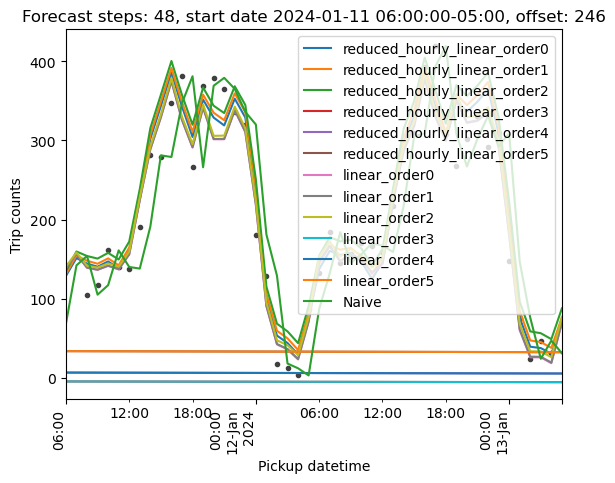

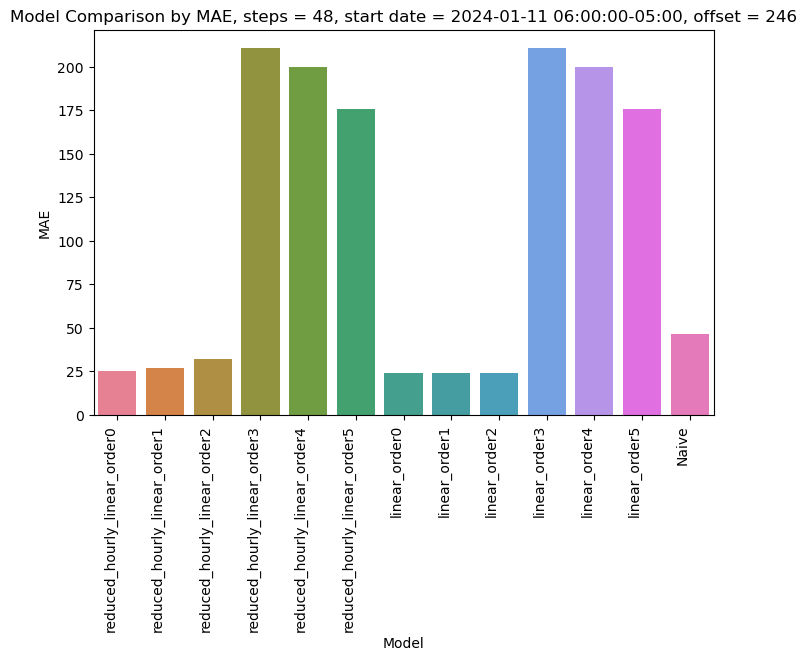

MAE: 33.08 for step = 168, model = reduced_hourly_linear_order0
MAE: 35.63 for step = 168, model = reduced_hourly_linear_order1
MAE: 41.67 for step = 168, model = reduced_hourly_linear_order2
MAE: 213.29 for step = 168, model = reduced_hourly_linear_order3
MAE: 202.57 for step = 168, model = reduced_hourly_linear_order4
MAE: 178.68 for step = 168, model = reduced_hourly_linear_order5
MAE: 31.84 for step = 168, model = linear_order0
MAE: 31.94 for step = 168, model = linear_order1
MAE: 33.77 for step = 168, model = linear_order2
MAE: 213.29 for step = 168, model = linear_order3
MAE: 202.57 for step = 168, model = linear_order4
MAE: 178.68 for step = 168, model = linear_order5
MAE: 52.86 for step =  30, model = Naive



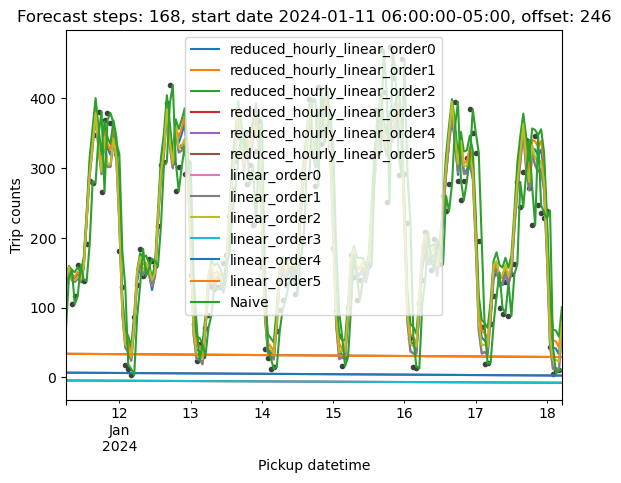

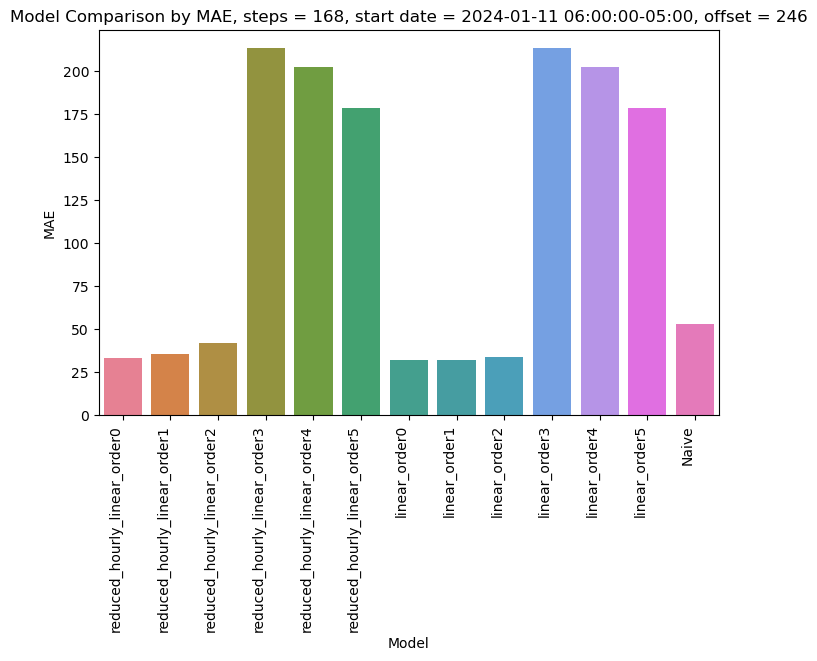


Average MAE scores for step 24:
linear_order3, average MAE: 359.91
linear_order0, average MAE: 31.60
reduced_hourly_linear_order4, average MAE: 401.56
reduced_hourly_linear_order0, average MAE: 32.73
reduced_hourly_linear_order1, average MAE: 33.53
reduced_hourly_linear_order3, average MAE: 359.91
reduced_hourly_linear_order2, average MAE: 37.09
linear_order4, average MAE: 401.56
reduced_hourly_linear_order5, average MAE: 416.29
linear_order2, average MAE: 32.64
linear_order5, average MAE: 416.29
linear_order1, average MAE: 31.67
Naive, average MAE: 51.45

Average MAE scores for step 48:
linear_order3, average MAE: 363.31
linear_order0, average MAE: 32.71
reduced_hourly_linear_order4, average MAE: 405.07
reduced_hourly_linear_order0, average MAE: 34.00
reduced_hourly_linear_order1, average MAE: 34.90
reduced_hourly_linear_order3, average MAE: 363.32
reduced_hourly_linear_order2, average MAE: 39.01
linear_order4, average MAE: 405.07
reduced_hourly_linear_order5, average MAE: 419.80
lin

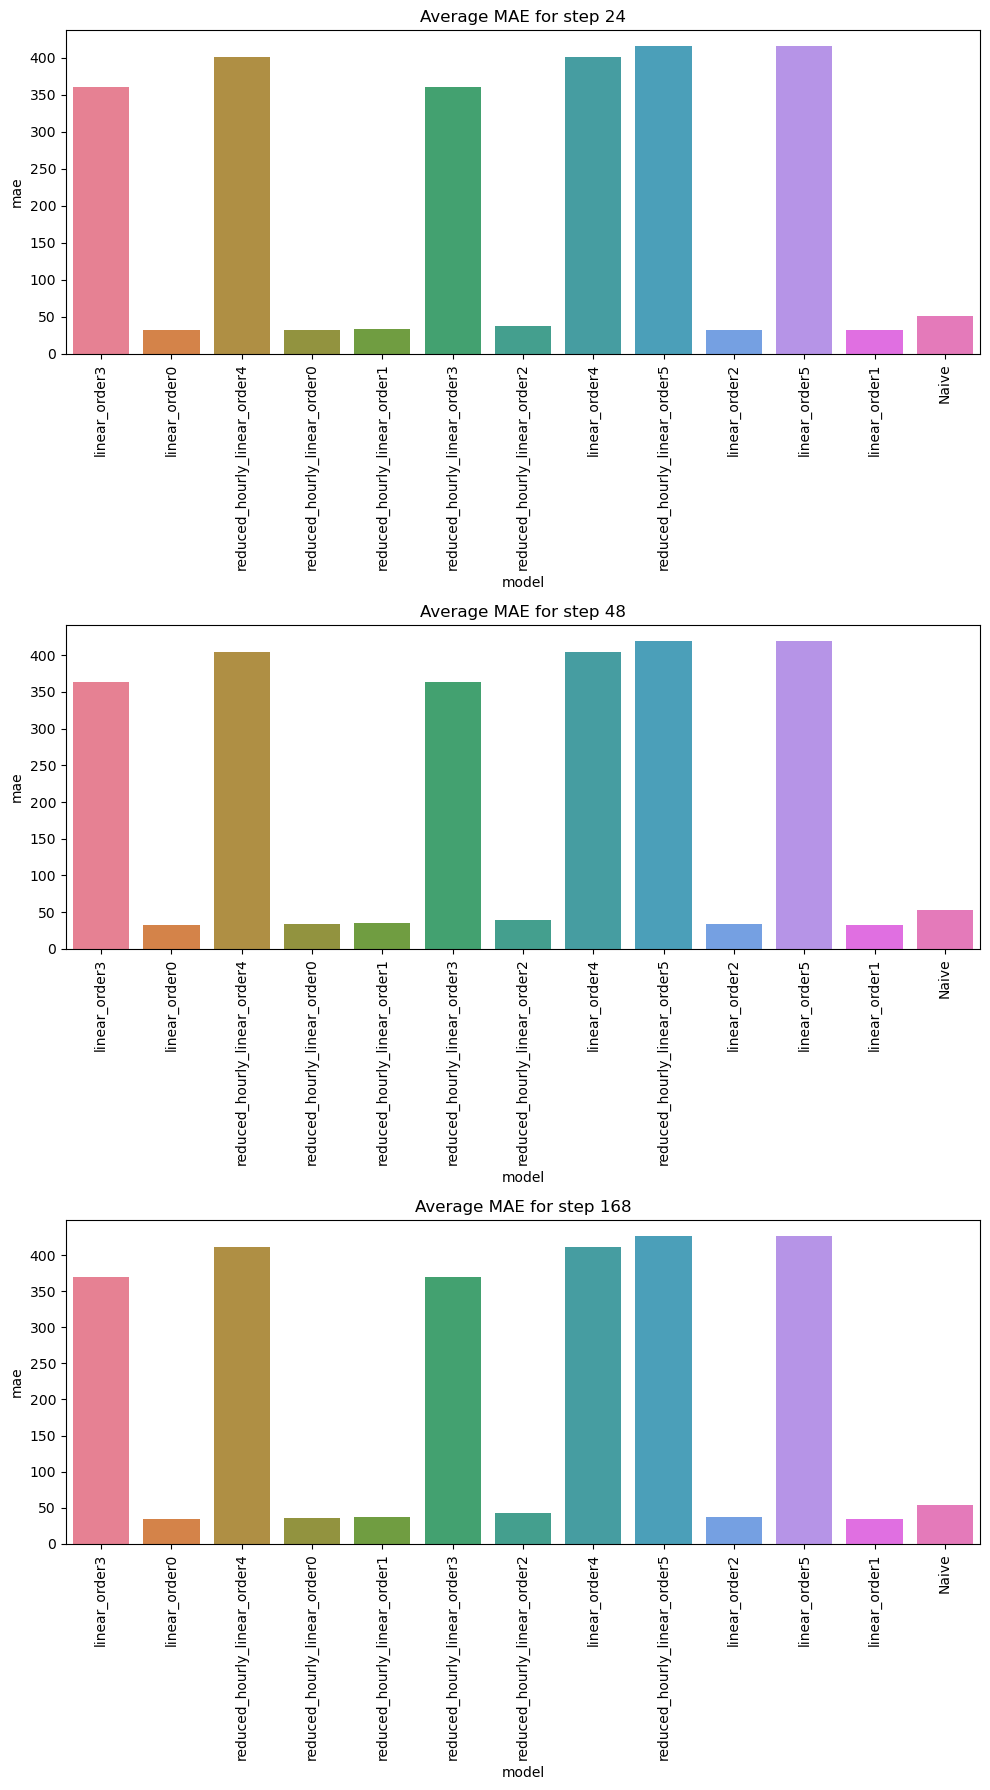

In [49]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)

We have again done the same for the hourly linear models, to make the comments here a bit easier to read we will only report the model with the lowest average MAE across the offsets for both the original models and their reduced feature set counterparts.

For the 24 hour forecast we have the lowest average MAE among the reduced models is reduced_hourly_linear_order0 at 32.73. Whereas among the original models the lowest average MAE is linear_order0 at 31.60. So this is 3.6% worse by average MAE.

For the 48 hour forecast we have the lowest average MAE among the reduced models is reduced_hourly_linear_order0 at 34.00. Whereas among the original models the lowest average MAE is linear_order0 at 32.71. So this is 3.9% worse by average MAE.

For the 168 hour forecast we have the lowest average MAE among the reduced models is reduced_hourly_linear_order0 at 36.06. Whereas among the original models the lowest average MAE is linear_order0 at 34.93. So this is 3.2% worse by average MAE.

So again like in the daily case we see that the reduced models are worse for the linear regressions. However in terms of percentage average MAE change they aren't as much worse. Recall for the daily case we had a 24.5% increase in average MAE for the 60 day forecast. Again for the linear regressions there isn't as clear gains in using the reduced feature set as fit and predict times are already low so it would mostly be gains in model explanability. So it is likely worth keeping the full feature set for purely linear regressions in the hourly case as well, for the improved average MAE across the offsets.

In [50]:
# hourly hybrid models 
 
# Steps for the forecast (read config.yml to see and change the steps for the forecast)
steps = config["modelling"]["hourly_steps"]

# Offset list
offset_list = config["modelling"]["hourly_offset"]

# List of offsets to show the forecasts for
offset_to_show = config["modelling"]["hourly_offsets_to_show"]

# Fourier features from extracted features
fourier_features = config["shap"][HOURLY_HYBRID_NAME]["extracted_fourier_features"]

# This is where I am going to slightly go against what was found using the top 30 features by mean abs shap value
# For both the daily and hourly time series the linear models didn't have any trend features in the top 30 (same for the linear part of the hybrid models as they are the same).
# This means that the SHAP values are suggesting that the trend features aren't very important for the linear models. However from the modelling
# notebook we do see a significant difference between the linear models based purely on difference in order, so we are going to test for order again but will include an order 0 model
# so just intercept to see whether that model is really superior to the others. (you can find the list in config.yml)
order_list = config["shap"]["daily_hybrid_order_list"]

# Hybrid, the hybrid model we will be using
hybrid = XGBRegressor(
        n_estimators=config["xgboost_default"]["n_estimators"],
        early_stopping_rounds=config["xgboost_default"]["early_stopping_rounds"],
        learning_rate=config["xgboost_default"]["learning_rate"],
        max_depth=config["xgboost_default"]["max_depth"],
        subsample=config["xgboost_default"]["subsample"],
        colsample_bytree=config["xgboost_default"]["colsample_bytree"],
        random_state=config["xgboost_setup"]["random_state"],
        eval_metric=config["xgboost_setup"]["eval_metric"],
        tree_method=config["xgboost_setup"]["tree_method"],
        device=config["xgboost_setup"]["device"]
)

# Time step of the series
time_step = "h"

# Time series to use for training
ts_train = ts_hourly_train

# Time series to use for testing
ts_test = ts_hourly_test

# Lags for training from the extracted features
lags = config["shap"][HOURLY_HYBRID_NAME]["extracted_lags"]

# Old lags list (this needs to be appened to the old models for when we forecast)
old_lags = used_hourly_lags

# Linear name list (list of names for the linear models)
names_linear = [f"{config['model_naming']['reduced_hourly_hybrid_model_prefix']}{i}" for i in order_list]

# Non linear name list 
names_non_linear = []

# Signature for the file names (this will be how we keep track of which files belong to which models when it comes to hyperparamter tuning)
sig = config["model_sigs"]["hourly_hybrid_reduced"]

# Naive baseline (bool to determine whether or not to inlcude a naive baseline in the plots, the naive baseline will just predict time step value t as time step value t-1)
naive = True




In [51]:
# Create train and save the models
create_train_save_models(names_linear, names_non_linear, hybrid, sig, order_list, lags, fourier_features, time_step, ts_train)

In [52]:
# Load the models (and the deterministic processes)
linear_models_loaded, non_linear_models_loaded = load_models(sig)

# Load the previous linear model
old_linear_models_loaded, old_non_linear_models_loaded = load_models(config["model_sigs"]["hourly_hybrid"])

# Add the older non_linear_model to the new one
linear_models_loaded = {**linear_models_loaded, **old_linear_models_loaded}

MAE: 26.37 for step = 24, model = reduced_hourly_hybrid_order0
MAE: 30.44 for step = 24, model = reduced_hourly_hybrid_order1
MAE: 36.83 for step = 24, model = reduced_hourly_hybrid_order2
MAE: 560.62 for step = 24, model = reduced_hourly_hybrid_order3
MAE: 26.31 for step = 24, model = hybrid_order0
MAE: 27.17 for step = 24, model = hybrid_order1
MAE: 29.08 for step = 24, model = hybrid_order2
MAE: 535.23 for step = 24, model = hybrid_order3
MAE: 47.88 for step =  30, model = Naive



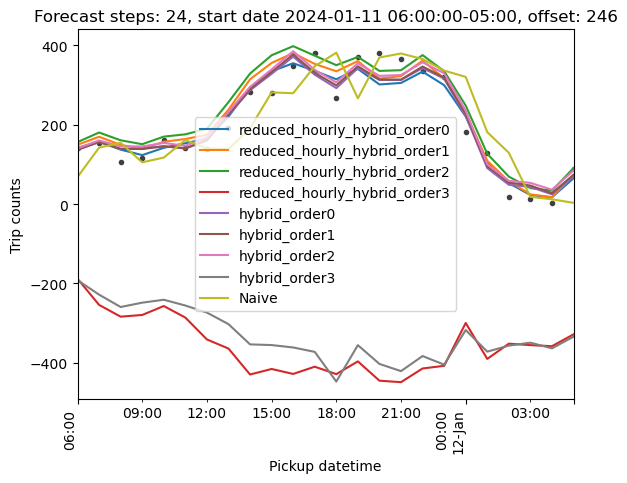

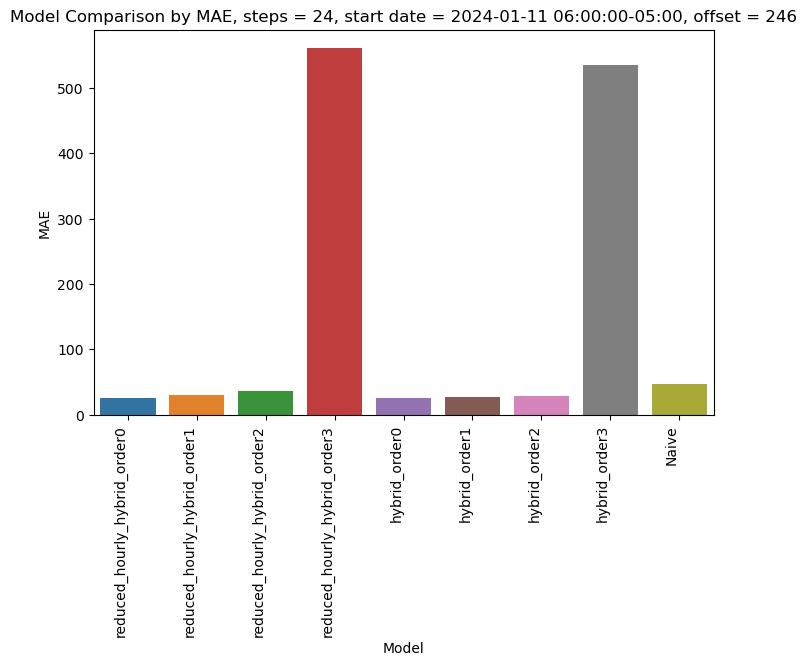

MAE: 23.63 for step = 48, model = reduced_hourly_hybrid_order0
MAE: 27.70 for step = 48, model = reduced_hourly_hybrid_order1
MAE: 36.81 for step = 48, model = reduced_hourly_hybrid_order2
MAE: 554.52 for step = 48, model = reduced_hourly_hybrid_order3
MAE: 23.81 for step = 48, model = hybrid_order0
MAE: 24.03 for step = 48, model = hybrid_order1
MAE: 27.62 for step = 48, model = hybrid_order2
MAE: 534.95 for step = 48, model = hybrid_order3
MAE: 46.19 for step =  30, model = Naive



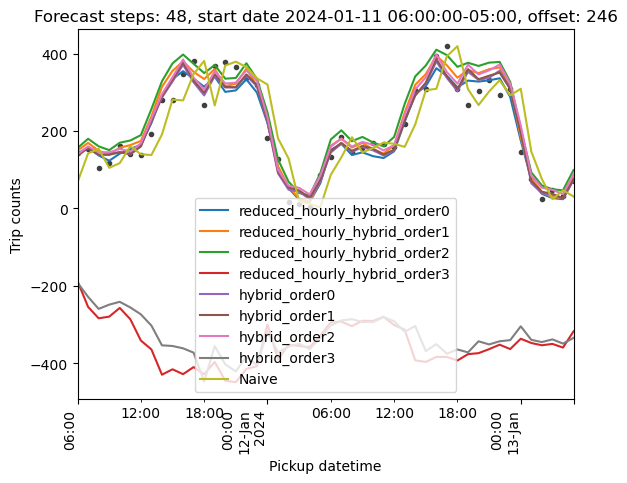

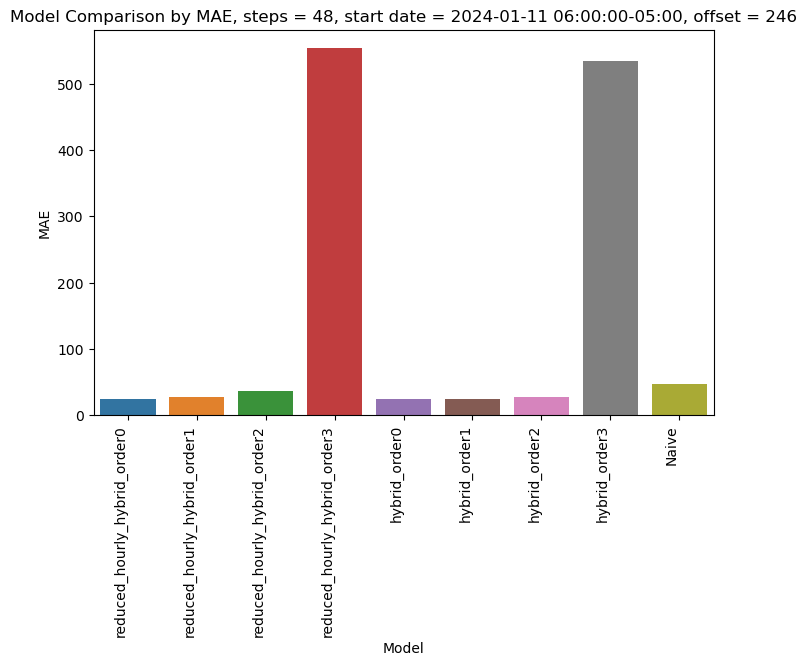

MAE: 32.75 for step = 168, model = reduced_hourly_hybrid_order0
MAE: 39.48 for step = 168, model = reduced_hourly_hybrid_order1
MAE: 55.41 for step = 168, model = reduced_hourly_hybrid_order2
MAE: 563.89 for step = 168, model = reduced_hourly_hybrid_order3
MAE: 32.90 for step = 168, model = hybrid_order0
MAE: 33.44 for step = 168, model = hybrid_order1
MAE: 41.02 for step = 168, model = hybrid_order2
MAE: 556.06 for step = 168, model = hybrid_order3
MAE: 52.86 for step =  30, model = Naive



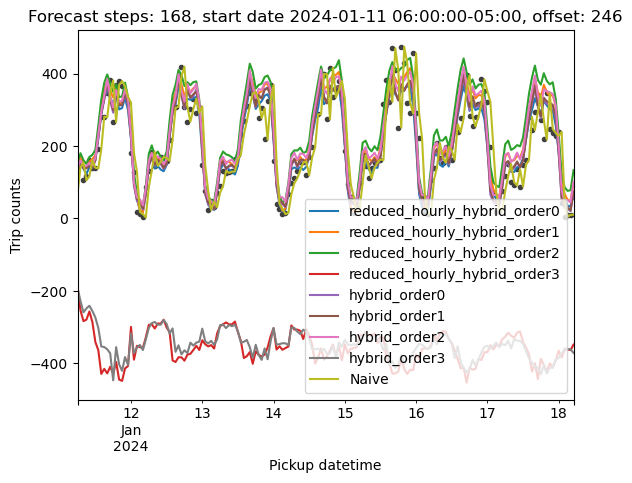

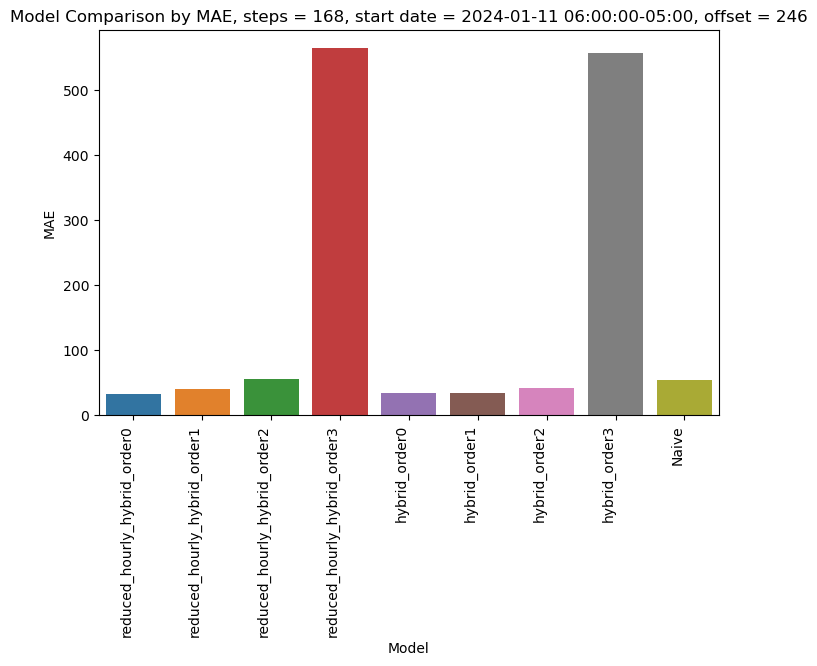


Average MAE scores for step 24:
reduced_hourly_hybrid_order3, average MAE: 817.98
reduced_hourly_hybrid_order2, average MAE: 46.14
hybrid_order2, average MAE: 37.95
hybrid_order0, average MAE: 31.66
reduced_hourly_hybrid_order0, average MAE: 31.17
hybrid_order3, average MAE: 795.29
hybrid_order1, average MAE: 31.87
reduced_hourly_hybrid_order1, average MAE: 34.85
Naive, average MAE: 51.45

Average MAE scores for step 48:
reduced_hourly_hybrid_order3, average MAE: 822.10
reduced_hourly_hybrid_order2, average MAE: 50.06
hybrid_order2, average MAE: 39.98
hybrid_order0, average MAE: 33.11
reduced_hourly_hybrid_order0, average MAE: 33.22
hybrid_order3, average MAE: 803.57
hybrid_order1, average MAE: 33.28
reduced_hourly_hybrid_order1, average MAE: 36.30
Naive, average MAE: 52.47

Average MAE scores for step 168:
reduced_hourly_hybrid_order3, average MAE: 840.86
reduced_hourly_hybrid_order2, average MAE: 63.98
hybrid_order2, average MAE: 45.20
hybrid_order0, average MAE: 34.73
reduced_hourl

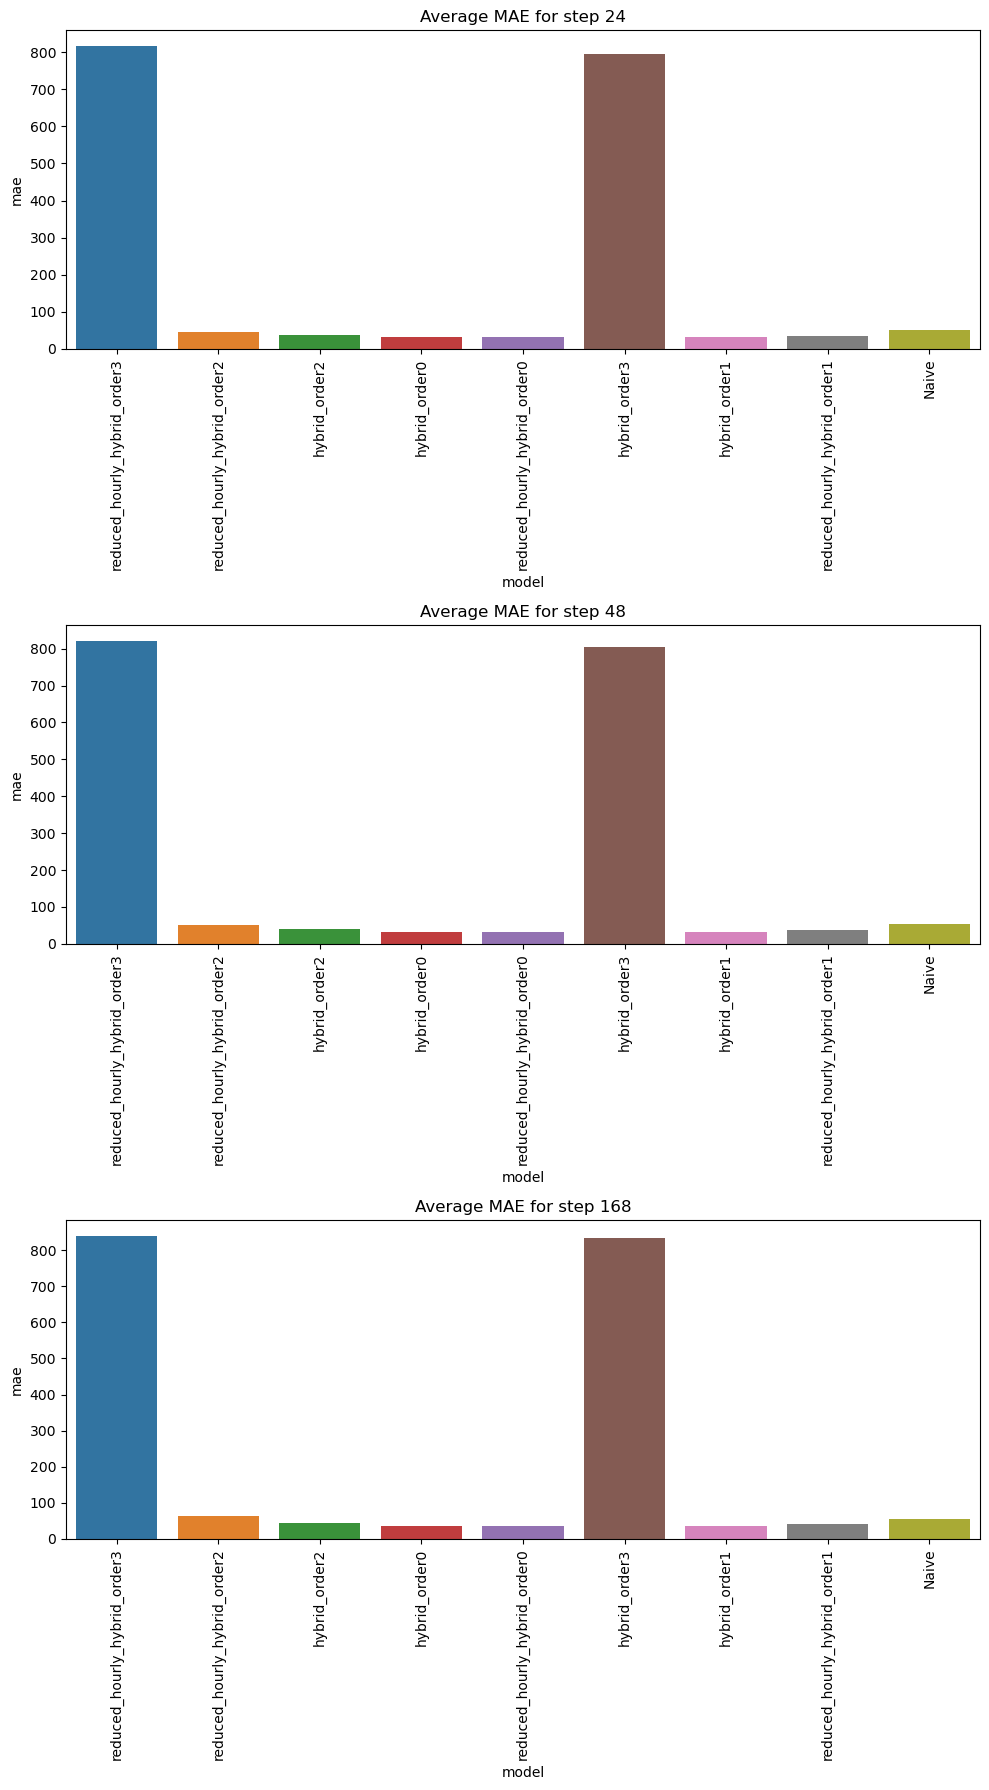

In [53]:
# Run forecasts
run_forecasts(steps, offset_list, offset_to_show, linear_models_loaded, non_linear_models_loaded, naive, time_step, ts_train, ts_test)



To finish off we look at the hourly hybrid models.

For the 24 hour forecast the lowest average MAE among the reduced models is reduced_hybrid_order0 at 31.17. Whereas among the original models it is hybrid_order0 at 31.66. So this is a 1.5% improvement by average MAE. 

For the 48 hour forecast the lowest average MAE among the reduced models is reduced_hybrid_order0 at 33.22. Whereas among the original models it is hybrid_order0 at 33.11. So this is 0.3% worse by average MAE.

For the 168 hour forecast the lowest average MAE among the reduced models is reduced_hourly_hybrid_order0 at 36.09. Whereas among the original models it is hybrid_order0 at 34.73. So this is 3.9% worse by average MAE.

So we that in the hybrid case the reduced models are either ever so slightly better or slightly worse, with them being at most 3.9% worse. So again the original hourly feature set has at least 378 features not including trends/constants. Whereas the reduced hybrid hourly feature set has only 29 lags (plus trend but in order 0 models trend isn't a feature). So we are looking at a over 13 fold reduction in the number of features! Considering we have almost exactly the same model performance it is once again well worth using this reduced feature set to considerably improve fit and predict times for the xgboost component of the model!

# Conclusions SHAP analysis

The main conclusions from the above plots is that the for the non linear and hybrid models the reduced feature set models perform slightly worse or even better than their full feature counterparts. In the purely linear regression case for the daily series the reduced feature set models are notably worse. However in the hourly case the difference is not as a large, at least in percentage average MAE change. We see that in some cases the reduced feature set is over 13 fold smaller than the full feautre set. Which will result in large reductions in the fit/predict times particularly of the xgboost models. Which will make Bayesian hyperparamter tuning faster/more computationally plausible with the rescources we have. It is also much easier to interpret a model using only around 30-50 features than one using over 336.

So it would seem that the best course of action is to use the reduced feature sets for both the non linear and hybrid models and potentially keep the full feature sets for the linear regressions.

We are now going to perform Bayesian hyperparamter tuning for the xgboost models found in both the non linear model and hybrid models. To see if we can get any performance increases.

The question for hyperparamter tuning would be what order of model to use, from our current experimentation it seems the choice is primarily between order 0 and order 2. In the hourly case order 0 performed the best on all three forecast steps, 24, 48 and 168 hours. For the daily case it seems order 0 performed better on the reduced features set in all three forecasts as well. With that in mind it seems using order 0 is the better choice for both the daily and hourly hybrid models.

# Bayesian hyperparamter tuning

We are now going to perform Bayesian hyperparamter tuning on the following models using Optuna: daily base_non_linear, reduced_daily_order0, hourly base_non_linear, reduced_hourly_order0. 

There are a few interesting things we would like to vary when doing our Bayesian hyperparamter optimisation. The first is that we want to both include and exclude COVID from the data we use to tune hyperparamters on.

The reason for this is because during COVID the usual seasonality breaks down dramatically as we get unusal travel patterns. So it may be worth tuning a model on data without COVID as then it is being asseseed more on its ability to pick up the more "normal" patterns within the data. You then have a question of do you use pre or post COVID data. There is more pre COVID data but it will obviously be less relevant for forecasting in the present. Alternatively it may actually be worth including the COVID data as then the model is tuned to be more robust to "unusal" regimines within the data. In the end we decide to try both pre COVID data and then including COVID data (so just the full dataset). The reason we don't do just post COVID data is there physically isn't enough data to create our design matricies properly (due to having yearly lags) when we create the folds to test on inside the hyperparamter objective function.

For the daily series we wil use a 30 day forecast in our objective function to validate with. For the hourly series we will do a weekly forecast (168 hours). These are sort of the forecasts we would like to optimise for from now on. 

The way the hyperparameter tuning will work is roughly as follows:

We take the designated training data and create n_splits (usually 5) folds, where each fold is an increasing partition of the data into a training and validation set. We then train the model on the training sets for each fold, and run our usual multiple offset forecast across the validation set. We compute an average MAE across the offsets for this fold, and then compute an average MAE across all n_splits (5) folds. So essentially an average average MAE. This is what the objective function will return and what Optuna will attempt to optimise for by choosing the hyperparamters for the xgboost components of the models.  

We will use config["hyperparameter_tuning"]["max_evals"] (1000 or 100) trials for Optuna and then return the best hyperparameters. 

The code below will set everything up and then run the Optuna study. However if you look in the README there are instructions for how to do this in an AWS EC2 instance if it is too slow in your docker container. I personally ran this using AWS due to the ability to run with more computational rescourses than on my host machine. Once you have done the hyperparamter tuning and if done through AWS moved the relevant .pkl objects to data/saved_objects, you can then scroll down to a markdown cell with the title "Checking the hyperparamter tuning" to essentially run the same forecasting regime from 4_modelling to see whether the hyperparamter tuning has made any improvement to the models!

In [54]:
# We are going to need to create offsets for the test sets the same way we did in the modelling section
# Max time we can go up to in the test set to ensure we can still forecast
total_daily_time = config["hyperparameter_tuning"]["daily_test_size"] - config["hyperparameter_tuning"]["daily_steps"]

daily_offsets = make_offsets(total_daily_time, config["modelling"]["daily_offset_size"])

config["hyperparameter_tuning"]["daily_offset"] = daily_offsets

total_hourly_time = config["hyperparameter_tuning"]["hourly_test_size"] - config["hyperparameter_tuning"]["hourly_steps"]

hourly_offsets = make_offsets(total_hourly_time, config["modelling"]["hourly_offset_size"])

config["hyperparameter_tuning"]["hourly_offset"] = hourly_offsets

config, PROJECT_ROOT = save_config(config)

In [55]:
# Dictionary of parameters for Baysian optimisation
bayes_dict = {}

In [56]:
# Daily non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_lags"]
constant = False
order = 0
fourier_features = config["shap"][DAILY_NON_LINEAR_NAME]["extracted_fourier_features"]
time_step = "D"
hybrid = None
steps = config["hyperparameter_tuning"]["daily_steps"]
offset_list = config["hyperparameter_tuning"]["daily_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_non_linear_incl_COVID": ts_daily_train,
    #"daily_non_linear_post_COVID": ts_daily_train["2022-01-01":] # We can't include post COVID as there is too little data to generate yearly lags
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }

In [57]:
# Daily hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["daily_test_size"]
lags = config["shap"][DAILY_HYBRID_NAME]["extracted_lags"]
constant = True
order = config["shap"]["daily_hybrid_order"] # As outlined above we use order 0
fourier_features = config["shap"][DAILY_HYBRID_NAME]["extracted_fourier_features"]
time_step = "D"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["daily_steps"]
offset_list = config["hyperparameter_tuning"]["daily_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_hybrid_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_hybrid_non_linear_incl_COVID": ts_daily_train,
    #"daily_hybrid_non_linear_post_COVID": ts_daily_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }

In [58]:
# Hourly non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_lags"]
constant = False
order = 0
fourier_features = config["shap"][HOURLY_NON_LINEAR_NAME]["extracted_fourier_features"]
time_step = "h"
hybrid = None
steps = config["hyperparameter_tuning"]["hourly_steps"]
offset_list = config["hyperparameter_tuning"]["hourly_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_non_linear_incl_COVID": ts_hourly_train,
    #"hourly_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }


In [59]:
# Hourly hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = config["hyperparameter_tuning"]["n_splits"]
test_size = config["hyperparameter_tuning"]["hourly_test_size"]
lags = config["shap"][HOURLY_HYBRID_NAME]["extracted_lags"]
constant = True
order = config["shap"]["hourly_hybrid_order"] # As outlined above we use order 0
fourier_features = config["shap"][HOURLY_HYBRID_NAME]["extracted_fourier_features"]
time_step = "h"
hybrid = LinearRegression(fit_intercept= False)
steps = config["hyperparameter_tuning"]["hourly_steps"]
offset_list = config["hyperparameter_tuning"]["hourly_offset"]


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_hybrid_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_hybrid_non_linear_incl_COVID": ts_hourly_train,
    #"hourly_hybrid_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps,
        "offset_list" : offset_list
    }


In [60]:
# Loop through the Bayes dict, create the folds and run fmin for 100 evals to optimise hyperparamters, save the hyperparameters and sigs to a .pkl object

# list to store the keys
sig_list = []

for key, value in bayes_dict.items():
    print(f"Running hyperparameter optimisation for {key}")
    
    # Create the folds
    fold_dict = create_val_data(value["n_splits"], value["test_size"], value["lags"], value["constant"], value["order"], value["fourier_features"], value["time_step"], value["ts"])

    # Set parameters of objective
    steps = value["steps"]
    hybrid = value["hybrid"]
    offset_list = value["offset_list"]

    # Create a new study
    study = optuna.create_study(direction = "minimize", study_name = f"hyper_parameter_optimisation_for_{key}")
    study.optimize(partial(objective_optuna, fold_dict = fold_dict, steps = steps, hybrid = hybrid, offset_list = offset_list), n_trials = config["hyperparameter_tuning"]["max_evals"])

    print("Number of finisehed trials: ", len(study.trials))
    print("Best trial: ", study.best_trial.params)

    print(f" Value: {study.best_trial.value}")
    print(" Params: ")
    for key2, value2 in study.best_trial.params.items():
        print(f"    {key2}: {value2}")
    
    # Get best hyperparams and add the missing ones
    best_hyperparams = study.best_trial.params

    best_hyperparams["early_stopping_rounds"] = config["xgboost_default"]["early_stopping_rounds"]
    best_hyperparams["n_estimators"] = config["xgboost_default"]["n_estimators"]
    best_hyperparams["random_state"] = config["xgboost_setup"]["random_state"]
    best_hyperparams["eval_metric"] = config["xgboost_setup"]["eval_metric"]
    best_hyperparams["tree_method"] = config["xgboost_setup"]["tree_method"]
    best_hyperparams["device"] = config["xgboost_setup"]["device"]

    # Save hyperparams
    save_hyperparams(best_hyperparams, key)

    # Append the sig to the list
    sig_list.append(key)

        

    
    # # Log hyperparams 
    # print("The best hyperparamters are: ", "\n")
    # print(best_hyperparams)

    # # Before we save the hyperparams we need to change the type of max_alpha to int 
    # # as well as add some of the parameters that aren't in best_hyperparmas, n_estimators, learnining_rate, random_state, eval_metric, tree_method and device
    # # At the same time we may as well convert the remaining hyperparams to floats rather than np.float64 
    # for key2, value2 in best_hyperparams.items():
    #     if key2 != "max_depth":
    #         best_hyperparams[key2] = float(value2)
    #     else:
    #         best_hyperparams[key2] = int(value2)

    # best_hyperparams["n_estimators"] = space["n_estimators"]
    # best_hyperparams["learning_rate"] = space["learning_rate"]
    # best_hyperparams["random_state"] = space["random_state"]
    # best_hyperparams["eval_metric"] = space["eval_metric"]
    # best_hyperparams["tree_method"] = space["tree_method"]
    # best_hyperparams["device"] = space["device"]

    # # Save hyperparams
    # save_hyperparams(best_hyperparams, key)

    # # Append the sig to the list
    # sig_list.append(key)

# Save signatures
save_obj(sig_list, "hyperparam_sigs")

[I 2025-10-13 15:22:35,635] A new study created in memory with name: hyper_parameter_optimisation_for_daily_non_linear_pre_COVID


Running hyperparameter optimisation for daily_non_linear_pre_COVID
[1051.96376953125, 771.6174967447917, 404.18146158854165, 722.4576009114584, 948.0215657552084, 1265.7278971354167, 788.0068033854167, 890.7740234375, 1012.8317708333333, 1189.09091796875, 1023.1931640625, 1040.8364583333334]
[1070.737548828125, 982.845751953125, 499.40065104166666, 725.1677083333333, 553.3075358072916, 699.300537109375, 622.6829752604167, 470.22177734375, 562.0081705729167, 544.7619954427083, 1115.1291178385416, 1312.7797037760417]
[1552.78681640625, 1253.5991536458334, 736.837158203125, 788.6359700520833, 525.2016764322917, 759.39111328125, 725.7344563802084, 537.3112955729167, 704.151220703125, 715.5795247395833, 1400.2808919270833, 1599.0213053385417]
[631.1475748697917, 947.8131022135417, 716.1607584635417, 467.09095052083336, 316.33728841145836, 623.4109049479167, 503.66541341145836, 447.77088216145836, 461.0935872395833, 445.27550455729164, 782.0721354166667, 1183.4834147135416]


[I 2025-10-13 15:22:51,176] Trial 0 finished with value: 919.9451280381945 and parameters: {'learning_rate': 0.08156070421854715, 'max_depth': 3, 'min_child_weight': 3.3234518217031597, 'subsample': 0.9066130969814794, 'colsample_bytree': 0.8315134803252773, 'reg_lambda': 37.344202606214395, 'reg_alpha': 0.2869258860058192, 'gamma': 0.13370176226586078}. Best is trial 0 with value: 919.9451280381945.


[594.6443359375, 599.9986490885417, 784.9733723958333, 1390.0563151041667, 1458.385205078125, 1770.0771647135416, 1828.1528483072916, 1553.7123697916666, 1450.941259765625, 1900.15400390625, 1618.938330078125, 1155.7753255208333]
[925.725244140625, 763.1952894422743, 941.5442152235241, 627.1101264105903, 1342.1507649739583]
[1115.826220703125, 816.8703776041667, 465.6000162760417, 731.0588053385417, 965.5165201822916, 1247.4509114583334, 874.7109212239583, 1036.0983561197916, 1047.9492838541667, 1182.474072265625, 1055.5246419270834, 872.8228352864584]
[1248.6479654947916, 1020.3824381510417, 495.06360677083336, 923.8298014322917, 632.7988118489583, 757.37578125, 714.1553059895833, 536.5888020833333, 652.52236328125, 576.5354166666667, 1117.5644856770834, 1198.5671712239584]
[1587.379052734375, 1279.29248046875, 717.4750651041667, 918.698779296875, 538.5558919270833, 824.4841959635417, 756.0117024739583, 593.4483561197917, 757.6883951822916, 846.735595703125, 1428.970751953125, 1639.35

[I 2025-10-13 15:23:04,142] Trial 1 finished with value: 958.8829690212675 and parameters: {'learning_rate': 0.06621645457424641, 'max_depth': 4, 'min_child_weight': 0.11847810482896484, 'subsample': 0.7595695219325882, 'colsample_bytree': 0.9678121691256949, 'reg_lambda': 0.7840959982768007, 'reg_alpha': 0.5092254080764783, 'gamma': 0.29239201622068395}. Best is trial 0 with value: 919.9451280381945.


...

[154.31277632603658, 98.92051555958957, 49.49038591519392, 102.71343383385461, 113.42493403943293, 96.11560965212357, 185.55246083450163, 98.88471257424887, 205.9100597053279, 210.77117552884835, 125.9336879976205, 226.01244805107922]
[170.02553054061377, 219.31583818750508, 86.41235589963173, 126.96689502892553, 139.0035166681548]
[169.7526315653976, 103.5741889594751, 65.25743090052667, 129.35345543270802, 146.39215982975193, 123.38991390813092, 236.471881775005, 142.67420052905345, 248.58537891869284, 251.40771166654253, 165.8018269308082, 251.81959860509292]
[173.60277744174053, 99.63217615780364, 74.45727746070807, 269.10256006581625, 268.82875054200673, 266.5906553039115, 253.96342041484985, 247.32328313487298, 245.326876887954, 248.47620379659307, 243.68561919994477, 242.31669992882797]
[64.76820233906017, 67.79048855679457, 56.86117440984859, 45.38078901990703, 44.17504636139705, 42.71782420318367, 95.35276822377048, 88.5326302368367, 117.58627586648353, 105.40342643219098, 109

[I 2025-10-13 15:56:54,012] Trial 3 finished with value: 147.53267905459 and parameters: {'learning_rate': 0.06926205211569707, 'max_depth': 6, 'min_child_weight': 1.5865818101162683, 'subsample': 0.8750165044162093, 'colsample_bytree': 0.6516294026955934, 'reg_lambda': 90.71263357490483, 'reg_alpha': 0.08059487539129495, 'gamma': 0.0013263843674037935}. Best is trial 3 with value: 147.53267905459.


[154.70712874834348, 100.42905603413556, 50.310266483815774, 102.93713310543544, 112.68602777360022, 96.05691277439139, 186.74443070133603, 99.34870401848096, 207.21820904452943, 213.10195749023828, 126.58983924799928, 227.66970105229979]
[169.54003158509877, 219.44219169458574, 81.58995105355325, 127.27460706682854, 139.81661387288378]
[171.48597142589765, 105.87234801346578, 66.24627889372138, 128.3083803845582, 145.51694880484047, 126.53173789367723, 237.14619007178666, 144.89617198355668, 247.8743063801607, 248.74305531275854, 168.83840508757547, 249.52908917328162]
[172.83957084692318, 98.91338106544026, 74.21946833626903, 268.31058545127036, 268.03677592746084, 265.7986806893656, 253.11385538379432, 246.48394046340087, 244.55233729094414, 247.89905904911853, 242.83806666175198, 241.71372565538348]
[70.72828454065022, 63.877075488329304, 74.15901555733652, 106.65688543516669, 105.45353602666339, 134.4329046158254, 179.2001606101441, 188.6237362597846, 202.7715891815727, 181.527541

[I 2025-10-13 15:58:07,967] Trial 4 finished with value: 159.9734203356895 and parameters: {'learning_rate': 0.08378469929316855, 'max_depth': 3, 'min_child_weight': 0.6980311624341605, 'subsample': 0.7663399058324656, 'colsample_bytree': 0.6572710071146356, 'reg_lambda': 0.06747409272064767, 'reg_alpha': 0.3148530759119347, 'gamma': 0.013332561701850142}. Best is trial 3 with value: 147.53267905459.


[152.4511201854474, 101.81073607773745, 49.71268020841545, 101.9100862214087, 111.03209016501366, 97.13121863969829, 184.66505254847522, 100.00481311172163, 204.88074356560867, 211.93817798677074, 126.5937045278086, 224.85306087117831]
[170.0824069521067, 218.72662056842682, 145.31135939782385, 126.83142441764984, 138.91529034244036]
Number of finisehed trials:  5
Best trial:  {'learning_rate': 0.06926205211569707, 'max_depth': 6, 'min_child_weight': 1.5865818101162683, 'subsample': 0.8750165044162093, 'colsample_bytree': 0.6516294026955934, 'reg_lambda': 90.71263357490483, 'reg_alpha': 0.08059487539129495, 'gamma': 0.0013263843674037935}
 Value: 147.53267905459
 Params: 
    learning_rate: 0.06926205211569707
    max_depth: 6
    min_child_weight: 1.5865818101162683
    subsample: 0.8750165044162093
    colsample_bytree: 0.6516294026955934
    reg_lambda: 90.71263357490483
    reg_alpha: 0.08059487539129495
    gamma: 0.0013263843674037935


## Checking the hyperparamter tuning

In [61]:
# Load signatures
hyper_sig = load_obj("hyperparam_sigs")

# Dict of hyperparams
hyper_dict = {}

# Load the hyperparams for each model
for sig in hyper_sig:
    hyper_params = load_hyperparams(sig)
    hyper_dict[sig] = hyper_params


In [62]:
hyper_dict.keys()

dict_keys(['daily_non_linear_pre_COVID', 'daily_non_linear_incl_COVID', 'daily_hybrid_non_linear_pre_COVID', 'daily_hybrid_non_linear_incl_COVID', 'hourly_non_linear_pre_COVID', 'hourly_non_linear_incl_COVID', 'hourly_hybrid_non_linear_pre_COVID', 'hourly_hybrid_non_linear_incl_COVID'])

In [63]:
hyper_dict["daily_hybrid_non_linear_incl_COVID"]

{'learning_rate': 0.08162723321170201,
 'max_depth': 6,
 'min_child_weight': 2.936060036064694,
 'subsample': 0.7461588451669539,
 'colsample_bytree': 0.9131426437942314,
 'reg_lambda': 1.9280377357126879,
 'reg_alpha': 0.054507961928487704,
 'gamma': 4.39796069852805,
 'early_stopping_rounds': 50,
 'n_estimators': 2000,
 'random_state': 37,
 'eval_metric': 'mae',
 'tree_method': 'hist',
 'device': 'cuda'}

In [64]:
# The first interesting thing to compare would be how do the models tuned on pre, incl and post COVID compare to each other as well as to the previous best model from the modelling notebook
# to make this easier we will split up into four dicts, daily non-linear, daily hybrid, hourly non-linear, hourly hybrid

daily_non_linear_dict = {}
daily_hybrid_dict = {}
hourly_non_linear_dict = {}
hourly_hybrid_dict = {}

# Split into the four dicts
daily_non_linear_dict, daily_hybrid_dict, hourly_non_linear_dict, hourly_hybrid_dict = split_params(hyper_dict)


# Create dict of these dicts to pass to test_hyperparams
dict_full = {
    config["hyperparameter_tuning"]["daily_linear_key"]: daily_non_linear_dict, 
    config["hyperparameter_tuning"]["daily_hybrid_key"]: daily_hybrid_dict, 
    config["hyperparameter_tuning"]["hourly_linear_key"]: hourly_non_linear_dict, 
    config["hyperparameter_tuning"]["hourly_hybrid_key"]: hourly_hybrid_dict
    }

In [65]:
# Display hyperparams
print(dict_full)

{'daily': {'daily_non_linear_pre_COVID': {'learning_rate': 0.09917959364278457, 'max_depth': 6, 'min_child_weight': 4.125926764348955, 'subsample': 0.8176008563063122, 'colsample_bytree': 0.7574505253407086, 'reg_lambda': 31.234372241134157, 'reg_alpha': 0.012656119127367964, 'gamma': 4.581705871201569, 'early_stopping_rounds': 50, 'n_estimators': 2000, 'random_state': 37, 'eval_metric': 'mae', 'tree_method': 'hist', 'device': 'cuda'}, 'daily_non_linear_incl_COVID': {'learning_rate': 0.09132154759619476, 'max_depth': 4, 'min_child_weight': 2.949967857985468, 'subsample': 0.6083336905264598, 'colsample_bytree': 0.6981329409650935, 'reg_lambda': 1.2936854783092844, 'reg_alpha': 6.529263708946926, 'gamma': 0.3814655354083045, 'early_stopping_rounds': 50, 'n_estimators': 2000, 'random_state': 37, 'eval_metric': 'mae', 'tree_method': 'hist', 'device': 'cuda'}}, 'daily_hybrid': {'daily_hybrid_non_linear_pre_COVID': {'learning_rate': 0.0741896722658844, 'max_depth': 6, 'min_child_weight': 2.3

In [66]:
# We are now going to forecast all of the models inside these four categories (daily, daily_hybrid, hourly, hourly_hybrid)
# at first just within the categories compared to the best model from the modelling notebook
# So for daily that would be linear_order_2, but also the non linear base model and the naive base for comparison

In [67]:
# Set up parameters for test_hyperparams
ts_daily_train = ts_daily_train
ts_daily_test = ts_daily_test
ts_hourly_train = ts_hourly_train
ts_hourly_test = ts_hourly_test
daily_steps = config["modelling"]["daily_steps"]
hourly_steps = config["modelling"]["hourly_steps"]
daily_offsets = config["modelling"]["daily_offset"]
hourly_offsets = config["modelling"]["hourly_offset"]
daily_offsets_to_show = config["modelling"]["daily_offsets_to_show"]
hourly_offsets_to_show = config["modelling"]["hourly_offsets_to_show"]

MAE: 361.28 for step = 7, model = linear_order0
MAE: 489.62 for step = 7, model = reduced_daily_non_linear
MAE: 368.68 for step = 7, model = daily_non_linear_pre_COVID
MAE: 621.71 for step =  30, model = Naive



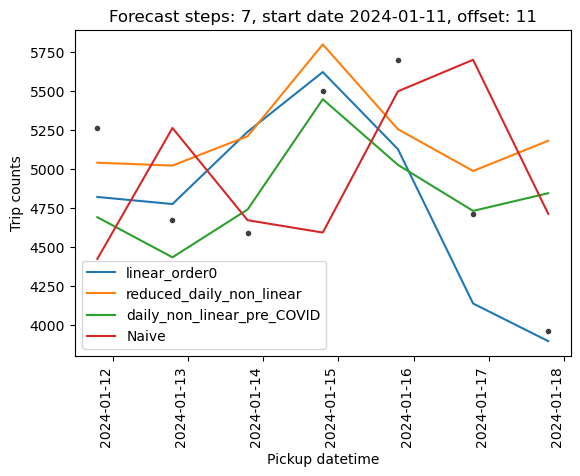

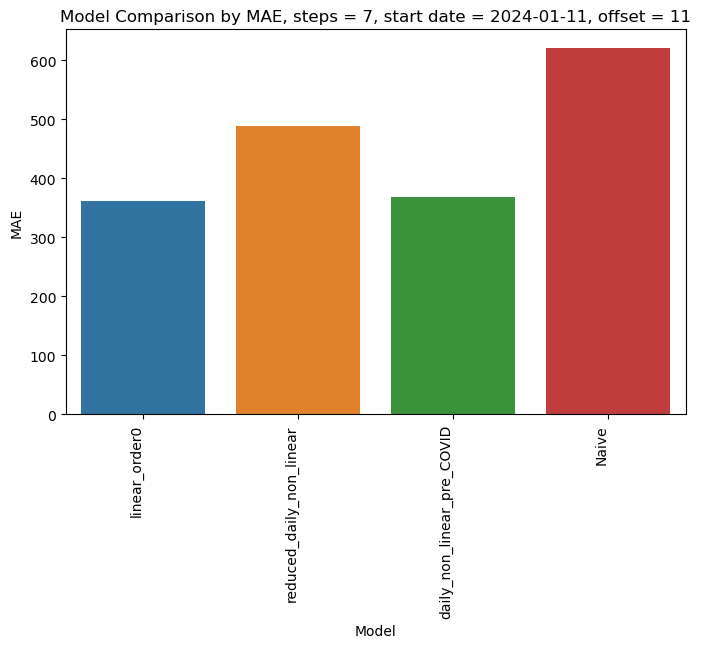

MAE: 294.52 for step = 30, model = linear_order0
MAE: 1026.87 for step = 30, model = reduced_daily_non_linear
MAE: 996.28 for step = 30, model = daily_non_linear_pre_COVID
MAE: 637.10 for step =  30, model = Naive



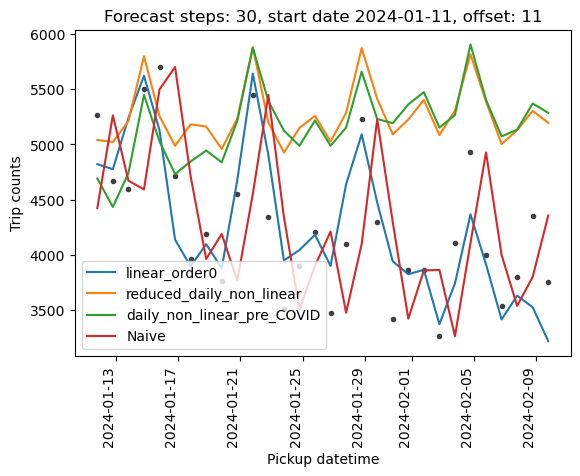

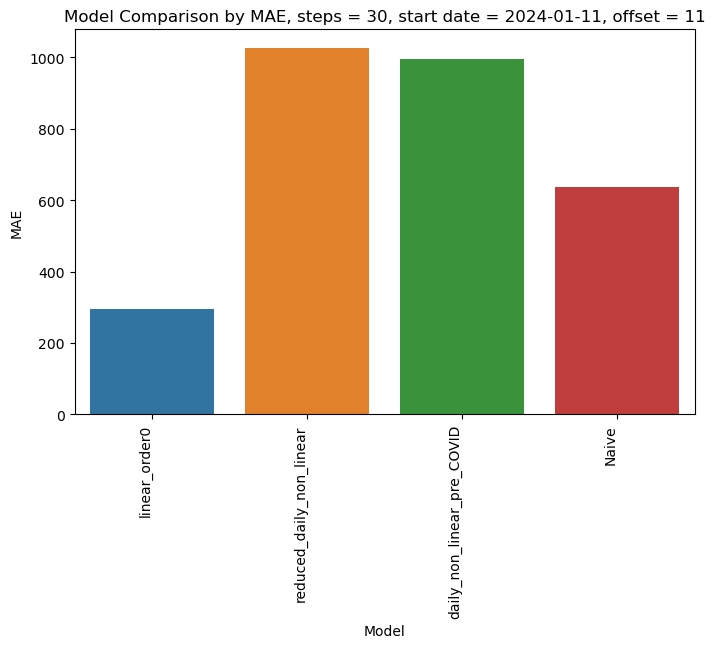

MAE: 329.40 for step = 60, model = linear_order0
MAE: 1010.01 for step = 60, model = reduced_daily_non_linear
MAE: 992.45 for step = 60, model = daily_non_linear_pre_COVID
MAE: 607.33 for step =  30, model = Naive



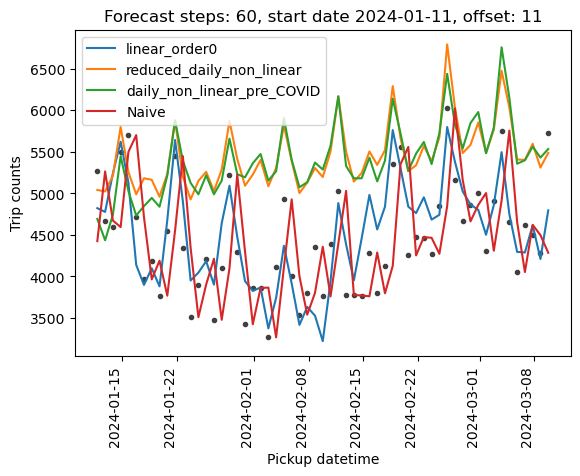

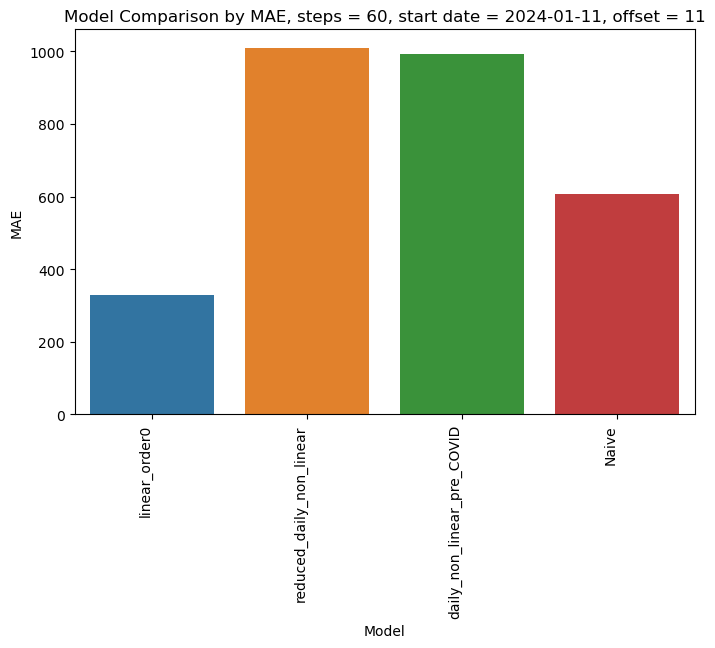


Average MAE scores for step 60:
reduced_daily_non_linear, average MAE: 560.42
linear_order0, average MAE: 471.01
daily_non_linear_pre_COVID, average MAE: 560.80
Naive, average MAE: 640.27

Average MAE scores for step 30:
reduced_daily_non_linear, average MAE: 546.03
linear_order0, average MAE: 418.62
daily_non_linear_pre_COVID, average MAE: 509.55
Naive, average MAE: 630.26

Average MAE scores for step 7:
reduced_daily_non_linear, average MAE: 463.33
linear_order0, average MAE: 421.41
daily_non_linear_pre_COVID, average MAE: 395.01
Naive, average MAE: 602.31


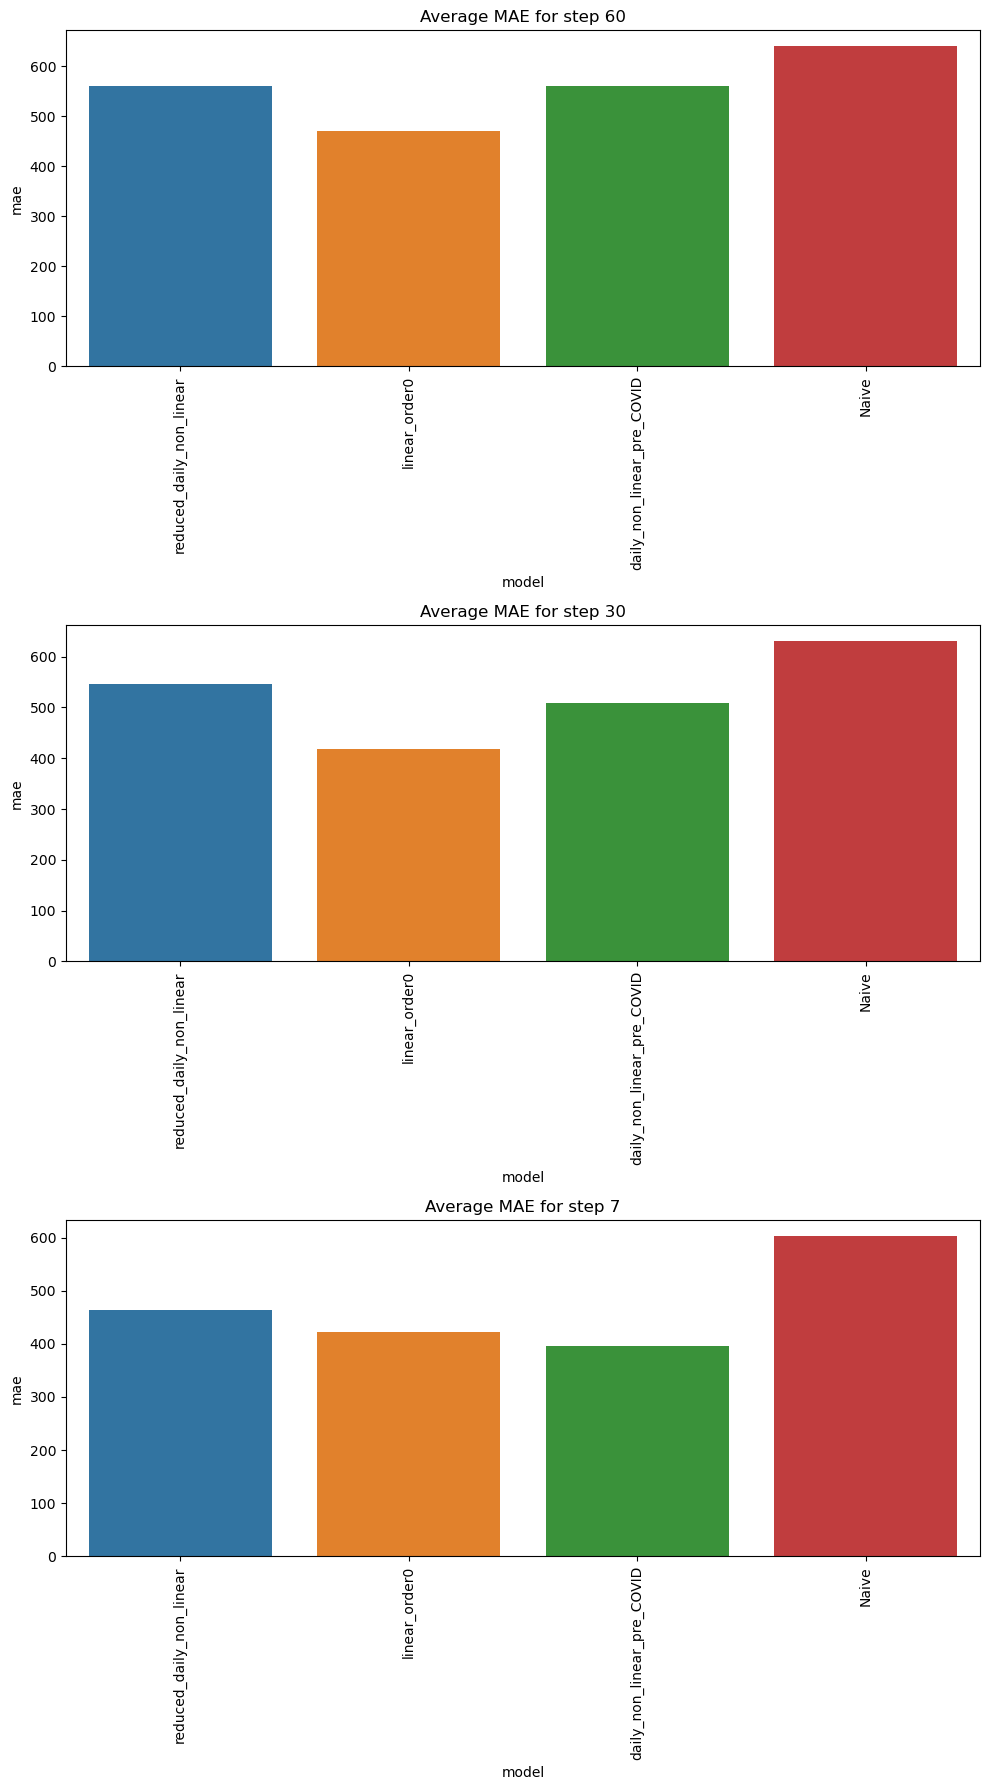

MAE: 361.28 for step = 7, model = linear_order0
MAE: 489.62 for step = 7, model = reduced_daily_non_linear
MAE: 454.98 for step = 7, model = daily_non_linear_incl_COVID
MAE: 621.71 for step =  30, model = Naive



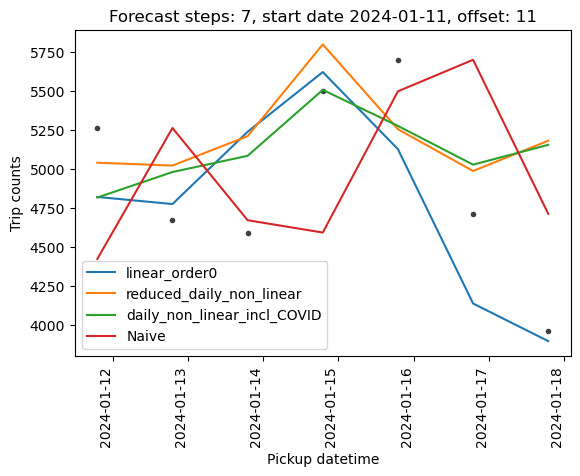

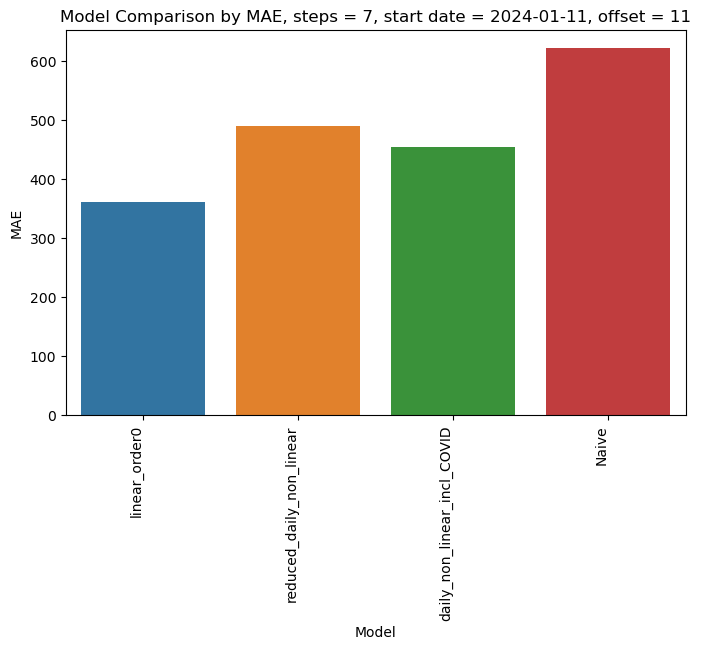

MAE: 294.52 for step = 30, model = linear_order0
MAE: 1026.87 for step = 30, model = reduced_daily_non_linear
MAE: 924.58 for step = 30, model = daily_non_linear_incl_COVID
MAE: 637.10 for step =  30, model = Naive



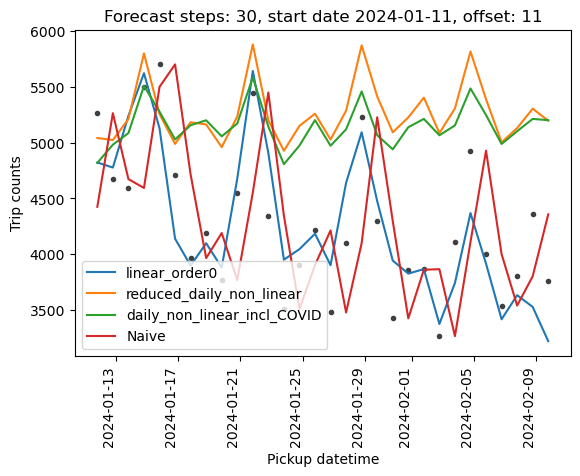

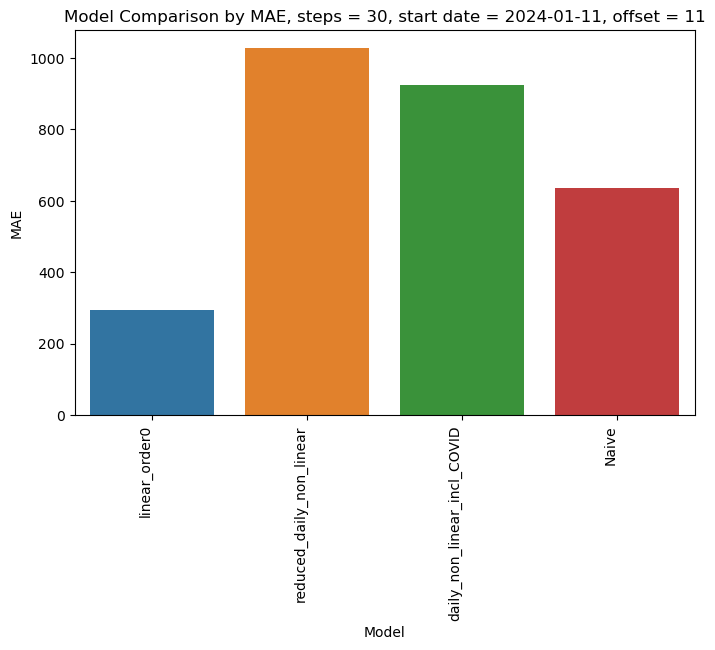

MAE: 329.40 for step = 60, model = linear_order0
MAE: 1010.01 for step = 60, model = reduced_daily_non_linear
MAE: 914.42 for step = 60, model = daily_non_linear_incl_COVID
MAE: 607.33 for step =  30, model = Naive



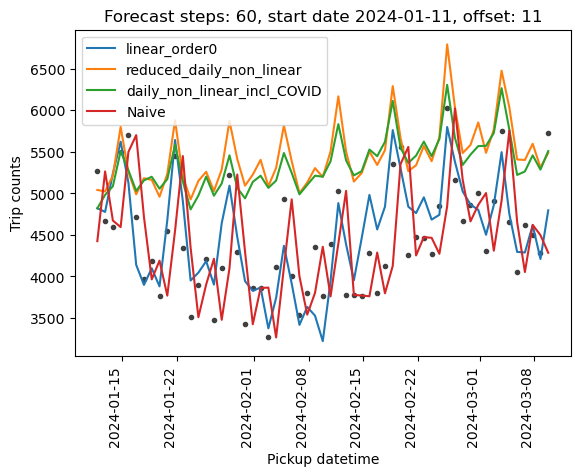

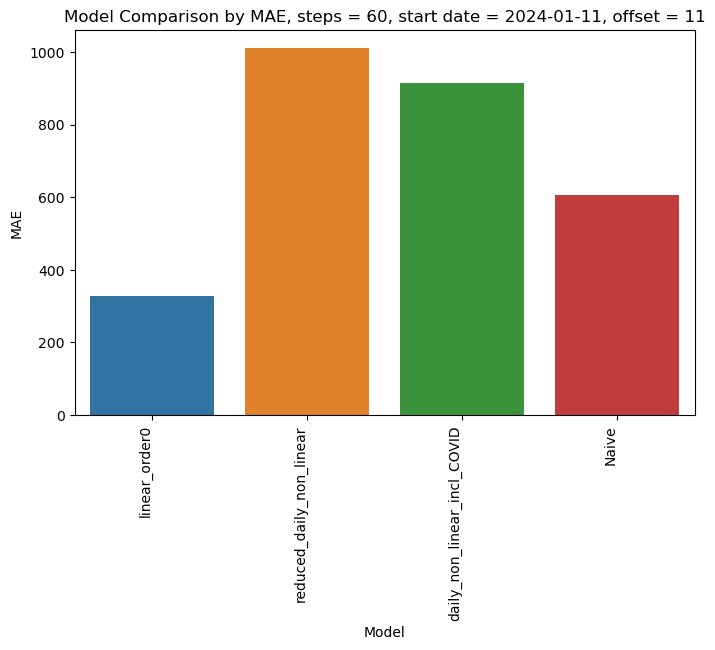


Average MAE scores for step 60:
daily_non_linear_incl_COVID, average MAE: 527.59
reduced_daily_non_linear, average MAE: 560.42
linear_order0, average MAE: 471.01
Naive, average MAE: 640.27

Average MAE scores for step 30:
daily_non_linear_incl_COVID, average MAE: 499.63
reduced_daily_non_linear, average MAE: 546.03
linear_order0, average MAE: 418.62
Naive, average MAE: 630.26

Average MAE scores for step 7:
daily_non_linear_incl_COVID, average MAE: 410.45
reduced_daily_non_linear, average MAE: 463.33
linear_order0, average MAE: 421.41
Naive, average MAE: 602.31


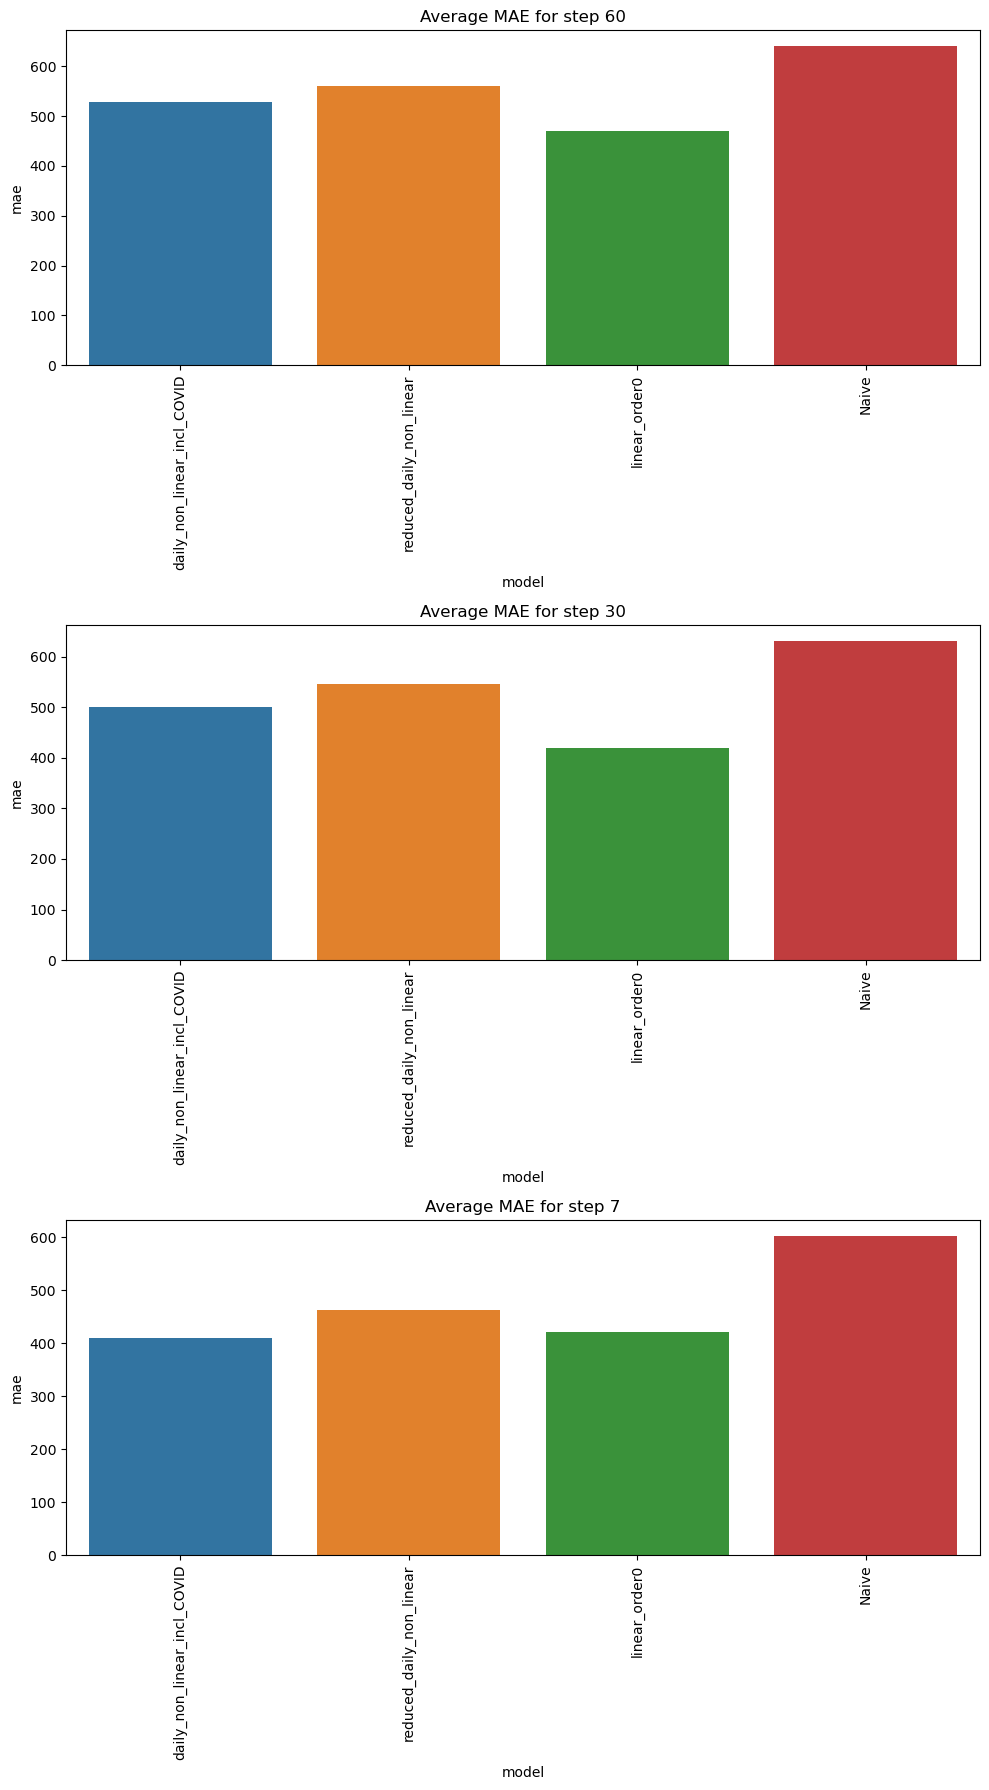

MAE: 455.24 for step = 7, model = daily_hybrid_non_linear_pre_COVID_order0
MAE: 449.24 for step = 7, model = reduced_daily_hybrid_order0
MAE: 621.71 for step =  30, model = Naive



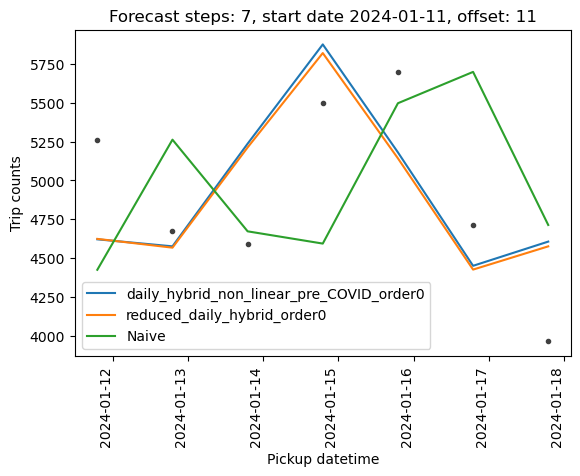

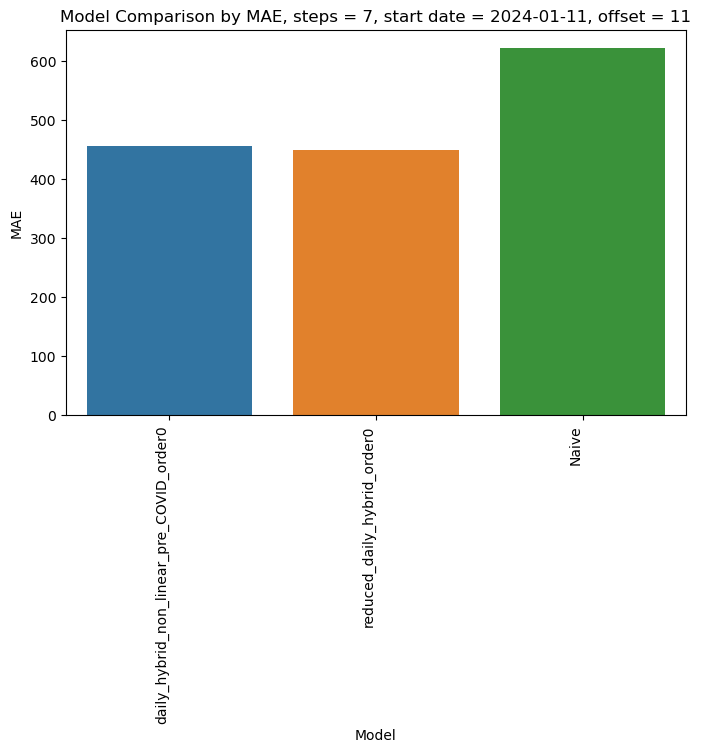

MAE: 350.56 for step = 30, model = daily_hybrid_non_linear_pre_COVID_order0
MAE: 301.09 for step = 30, model = reduced_daily_hybrid_order0
MAE: 637.10 for step =  30, model = Naive



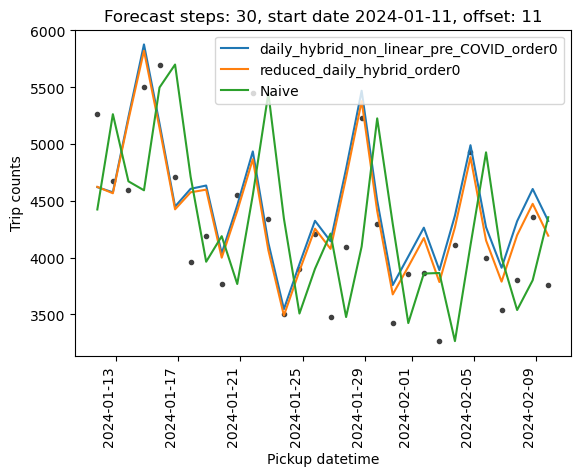

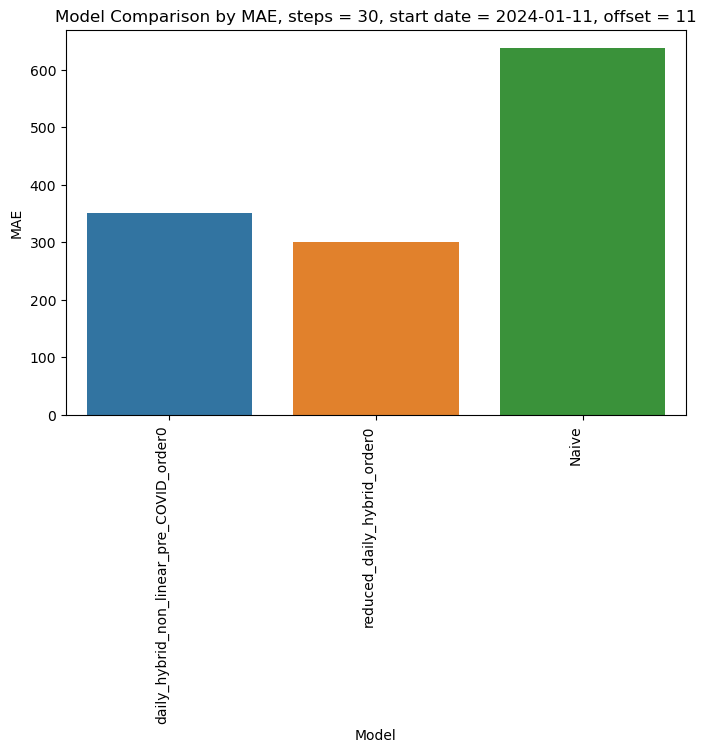

MAE: 448.10 for step = 60, model = daily_hybrid_non_linear_pre_COVID_order0
MAE: 373.72 for step = 60, model = reduced_daily_hybrid_order0
MAE: 607.33 for step =  30, model = Naive



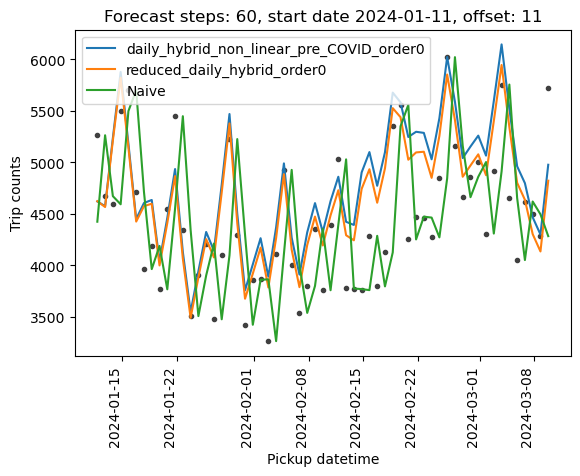

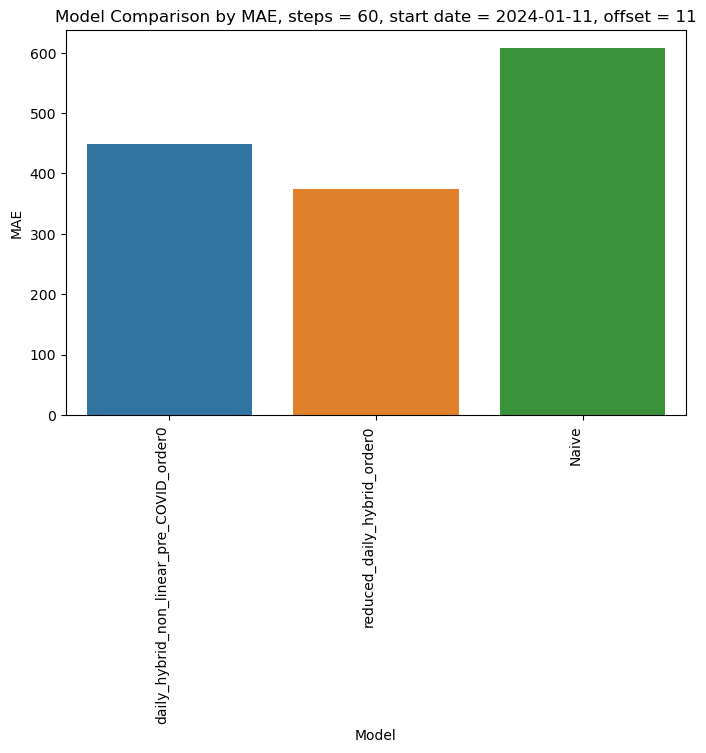


Average MAE scores for step 60:
reduced_daily_hybrid_order0, average MAE: 529.05
daily_hybrid_non_linear_pre_COVID_order0, average MAE: 557.43
Naive, average MAE: 640.27

Average MAE scores for step 30:
reduced_daily_hybrid_order0, average MAE: 466.76
daily_hybrid_non_linear_pre_COVID_order0, average MAE: 482.36
Naive, average MAE: 630.26

Average MAE scores for step 7:
reduced_daily_hybrid_order0, average MAE: 418.62
daily_hybrid_non_linear_pre_COVID_order0, average MAE: 430.18
Naive, average MAE: 602.31


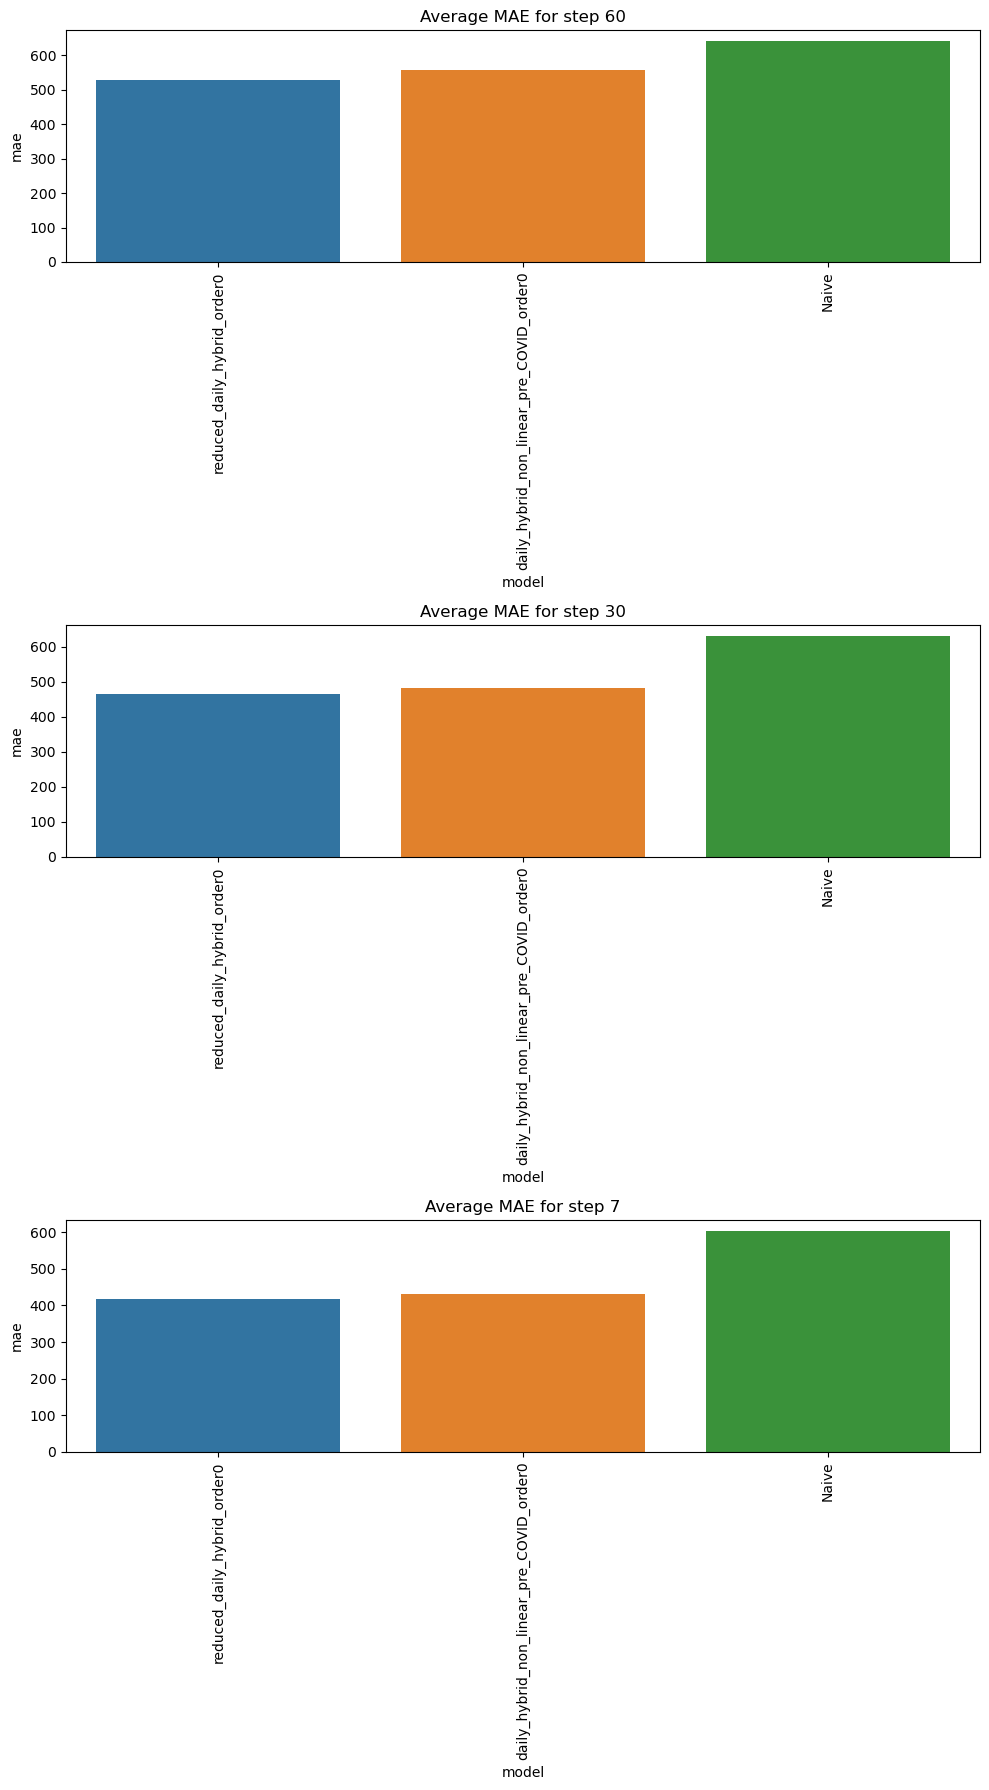

MAE: 430.62 for step = 7, model = daily_hybrid_non_linear_incl_COVID_order0
MAE: 449.24 for step = 7, model = reduced_daily_hybrid_order0
MAE: 621.71 for step =  30, model = Naive



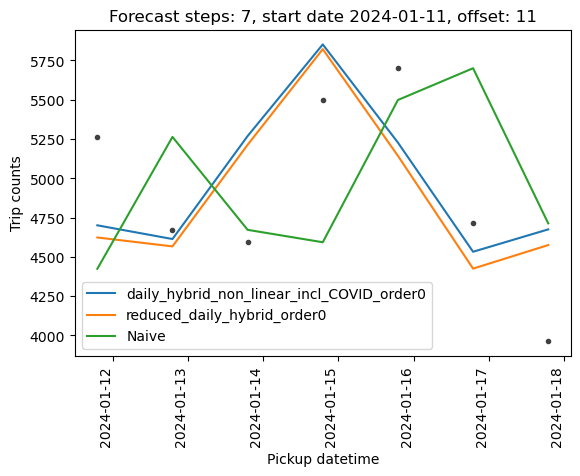

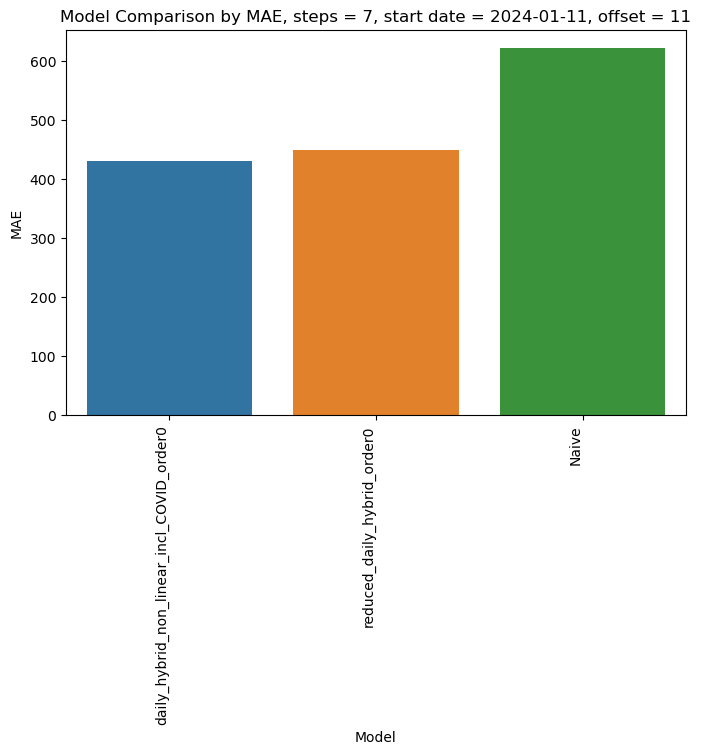

MAE: 494.70 for step = 30, model = daily_hybrid_non_linear_incl_COVID_order0
MAE: 301.09 for step = 30, model = reduced_daily_hybrid_order0
MAE: 637.10 for step =  30, model = Naive



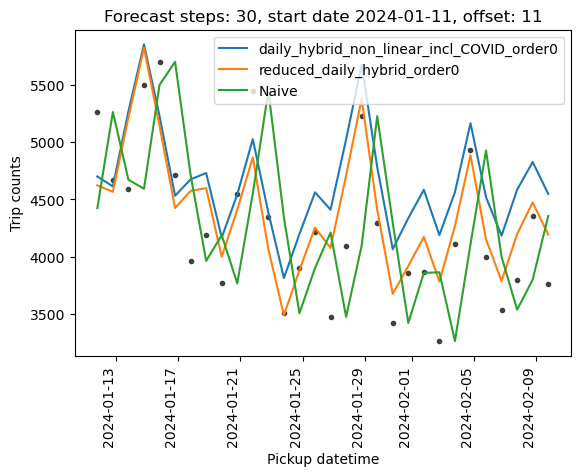

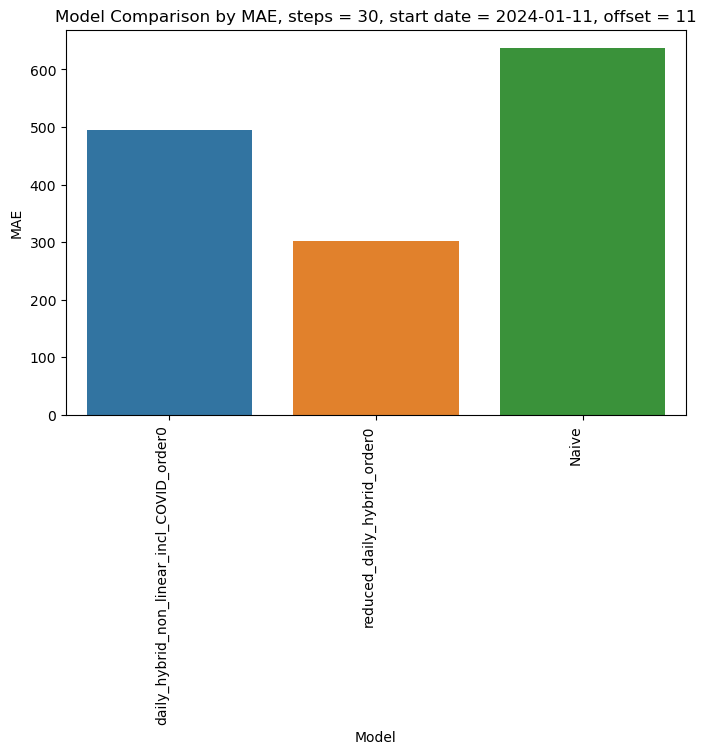

MAE: 675.46 for step = 60, model = daily_hybrid_non_linear_incl_COVID_order0
MAE: 373.72 for step = 60, model = reduced_daily_hybrid_order0
MAE: 607.33 for step =  30, model = Naive



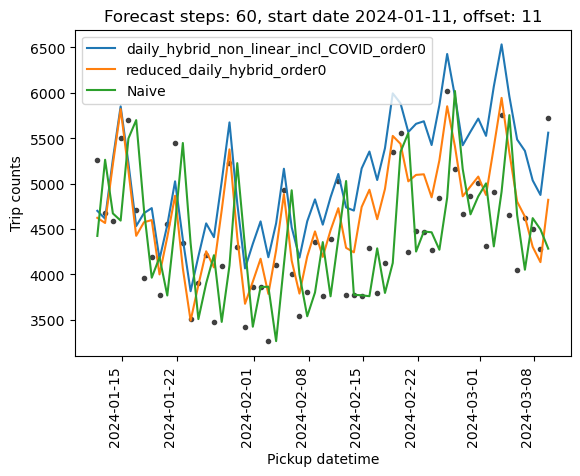

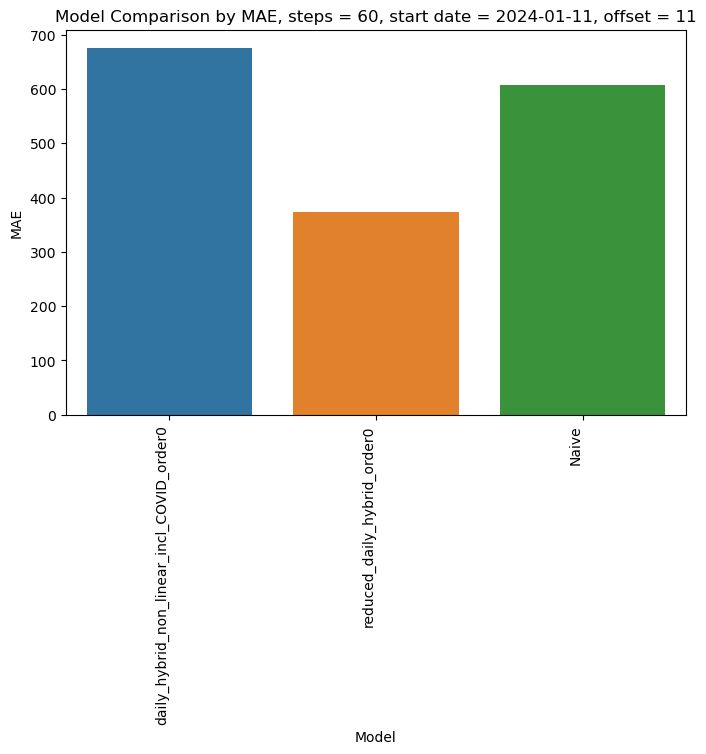


Average MAE scores for step 60:
daily_hybrid_non_linear_incl_COVID_order0, average MAE: 612.31
reduced_daily_hybrid_order0, average MAE: 529.05
Naive, average MAE: 640.27

Average MAE scores for step 30:
daily_hybrid_non_linear_incl_COVID_order0, average MAE: 523.78
reduced_daily_hybrid_order0, average MAE: 466.76
Naive, average MAE: 630.26

Average MAE scores for step 7:
daily_hybrid_non_linear_incl_COVID_order0, average MAE: 423.23
reduced_daily_hybrid_order0, average MAE: 418.62
Naive, average MAE: 602.31


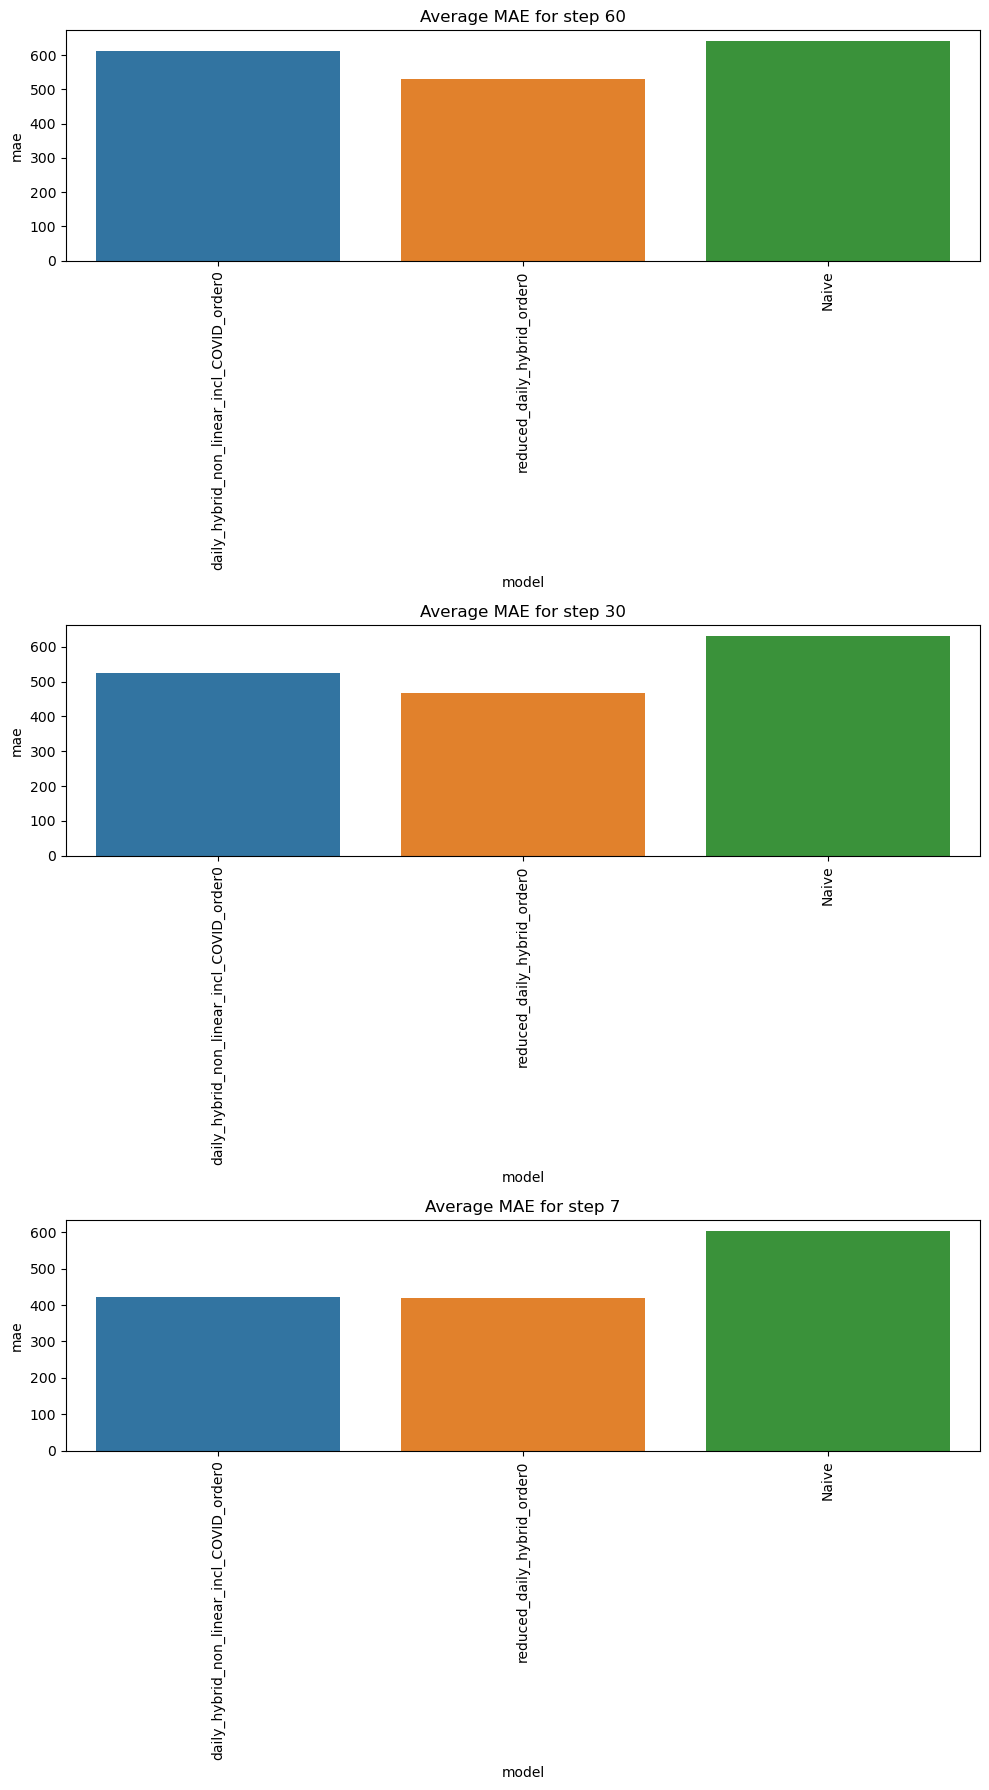

MAE: 26.62 for step = 24, model = linear_order0
MAE: 28.97 for step = 24, model = reduced_hourly_non_linear
MAE: 29.22 for step = 24, model = hourly_non_linear_pre_COVID
MAE: 47.88 for step =  30, model = Naive



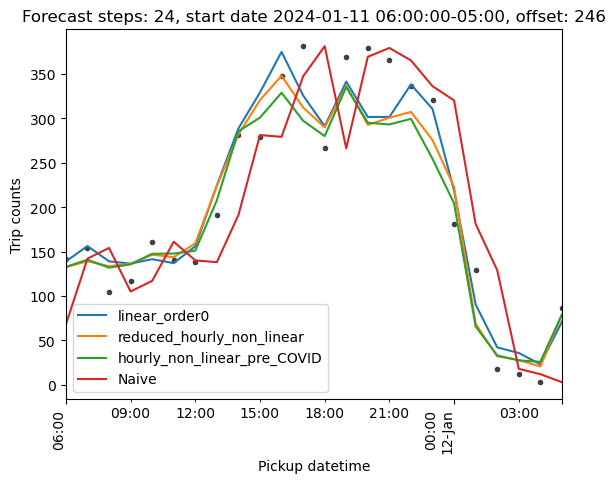

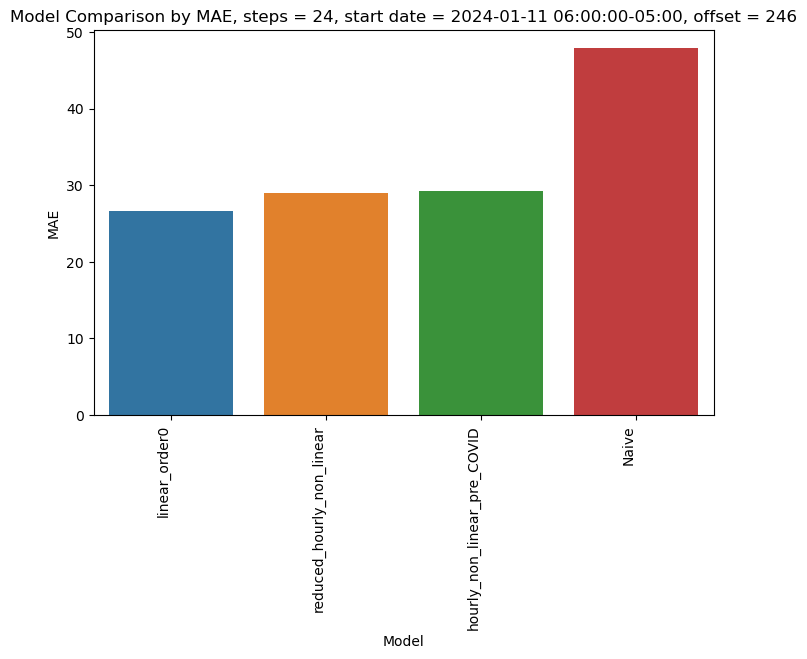

MAE: 23.91 for step = 48, model = linear_order0
MAE: 26.04 for step = 48, model = reduced_hourly_non_linear
MAE: 26.22 for step = 48, model = hourly_non_linear_pre_COVID
MAE: 46.19 for step =  30, model = Naive



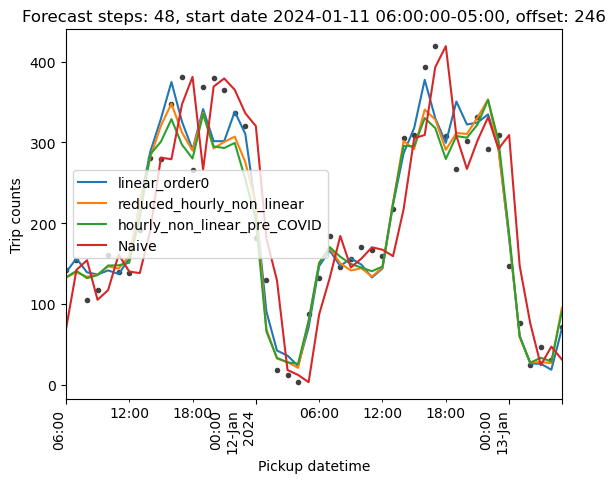

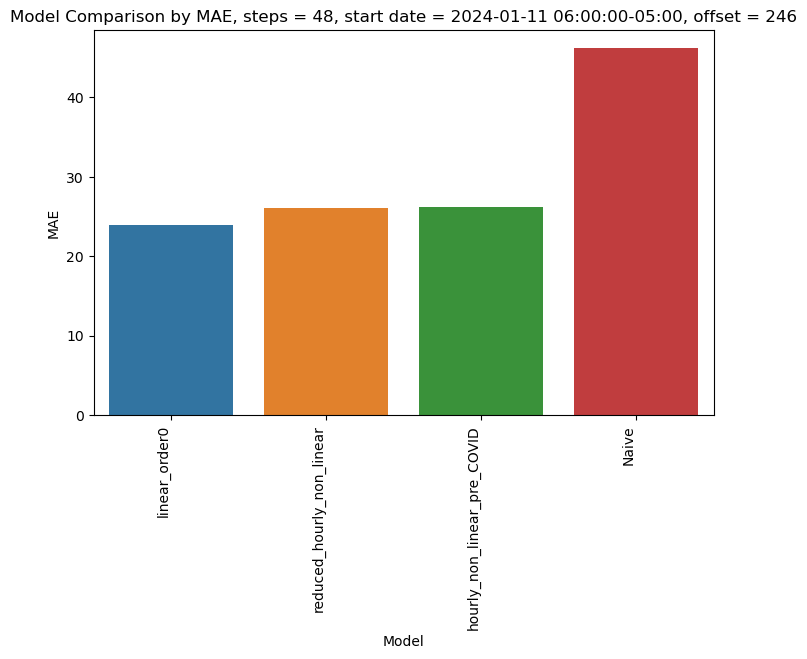

MAE: 31.84 for step = 168, model = linear_order0
MAE: 34.50 for step = 168, model = reduced_hourly_non_linear
MAE: 34.46 for step = 168, model = hourly_non_linear_pre_COVID
MAE: 52.86 for step =  30, model = Naive



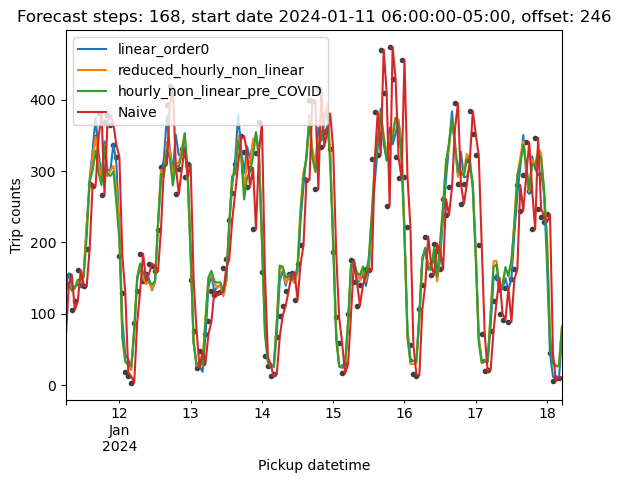

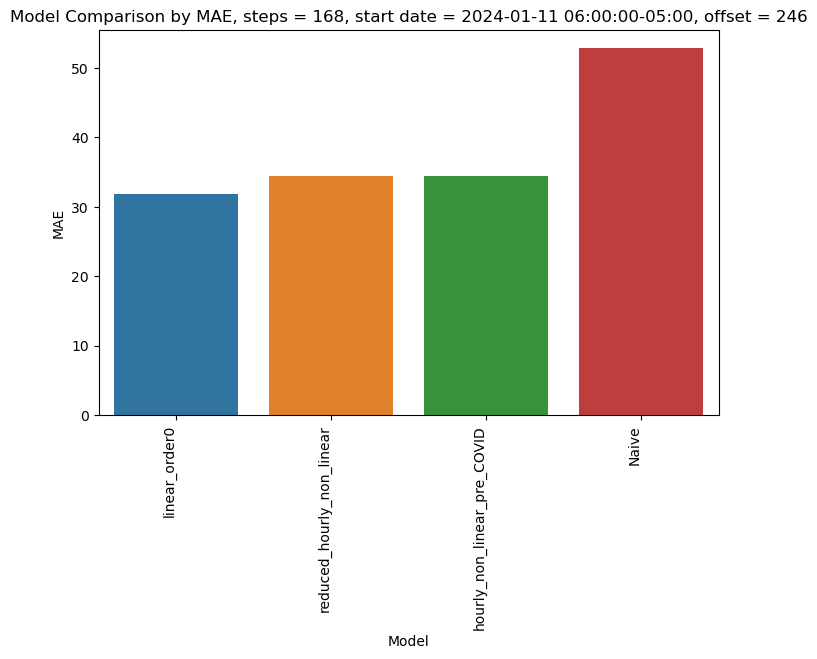


Average MAE scores for step 24:
reduced_hourly_non_linear, average MAE: 32.07
hourly_non_linear_pre_COVID, average MAE: 31.80
linear_order0, average MAE: 31.60
Naive, average MAE: 51.45

Average MAE scores for step 48:
reduced_hourly_non_linear, average MAE: 33.70
hourly_non_linear_pre_COVID, average MAE: 33.68
linear_order0, average MAE: 32.71
Naive, average MAE: 52.47

Average MAE scores for step 168:
reduced_hourly_non_linear, average MAE: 35.73
hourly_non_linear_pre_COVID, average MAE: 35.77
linear_order0, average MAE: 34.93
Naive, average MAE: 53.72


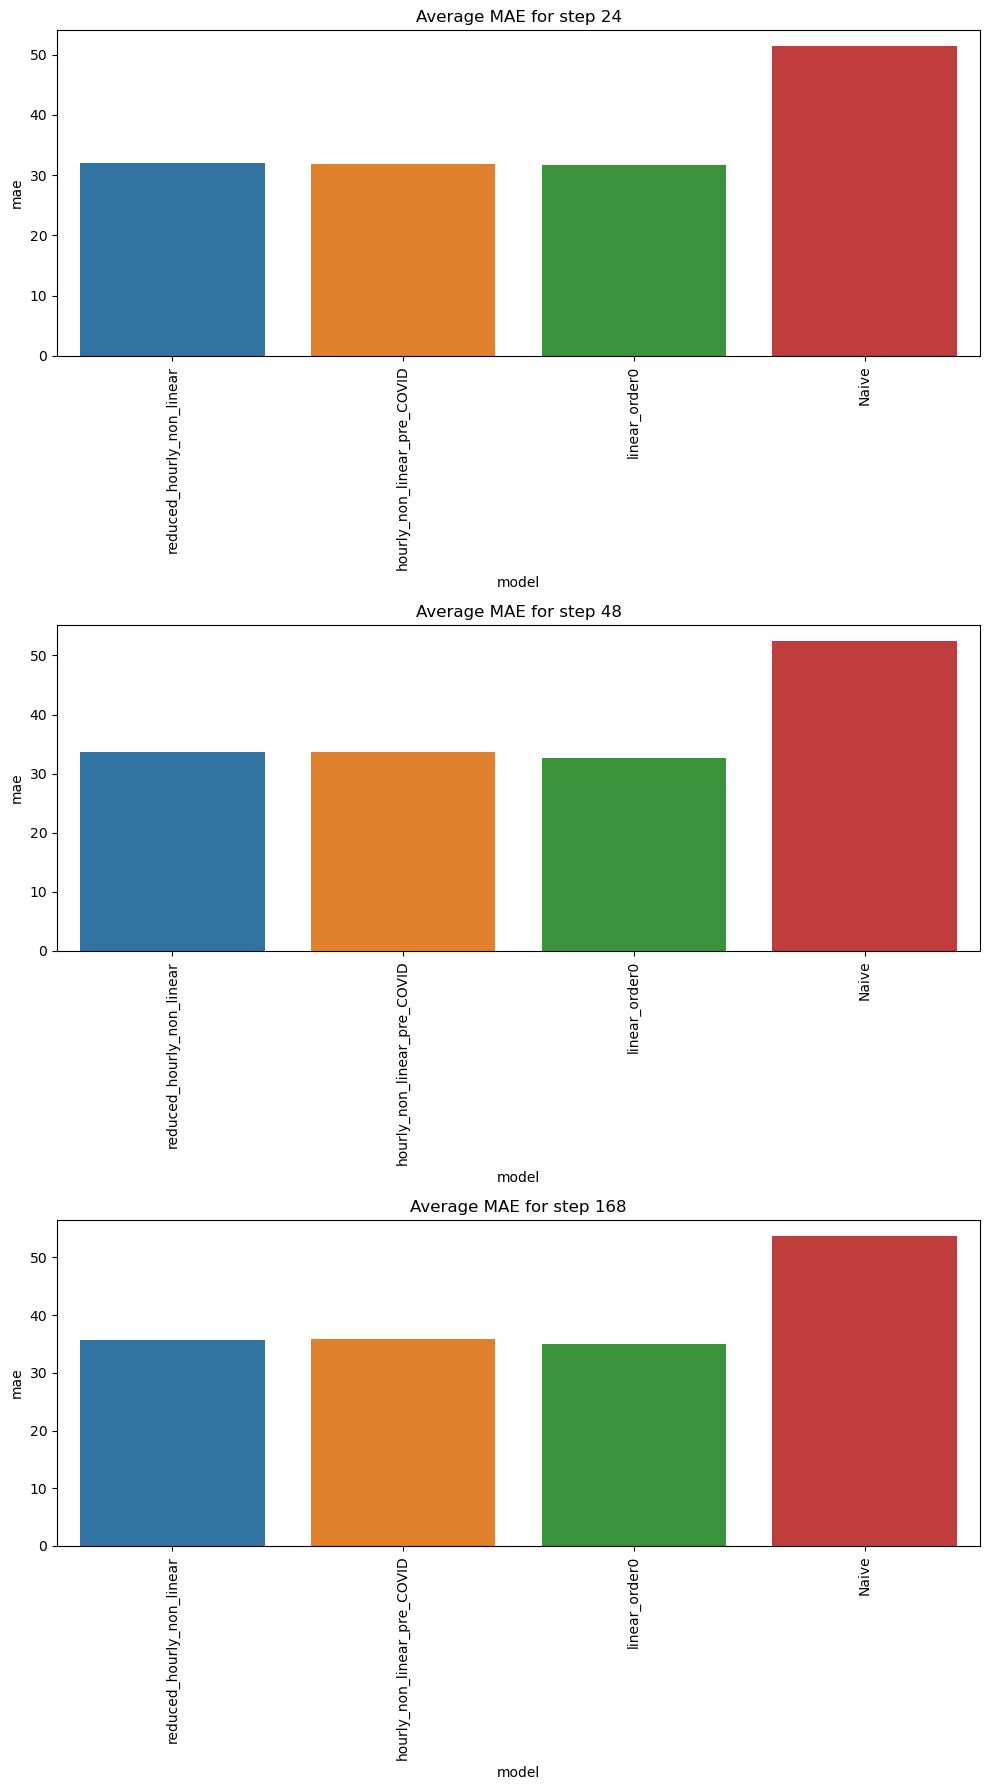

MAE: 26.62 for step = 24, model = linear_order0
MAE: 28.97 for step = 24, model = reduced_hourly_non_linear
MAE: 28.46 for step = 24, model = hourly_non_linear_incl_COVID
MAE: 47.88 for step =  30, model = Naive



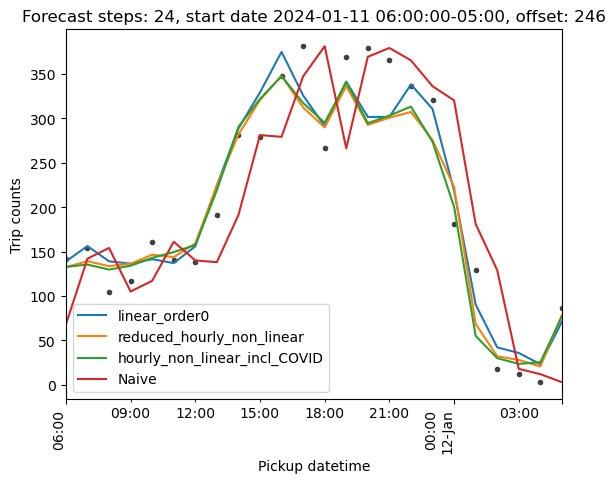

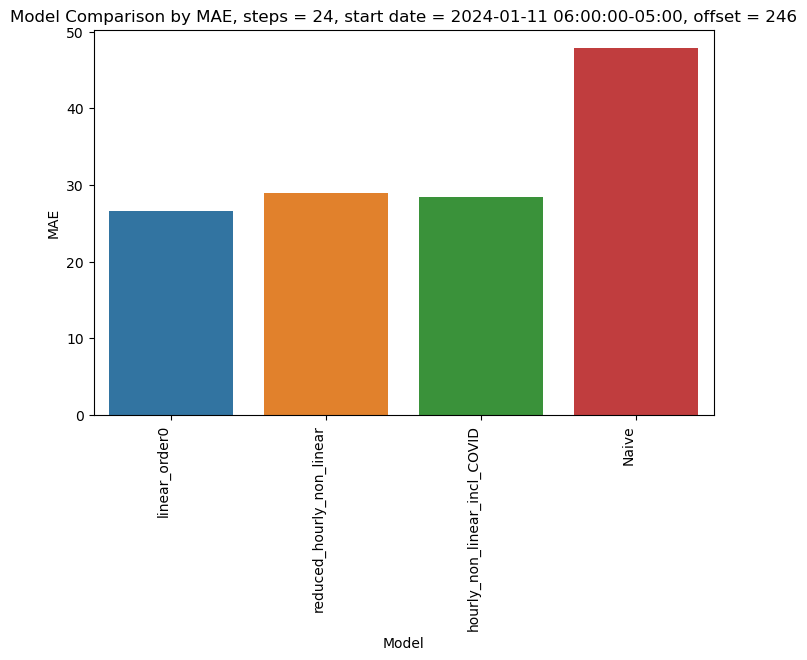

MAE: 23.91 for step = 48, model = linear_order0
MAE: 26.04 for step = 48, model = reduced_hourly_non_linear
MAE: 24.52 for step = 48, model = hourly_non_linear_incl_COVID
MAE: 46.19 for step =  30, model = Naive



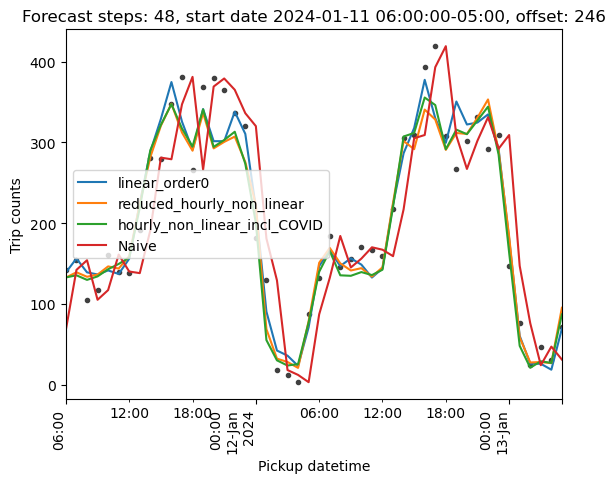

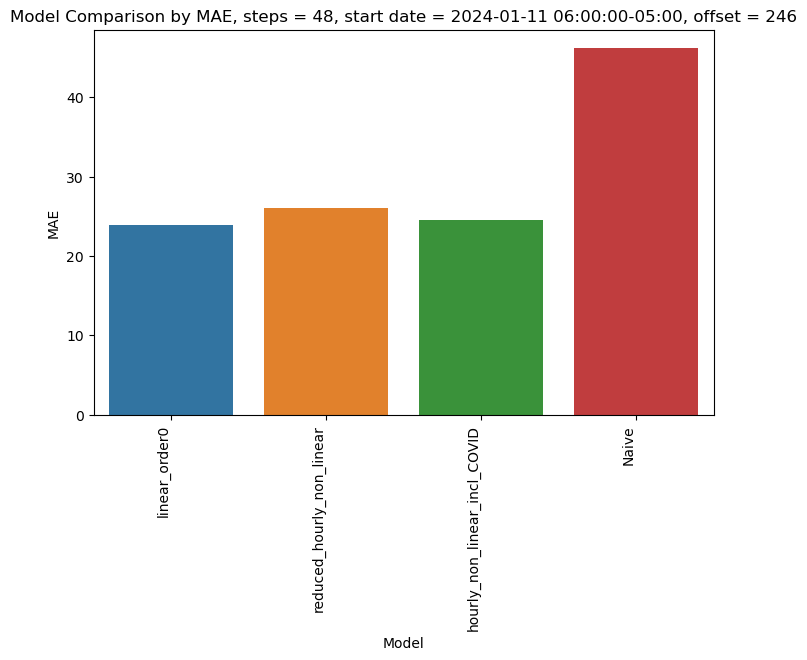

MAE: 31.84 for step = 168, model = linear_order0
MAE: 34.50 for step = 168, model = reduced_hourly_non_linear
MAE: 34.24 for step = 168, model = hourly_non_linear_incl_COVID
MAE: 52.86 for step =  30, model = Naive



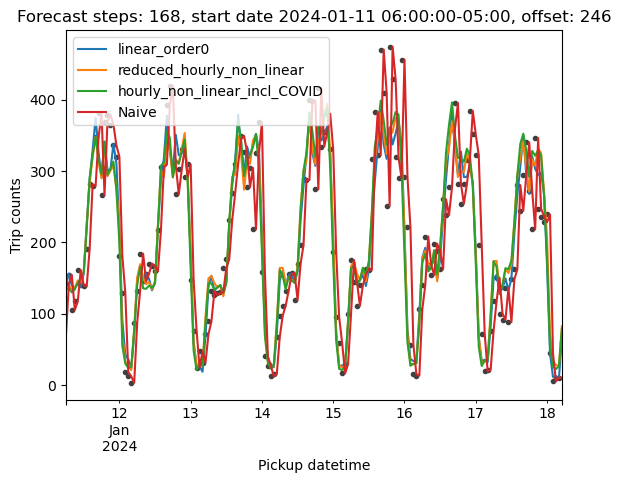

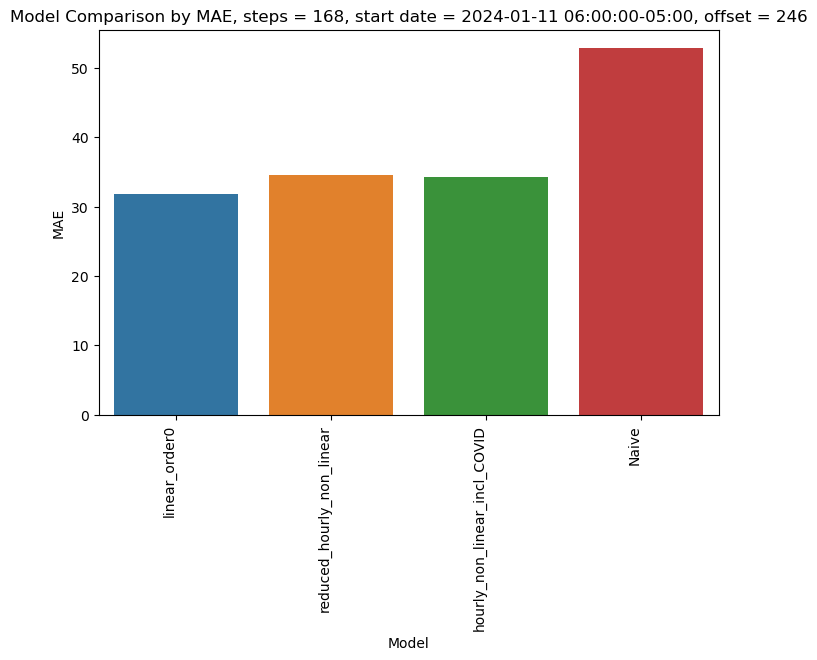


Average MAE scores for step 24:
hourly_non_linear_incl_COVID, average MAE: 32.20
reduced_hourly_non_linear, average MAE: 32.07
linear_order0, average MAE: 31.60
Naive, average MAE: 51.45

Average MAE scores for step 48:
hourly_non_linear_incl_COVID, average MAE: 33.87
reduced_hourly_non_linear, average MAE: 33.70
linear_order0, average MAE: 32.71
Naive, average MAE: 52.47

Average MAE scores for step 168:
hourly_non_linear_incl_COVID, average MAE: 35.52
reduced_hourly_non_linear, average MAE: 35.73
linear_order0, average MAE: 34.93
Naive, average MAE: 53.72


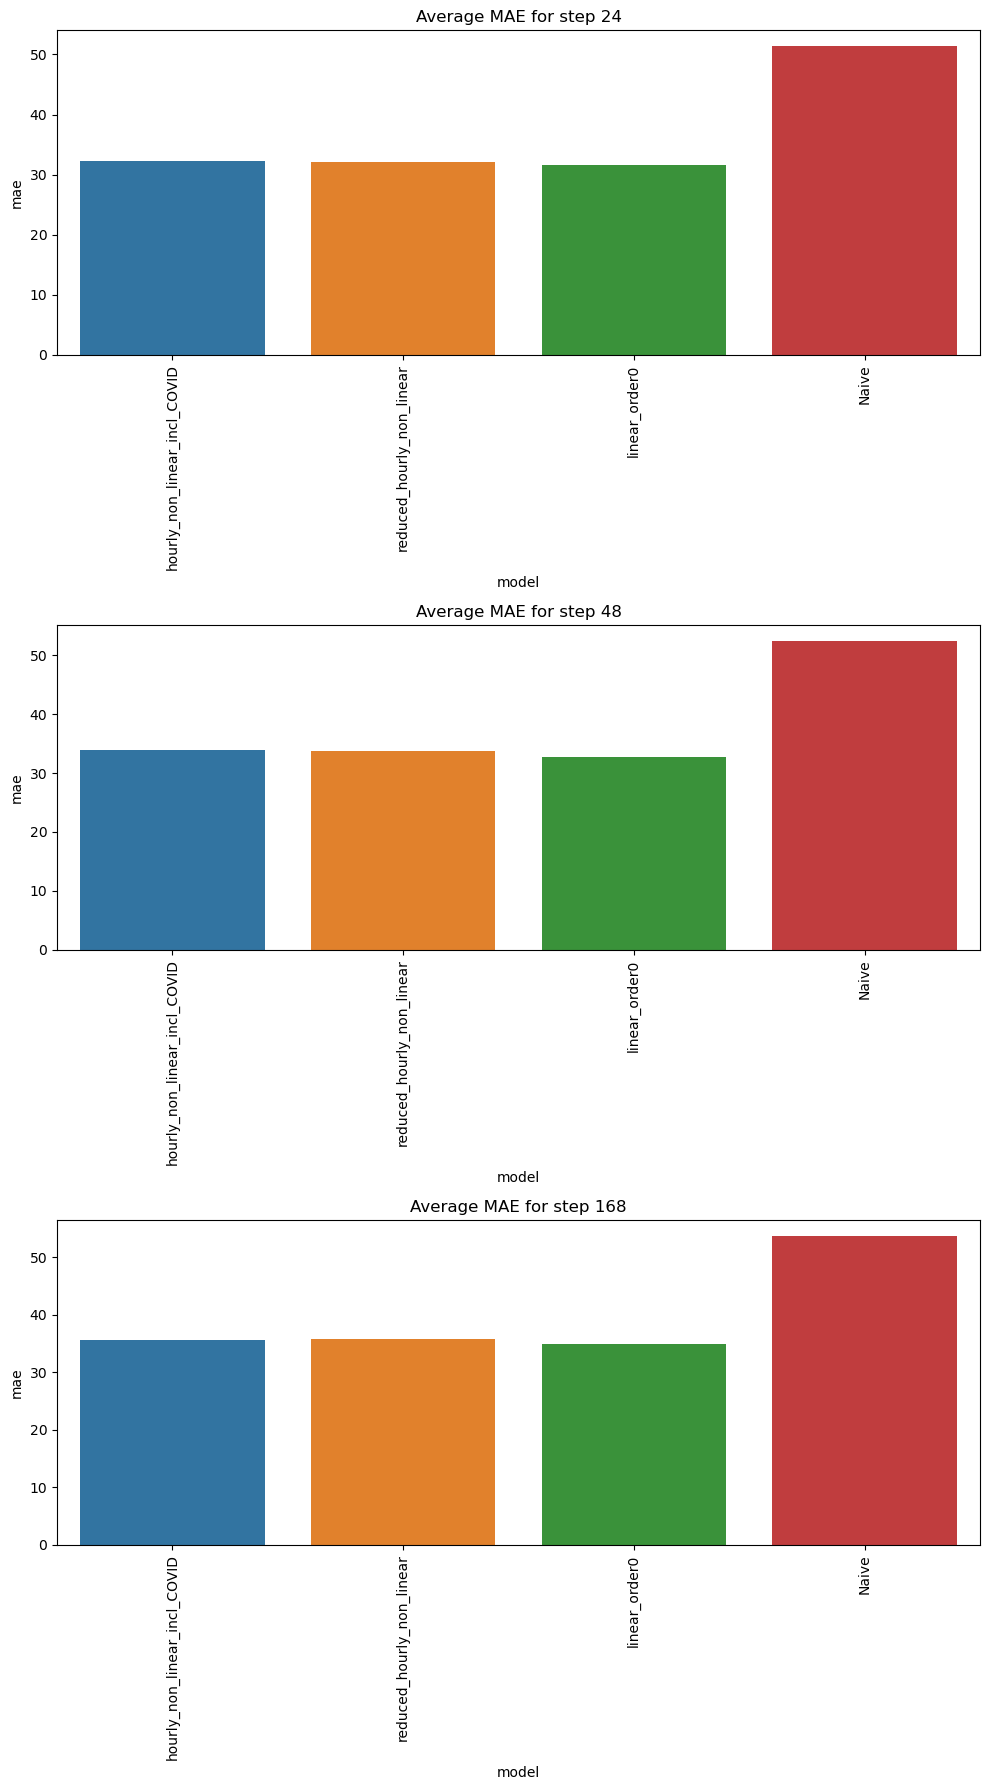

KeyError: 'reduced_daily_hybrid_order0'

In [68]:
# Run test_hyperparams (if you are using the GPU make sure to restart the kernel first and skip the hyperparam tuning cell, otherwise XGBoost may run out of memory depending on your GPU)
test_hyperparams(dict_full, ts_daily_train, ts_daily_test, ts_hourly_train, ts_hourly_test, daily_steps, hourly_steps, daily_offsets, hourly_offsets, daily_offsets_to_show, hourly_offsets_to_show)